Project Name: DeepFER: Facial Emotion Recognition Using Deep Learning
Project Type: Classification — Computer Vision / Deep Learning
Contribution: Individual
Team Member : Dolly Jain

### Import Libraries
We import libraries to access files, inspect the dataset ZIP archive, and summarize image counts before extracting or modifying the data.

In [ ]:
from pathlib import Path
from zipfile import ZipFile
from collections import Counter

import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


### Connect Google Drive and Locate the Dataset
We connect Google Drive to Colab and verify the project folder and dataset location. This ensures that the notebook reads the correct source file.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

# Use the exact project folder name.
PROJECT_DIR = (
    Path("/content/drive/MyDrive")
    / "DeepFER: Facial Emotion Recognition Using Deep Learning"
)

DATA_DIR = PROJECT_DIR / "data"
ZIP_PATH = DATA_DIR / "Face Emotion Recognition Dataset.zip"

# Stop with a clear message if a folder or file is missing.
assert PROJECT_DIR.is_dir(), (
    f"Project folder not found. Check its name and location:\n{PROJECT_DIR}"
)

assert ZIP_PATH.is_file(), (
    f"Dataset ZIP not found. Upload it inside the data folder:\n{ZIP_PATH}"
)

print("Project folder:", PROJECT_DIR.name)
print("Dataset file:", ZIP_PATH.name)
print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024 ** 2):.2f} MB")

Mounted at /content/drive
Project folder: DeepFER: Facial Emotion Recognition Using Deep Learning
Dataset file: Face Emotion Recognition Dataset.zip
ZIP size: 120.50 MB


### Inspect the Dataset Structure
We inspect image paths and count images in each folder without extracting the ZIP. This helps identify the available splits, emotion classes, and potentially repeated directory structures. Matching folder counts alone do not confirm duplicate images.

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

# Read the archive listing without extracting images.
with ZipFile(ZIP_PATH, "r") as archive:
    image_paths = [
        item.filename
        for item in archive.infolist()
        if not item.is_dir()
        and Path(item.filename).suffix.lower() in IMAGE_EXTENSIONS
    ]

assert image_paths, "No supported image files were found in the ZIP."

print("Total image entries in ZIP:", len(image_paths))

print("\nFirst 5 image paths:")
for image_path in image_paths[:5]:
    print(image_path)

# Keep complete parent paths so repeated folder structures remain visible.
folder_counts = Counter(
    image_path.rsplit("/", 1)[0]
    for image_path in image_paths
)

folder_summary = pd.DataFrame(
    sorted(folder_counts.items()),
    columns=["Folder inside ZIP", "Image count"]
)

display(folder_summary)

print(
    "\nThese are archive entry counts, not verified unique-image counts."
)

Total image entries in ZIP: 71774

First 5 image paths:
images/images/train/angry/0.jpg
images/images/train/angry/1.jpg
images/images/train/angry/10.jpg
images/images/train/angry/10002.jpg
images/images/train/angry/10016.jpg


,Folder inside ZIP,Image count
0,images/images/train/angry,3993
1,images/images/train/disgust,436
2,images/images/train/fear,4103
3,images/images/train/happy,7164
4,images/images/train/neutral,4982
5,images/images/train/sad,4938
6,images/images/train/surprise,3205
7,images/images/validation/angry,960
8,images/images/validation/disgust,111
9,images/images/validation/fear,1018



These are archive entry counts, not verified unique-image counts.


### Verify Repeated Dataset Copies
The ZIP contains two directory structures with matching image counts. We compare their relative file paths and SHA-256 hashes to verify whether they contain identical files. We first copy the ZIP to Colab's local storage for faster reading.

In [ ]:
import hashlib
import shutil

# Copy the ZIP from Drive to Colab's temporary local storage.
LOCAL_ZIP = Path("/content/DeepFER_source.zip")
shutil.copy2(ZIP_PATH, LOCAL_ZIP)

PREFIX_A = "images/images/"
PREFIX_B = "images/"

# Match images by split/class/filename within each structure.
files_a = {
    name[len(PREFIX_A):]: name
    for name in image_paths
    if name.startswith(PREFIX_A)
}

files_b = {
    name[len(PREFIX_B):]: name
    for name in image_paths
    if name.startswith(PREFIX_B)
    and not name.startswith(PREFIX_A)
}

same_paths = set(files_a) == set(files_b)
print("Same relative file paths:", same_paths)

assert same_paths, (
    "The directory structures differ. Stop here and share this output."
)

mismatches = []

with ZipFile(LOCAL_ZIP, "r") as archive:
    for index, relative_path in enumerate(sorted(files_a), start=1):
        hash_a = hashlib.sha256(
            archive.read(files_a[relative_path])
        ).hexdigest()

        hash_b = hashlib.sha256(
            archive.read(files_b[relative_path])
        ).hexdigest()

        if hash_a != hash_b:
            mismatches.append(relative_path)

        if index % 10000 == 0:
            print(f"Compared {index:,} image pairs...")

COPIES_IDENTICAL = len(mismatches) == 0

print("\nImage pairs compared:", len(files_a))
print("Different file contents:", len(mismatches))
print("Identical directory copies:", COPIES_IDENTICAL)

assert COPIES_IDENTICAL, (
    "Some files differ. Stop here and share this output."
)

Same relative file paths: True
Compared 10,000 image pairs...
Compared 20,000 image pairs...
Compared 30,000 image pairs...

Image pairs compared: 35887
Different file contents: 0
Identical directory copies: True


### Extract One Verified Dataset Copy
After confirming that both directory structures are identical, we extract only one copy into Colab's local storage. This avoids counting the repeated directory twice. Duplicate images within the selected copy will be checked separately.

In [ ]:
assert COPIES_IDENTICAL, "Verify the directory copies before extraction."

DATASET_DIR = Path("/content/DeepFER_dataset")

EMOTION_CLASSES = [
    "angry", "disgust", "fear", "happy",
    "neutral", "sad", "surprise"
]

with ZipFile(LOCAL_ZIP, "r") as archive:
    for relative_path, archive_path in sorted(files_a.items()):
        parts = relative_path.split("/")

        # Accept only the expected split/class/filename structure.
        assert (
            len(parts) == 3
            and parts[0] in {"train", "validation"}
            and parts[1] in EMOTION_CLASSES
            and parts[2] not in {"", ".", ".."}
            and "\\" not in relative_path
        ), f"Unexpected image path: {relative_path}"

        destination = DATASET_DIR.joinpath(*parts)
        destination.parent.mkdir(parents=True, exist_ok=True)

        with archive.open(archive_path) as source:
            with destination.open("wb") as target:
                shutil.copyfileobj(source, target)

print("Extraction completed.")
print("Dataset location:", DATASET_DIR)
print("Selected image entries:", len(files_a))

Extraction completed.
Dataset location: /content/DeepFER_dataset
Selected image entries: 35887


### Dataset First View and Image Counts
We create a table with one record per selected image file. Each record contains its local path, original dataset split, and emotion label. This table helps organize subsequent image validation, duplicate detection, and analysis. The original split names are preserved at this stage.

In [ ]:
records = []

for relative_path in sorted(files_a):
    source_split, emotion, filename = relative_path.split("/")
    local_path = DATASET_DIR / relative_path

    assert local_path.is_file(), f"Missing extracted file: {local_path}"

    records.append({
        "relative_path": relative_path,
        "image_path": str(local_path),
        "source_split": source_split,
        "emotion": emotion,
        "filename": filename,
    })

image_df = pd.DataFrame(records)

print("Dataset table shape:", image_df.shape)
display(image_df.head())

class_counts = pd.crosstab(
    image_df["emotion"],
    image_df["source_split"]
).reindex(EMOTION_CLASSES, fill_value=0)

class_counts["total"] = class_counts.sum(axis=1)

print("\nImage counts by emotion and original split:")
display(class_counts)

print("\nOriginal split totals:")
print(image_df["source_split"].value_counts())

# Save portable records without temporary Colab paths.
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_df.drop(columns="image_path").to_csv(
    RESULTS_DIR / "dataset_inventory_before_cleaning.csv",
    index=False
)

print("\nDataset inventory saved to Google Drive.")
print("These counts are before image validation and internal deduplication.")

Dataset table shape: (35887, 5)


,relative_path,image_path,source_split,emotion,filename
0,train/angry/0.jpg,/content/DeepFER_dataset/train/angry/0.jpg,train,angry,0.jpg
1,train/angry/1.jpg,/content/DeepFER_dataset/train/angry/1.jpg,train,angry,1.jpg
2,train/angry/10.jpg,/content/DeepFER_dataset/train/angry/10.jpg,train,angry,10.jpg
3,train/angry/10002.jpg,/content/DeepFER_dataset/train/angry/10002.jpg,train,angry,10002.jpg
4,train/angry/10016.jpg,/content/DeepFER_dataset/train/angry/10016.jpg,train,angry,10016.jpg



Image counts by emotion and original split:


source_split,train,validation,total
emotion,,,
angry,3993,960,4953
disgust,436,111,547
fear,4103,1018,5121
happy,7164,1825,8989
neutral,4982,1216,6198
sad,4938,1139,6077
surprise,3205,797,4002



Original split totals:
source_split
train         28821
validation     7066
Name: count, dtype: int64

Dataset inventory saved to Google Drive.
These counts are before image validation and internal deduplication.


### Validate Images and Inspect Their Properties
We fully decode each image to identify unreadable files and record its dimensions, color mode, brightness, and contrast. We also calculate a hash of decoded RGB pixels to identify exact visual duplicates, even when file metadata differs.

In [ ]:
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

audit_records = []

for row in tqdm(
    image_df.itertuples(index=False),
    total=len(image_df),
    desc="Checking images"
):
    record = {
        "relative_path": row.relative_path,
        "is_valid": False,
        "error": "",
        "width": None,
        "height": None,
        "color_mode": None,
        "brightness": None,
        "contrast": None,
        "pixel_hash": None,
    }

    try:
        with Image.open(row.image_path) as img:
            img.load()  # Decode the complete image to detect read errors.

            record["width"], record["height"] = img.size
            record["color_mode"] = img.mode

            rgb = img.convert("RGB")
            gray = np.asarray(img.convert("L"), dtype=np.float32)

            # Include dimensions so differently shaped images stay distinct.
            hash_input = (
                f"{rgb.width}x{rgb.height}|RGB|".encode()
                + rgb.tobytes()
            )

            record["pixel_hash"] = hashlib.sha256(hash_input).hexdigest()
            record["brightness"] = float(gray.mean())
            record["contrast"] = float(gray.std())
            record["is_valid"] = True

    except Exception as error:
        record["error"] = f"{type(error).__name__}: {error}"

    audit_records.append(record)

# Merge into the original inventory; this cell can be rerun safely.
audit_df = image_df.merge(
    pd.DataFrame(audit_records),
    on="relative_path",
    how="left",
    validate="one_to_one"
)

valid_df = audit_df.loc[audit_df["is_valid"]].copy()
invalid_df = audit_df.loc[~audit_df["is_valid"]].copy()

print("Images checked:", len(audit_df))
print("Readable images:", len(valid_df))
print("Unreadable images:", len(invalid_df))

print("\nImage dimensions and color modes:")
display(
    valid_df.groupby(["width", "height", "color_mode"])
    .size()
    .reset_index(name="image_count")
)

if not invalid_df.empty:
    display(invalid_df[["relative_path", "error"]].head(10))

audit_df.drop(columns="image_path").to_csv(
    RESULTS_DIR / "image_quality_audit.csv",
    index=False
)

Checking images:   0%|          | 0/35887 [00:00<?, ?it/s]

Images checked: 35887
Readable images: 35887
Unreadable images: 0

Image dimensions and color modes:


,width,height,color_mode,image_count
0,48,48,L,35887


### Check Duplicate Images and Conflicting Labels
We group readable images by their decoded-pixel hash. This identifies exact duplicate groups, identical images with different emotion labels, and duplicates shared between the original splits. Cross-split duplicates can inflate evaluation scores. This check does not detect near-duplicates or different images of the same person.

In [ ]:
duplicate_summary = (
    valid_df.groupby("pixel_hash")
    .agg(
        image_count=("relative_path", "size"),
        label_count=("emotion", "nunique"),
        split_count=("source_split", "nunique"),
        labels=("emotion", lambda values: ", ".join(sorted(set(values)))),
        source_splits=(
            "source_split",
            lambda values: ", ".join(sorted(set(values)))
        ),
    )
    .reset_index()
)

duplicate_groups = duplicate_summary.loc[
    duplicate_summary["image_count"] > 1
].copy()

conflicting_groups = duplicate_groups.loc[
    duplicate_groups["label_count"] > 1
].copy()

cross_split_groups = duplicate_groups.loc[
    duplicate_groups["split_count"] > 1
].copy()

duplicate_rows = valid_df.loc[
    valid_df["pixel_hash"].isin(duplicate_groups["pixel_hash"])
].sort_values(["pixel_hash", "relative_path"])

print("Exact duplicate groups:", len(duplicate_groups))
print("Images belonging to duplicate groups:", len(duplicate_rows))
print(
    "Extra copies beyond one image per group:",
    int((duplicate_groups["image_count"] - 1).sum())
)
print("Groups with conflicting emotion labels:", len(conflicting_groups))
print("Groups present in both original splits:", len(cross_split_groups))

display(duplicate_groups.head(10))

duplicate_groups.to_csv(
    RESULTS_DIR / "duplicate_group_summary.csv",
    index=False
)

duplicate_rows.drop(columns="image_path").to_csv(
    RESULTS_DIR / "duplicate_image_records.csv",
    index=False
)

print("\nAudit reports saved. No images have been removed.")

Exact duplicate groups: 1516
Images belonging to duplicate groups: 3369
Extra copies beyond one image per group: 1853
Groups with conflicting emotion labels: 57
Groups present in both original splits: 510


,pixel_hash,image_count,label_count,split_count,labels,source_splits
3,000aa09d46815289dd83a642cac46369e03ba8eb03000c...,2,1,1,surprise,train
38,00505097218b6abb811b50f12624364f96bdfe85903d8a...,2,1,1,surprise,train
42,005548f0bee33c673c6f88f620b7b6e87c5ab3ed644ebc...,2,1,2,surprise,"train, validation"
56,0071260101143431c955c60da4debbca0945af5db643bf...,2,1,2,neutral,"train, validation"
82,00a5cf541b789eb081e2d057ec5df95e20cc97fba330b9...,2,1,1,happy,train
92,00b1093aac19d4c882e7543aa4b6b1c1ae1db3ed71b025...,2,1,2,surprise,"train, validation"
95,00b601c0011a9165b5c7f347259911dca5075b6e3ed187...,2,1,1,fear,train
112,00dba931cc9ddd8046dc38de0717b1d9721c5d75024a5d...,2,1,1,surprise,train
162,014c7c3c3265edad00a9a1a010a41baf557c871946b25c...,2,1,1,happy,train
198,018d414e0883bad5b5d52871bac2f549cc37e6c76f8e81...,2,1,1,surprise,train



Audit reports saved. No images have been removed.


### View Sample Images from Each Emotion Class
We display three readable images per emotion from the original training split. This provides an initial visual check of face appearance and label plausibility without using held-out images to guide model development. A small sample cannot establish the quality of the entire dataset.

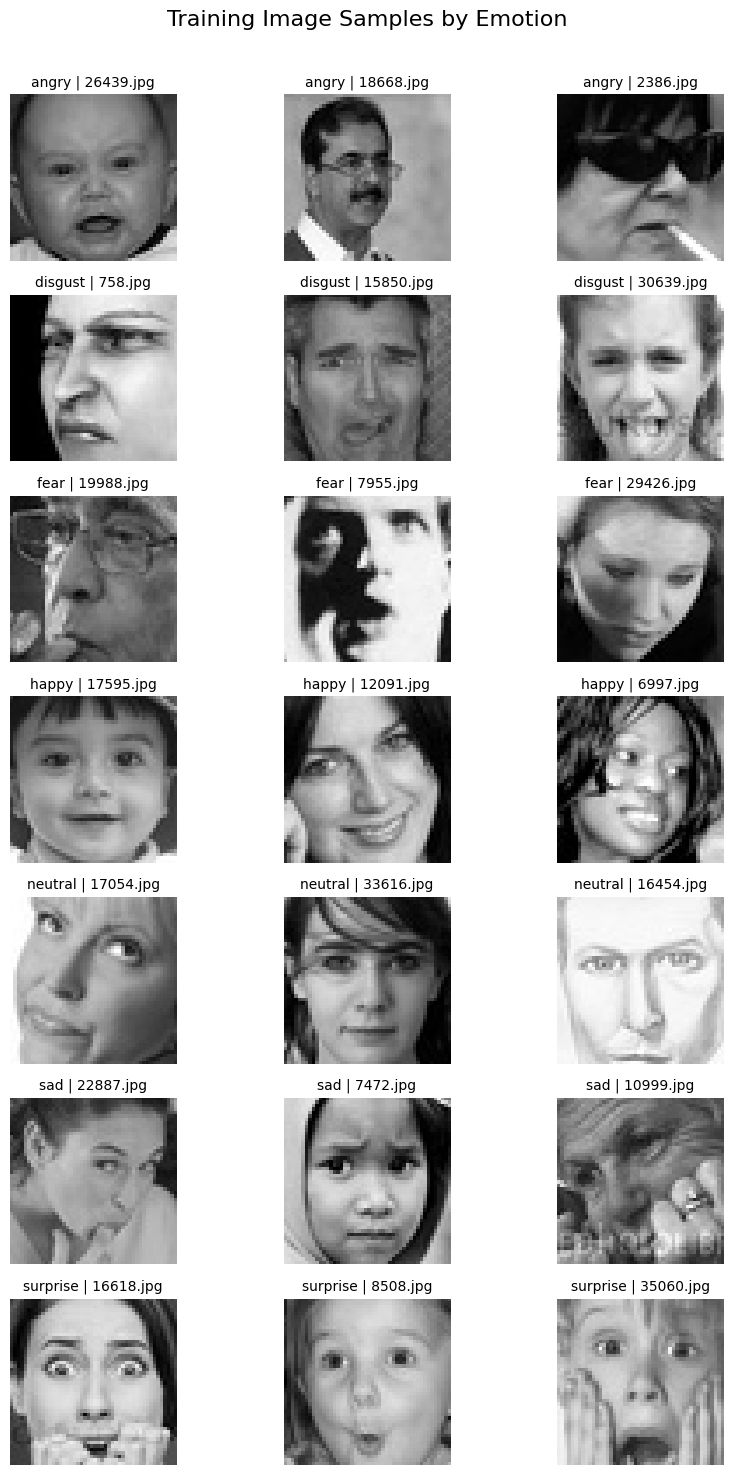

In [ ]:
import matplotlib.pyplot as plt

training_preview = valid_df.loc[
    valid_df["source_split"] == "train"
]

fig, axes = plt.subplots(
    len(EMOTION_CLASSES),
    3,
    figsize=(9, 15)
)

for row_index, emotion in enumerate(EMOTION_CLASSES):
    candidates = training_preview.loc[
        training_preview["emotion"] == emotion
    ]

    samples = candidates.sample(
        n=min(3, len(candidates)),
        random_state=42
    ).reset_index(drop=True)

    for column_index in range(3):
        ax = axes[row_index, column_index]
        ax.axis("off")

        if column_index < len(samples):
            sample = samples.iloc[column_index]

            with Image.open(sample["image_path"]) as img:
                ax.imshow(img.convert("L"), cmap="gray", vmin=0, vmax=255)

            ax.set_title(f"{emotion} | {sample['filename']}", fontsize=10)
        else:
            ax.set_title(f"{emotion} | No image available")

fig.suptitle("Training Image Samples by Emotion", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(
    RESULTS_DIR / "training_image_samples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Remove Unreadable Images and Quarantine Label Conflicts
Unreadable images cannot be used for training. We also exclude all copies of an exact image when its emotion labels conflict, because the correct label cannot be determined automatically. These records are saved for review, while the original files remain unchanged.

In [ ]:
# Confirm that the previous audit steps have been run.
assert "audit_df" in globals(), "Run Step 7 first."
assert "conflicting_groups" in globals(), "Run Step 8 first."

conflict_hashes = set(conflicting_groups["pixel_hash"])

cleaning_audit = audit_df.copy()
cleaning_audit["exclusion_reason"] = ""

# Exclude unreadable images.
cleaning_audit.loc[
    ~cleaning_audit["is_valid"],
    "exclusion_reason"
] = "unreadable_image"

# Quarantine every readable copy with conflicting emotion labels.
conflict_mask = (
    cleaning_audit["is_valid"]
    & cleaning_audit["pixel_hash"].isin(conflict_hashes)
)

cleaning_audit.loc[
    conflict_mask,
    "exclusion_reason"
] = "conflicting_labels"

excluded_quality_df = cleaning_audit.loc[
    cleaning_audit["exclusion_reason"] != ""
].copy()

eligible_df = cleaning_audit.loc[
    cleaning_audit["exclusion_reason"] == ""
].copy()

assert not eligible_df.empty, "No eligible images remain. Review the audit."

print("Images before cleaning:", len(cleaning_audit))
print("Unreadable images excluded:",
      (cleaning_audit["exclusion_reason"] == "unreadable_image").sum())
print("Images quarantined for label conflicts:", conflict_mask.sum())
print("Images remaining:", len(eligible_df))

excluded_quality_df.drop(columns="image_path").to_csv(
    RESULTS_DIR / "excluded_quality_records.csv",
    index=False
)

Images before cleaning: 35887
Unreadable images excluded: 0
Images quarantined for label conflicts: 160
Images remaining: 35727


### Remove Exact Duplicates and Prevent Split Leakage
We retain one image per decoded-pixel hash. When an image appears in both original splits, we keep its validation copy and exclude its training copies. The cleaned original validation split is reserved for final testing; a new validation subset will later be created from the original training data.

In [ ]:
# Prefer the original validation copy to protect the held-out test set.
split_priority = {"validation": 0, "train": 1}

ordered_df = eligible_df.assign(
    split_priority=eligible_df["source_split"].map(split_priority)
)

assert ordered_df["split_priority"].notna().all(), (
    "Unexpected source split found."
)

ordered_df = ordered_df.sort_values(
    ["split_priority", "relative_path"]
)

duplicate_mask = ordered_df.duplicated(
    subset="pixel_hash",
    keep="first"
)

removed_duplicate_df = ordered_df.loc[duplicate_mask].copy()

clean_df = (
    ordered_df.loc[~duplicate_mask]
    .drop(columns=["split_priority", "exclusion_reason"])
    .reset_index(drop=True)
)

# Explicitly record how the original splits will be used.
clean_df["dataset_role"] = clean_df["source_split"].map({
    "train": "development",
    "validation": "test"
})

assert clean_df["pixel_hash"].is_unique, (
    "Exact duplicates remain after cleaning."
)

development_hashes = set(
    clean_df.loc[
        clean_df["dataset_role"] == "development", "pixel_hash"
    ]
)

test_hashes = set(
    clean_df.loc[
        clean_df["dataset_role"] == "test", "pixel_hash"
    ]
)

assert development_hashes.isdisjoint(test_hashes), (
    "Exact duplicate leakage detected."
)

print("Additional duplicate copies removed:", len(removed_duplicate_df))
print("Images remaining after cleaning:", len(clean_df))
print("\nDataset roles:")
print(clean_df["dataset_role"].value_counts())
print("\nExact duplicate overlap between development and test: 0")

removed_duplicate_df.drop(
    columns=["image_path", "split_priority"]
).to_csv(
    RESULTS_DIR / "removed_duplicate_records.csv",
    index=False
)

Additional duplicate copies removed: 1750
Images remaining after cleaning: 33977

Dataset roles:
dataset_role
development    27012
test            6965
Name: count, dtype: int64

Exact duplicate overlap between development and test: 0


### Save the Cleaned Dataset Inventory and Cleaning Report
We save a portable inventory of retained images and summarize every exclusion. Counts before and after cleaning document the effect of our decisions. The original ZIP and extracted files are preserved; subsequent analysis and model training will use the cleaned inventory.

In [ ]:
cleaning_report = pd.DataFrame({
    "Stage": [
        "Selected directory copy",
        "Excluded unreadable images",
        "Quarantined conflicting-label images",
        "Removed additional exact duplicates",
        "Final retained images",
    ],
    "Image count": [
        len(audit_df),
        int((cleaning_audit["exclusion_reason"]
             == "unreadable_image").sum()),
        int(conflict_mask.sum()),
        len(removed_duplicate_df),
        len(clean_df),
    ],
})

# Check that every original record is accounted for.
assert (
    len(audit_df)
    == len(excluded_quality_df)
    + len(removed_duplicate_df)
    + len(clean_df)
), "Cleaning counts do not reconcile."

before_counts = (
    audit_df.groupby("emotion").size()
    .reindex(EMOTION_CLASSES, fill_value=0)
)

after_counts = (
    clean_df.groupby("emotion").size()
    .reindex(EMOTION_CLASSES, fill_value=0)
)

class_cleaning_report = pd.DataFrame({
    "Before cleaning": before_counts,
    "After cleaning": after_counts,
})

class_cleaning_report["Excluded"] = (
    class_cleaning_report["Before cleaning"]
    - class_cleaning_report["After cleaning"]
)

display(cleaning_report)
display(class_cleaning_report)

# Relative paths remain usable after re-extraction in a new runtime.
clean_df.drop(columns="image_path").to_csv(
    RESULTS_DIR / "cleaned_dataset_inventory.csv",
    index=False
)

cleaning_report.to_csv(
    RESULTS_DIR / "cleaning_summary.csv",
    index=False
)

class_cleaning_report.to_csv(
    RESULTS_DIR / "class_cleaning_summary.csv",
    index_label="emotion"
)

print("Cleaned inventory and reports saved to:", RESULTS_DIR)

,Stage,Image count
0,Selected directory copy,35887
1,Excluded unreadable images,0
2,Quarantined conflicting-label images,160
3,Removed additional exact duplicates,1750
4,Final retained images,33977


,Before cleaning,After cleaning,Excluded
emotion,,,
angry,4953,4717,236
disgust,547,458,89
fear,5121,4802,319
happy,8989,8794,195
neutral,6198,6046,152
sad,6077,5912,165
surprise,4002,3248,754


Cleaned inventory and reports saved to: /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/results


### Data Cleaning Findings

The selected dataset directory contained 35,887 image files. All images
were readable. We quarantined 160 images whose exact decoded pixels
appeared with conflicting emotion labels. We then removed 1,750 additional
exact duplicate copies, leaving 33,977 images.

When an identical image appeared in both original splits, we retained
the original validation copy and excluded its training copies. The
cleaned original validation split is reserved for final testing.

Class imbalance remains after cleaning: happy has 8,794 images, whereas
disgust has only 458. Therefore, overall accuracy alone will not be
sufficient; evaluation will also include macro F1 and class-wise metrics.

These checks address exact pixel duplicates. They do not establish
that near-duplicate images or different photographs of the same person
are absent across splits.

In [ ]:
# Verify the documented findings against the cleaned inventory.
expected_counts = pd.Series({
    "angry": 4717,
    "disgust": 458,
    "fear": 4802,
    "happy": 8794,
    "neutral": 6046,
    "sad": 5912,
    "surprise": 3248,
})

actual_counts = (
    clean_df["emotion"]
    .value_counts()
    .reindex(expected_counts.index, fill_value=0)
)

assert len(clean_df) == 33977, "Total differs from the documented result."
assert actual_counts.eq(expected_counts).all(), (
    "Class counts differ from the documented results."
)
assert clean_df["pixel_hash"].is_unique, "Exact duplicates remain."

print("Verified: 33,977 retained images.")
print("Verified: all 7 class counts match the cleaning report.")
print("Verified: no repeated decoded-pixel hashes remain.")

Verified: 33,977 retained images.
Verified: all 7 class counts match the cleaning report.
Verified: no repeated decoded-pixel hashes remain.


### Variables Description

Each row in the image inventory represents one image file. The image
pixels are the model input, while the emotion label is the prediction
target. Paths and filenames are identifiers used to locate files; they
must not be used as predictive features. The source split records the
dataset's original train or validation folder.

In [ ]:
variable_description = pd.DataFrame([
    {
        "Variable": "relative_path",
        "Meaning": "Image location relative to the extracted dataset",
        "Role": "Portable file identifier",
    },
    {
        "Variable": "image_path",
        "Meaning": "Full image location in the current Colab runtime",
        "Role": "Used to load image pixels",
    },
    {
        "Variable": "source_split",
        "Meaning": "Original train or validation folder",
        "Role": "Dataset organization; not a model input",
    },
    {
        "Variable": "emotion",
        "Meaning": "One of the seven facial-expression labels",
        "Role": "Prediction target",
    },
    {
        "Variable": "filename",
        "Meaning": "Original image filename",
        "Role": "Identifier; not necessarily unique across folders",
    },
])

display(variable_description)

print("Original inventory rows:", len(image_df))
print("Original inventory columns:", image_df.shape[1])

,Variable,Meaning,Role
0,relative_path,Image location relative to the extracted dataset,Portable file identifier
1,image_path,Full image location in the current Colab runtime,Used to load image pixels
2,source_split,Original train or validation folder,Dataset organization; not a model input
3,emotion,One of the seven facial-expression labels,Prediction target
4,filename,Original image filename,Identifier; not necessarily unique across folders


Original inventory rows: 35887
Original inventory columns: 5


### Unique Values and Missing Inventory Fields

We inspect the number of distinct values and missing entries in the
original inventory. We explicitly verify the seven emotion labels and
two original split names. Missing-value checks on this table do not
replace image decoding checks, which are documented separately.

In [ ]:
inventory_summary = pd.DataFrame({
    "Data type": image_df.dtypes.astype(str),
    "Unique values": image_df.nunique(),
    "Missing values": image_df.isna().sum(),
})

display(inventory_summary)

print("Emotion labels:", sorted(image_df["emotion"].unique()))
print("Original splits:", sorted(image_df["source_split"].unique()))
print("Unique relative paths:", image_df["relative_path"].is_unique)
print("Total missing inventory values:",
      int(image_df.isna().sum().sum()))

assert set(image_df["emotion"]) == set(EMOTION_CLASSES), (
    "Unexpected or missing emotion labels."
)
assert set(image_df["source_split"]) == {"train", "validation"}, (
    "Unexpected source split."
)
assert image_df["relative_path"].is_unique, (
    "Repeated relative paths found."
)

,Data type,Unique values,Missing values
relative_path,object,35887,0
image_path,object,35887,0
source_split,object,2,0
emotion,object,7,0
filename,object,35887,0


Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Original splits: ['train', 'validation']
Unique relative paths: True
Total missing inventory values: 0


### Chart 1: Emotion Class Distribution

We count the cleaned development images in each emotion class to
identify class imbalance. Unequal class frequencies can cause a model
to favor common expressions, so we will consider class-aware training
and report macro F1 alongside accuracy.

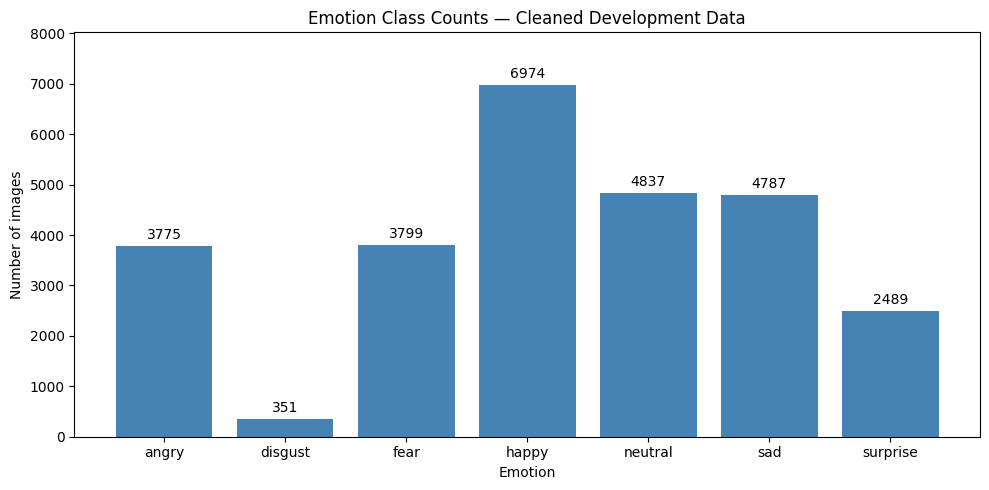

Development images: 27012
Largest class: happy (6,974)
Smallest class: disgust (351)
Largest-to-smallest class ratio: 19.87:1


In [ ]:
import matplotlib.pyplot as plt

# Use only development data for exploratory analysis.
eda_df = clean_df.loc[
    clean_df["dataset_role"] == "development"
].copy()

assert not eda_df.empty, "No development images found."

eda_counts = (
    eda_df["emotion"].value_counts()
    .reindex(EMOTION_CLASSES, fill_value=0)
)

assert (eda_counts > 0).all(), (
    "A class is missing from development data. Review before proceeding."
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    eda_counts.index,
    eda_counts.values,
    color="steelblue"
)

ax.bar_label(bars, padding=3, fmt="%d")
ax.set_title("Emotion Class Counts — Cleaned Development Data")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of images")
ax.set_ylim(0, eda_counts.max() * 1.15)

plt.tight_layout()
fig.savefig(
    RESULTS_DIR / "chart_01_emotion_counts.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

largest_class = eda_counts.idxmax()
smallest_class = eda_counts.idxmin()
imbalance_ratio = eda_counts.max() / eda_counts.min()

print("Development images:", len(eda_df))
print(f"Largest class: {largest_class} ({eda_counts.max():,})")
print(f"Smallest class: {smallest_class} ({eda_counts.min():,})")
print(f"Largest-to-smallest class ratio: {imbalance_ratio:.2f}:1")

**1. Why did you pick this chart?**

A bar chart makes the number of images in each emotion class easy to
compare and reveals underrepresented classes.

**2. What insights were found?**

The counts and largest-to-smallest ratio quantify class imbalance in
the development data. Classes with fewer examples provide less varied
training evidence; class frequency alone does not determine performance.

**3. What is the practical impact?**

A model may favor frequent classes while performing poorly on rare
expressions. Class-wise evaluation and macro F1 will help reveal this
issue before the model is used in an application.

### Chart 2: Image Brightness Distribution

We examine the mean grayscale intensity of development images.
Brightness is measured on a scale from 0 to 255. This helps us understand
lighting variability, although a low or high mean does not automatically
make an image unsuitable for training.

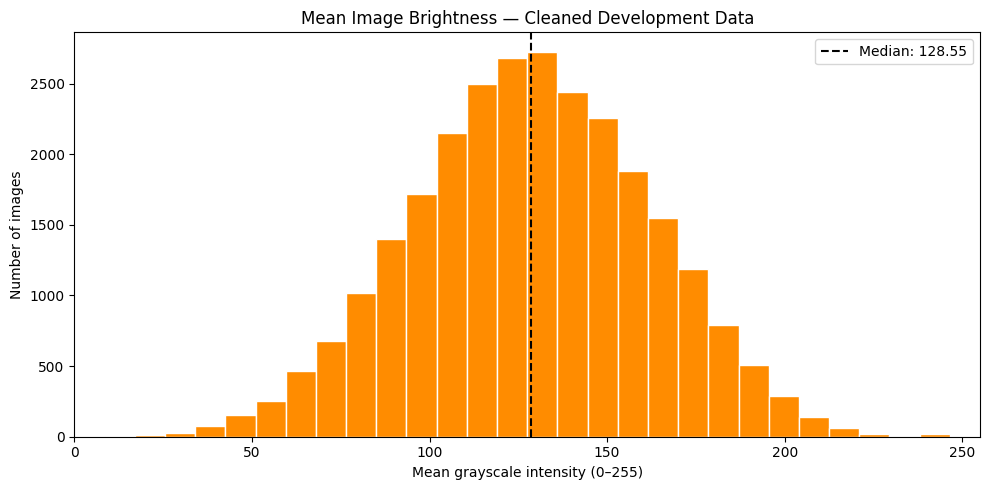

,Brightness
count,27012.00
mean,128.58
std,33.43
min,5.07
25%,105.90
50%,128.55
75%,151.86
max,247.95


In [ ]:
brightness_values = eda_df["brightness"].dropna()

assert not brightness_values.empty, "Brightness measurements are missing."

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    brightness_values,
    bins=30,
    range=(0, 255),
    color="darkorange",
    edgecolor="white"
)

median_brightness = brightness_values.median()

ax.axvline(
    median_brightness,
    color="black",
    linestyle="--",
    label=f"Median: {median_brightness:.2f}"
)

ax.set_title("Mean Image Brightness — Cleaned Development Data")
ax.set_xlabel("Mean grayscale intensity (0–255)")
ax.set_ylabel("Number of images")
ax.set_xlim(0, 255)
ax.legend()

plt.tight_layout()
fig.savefig(
    RESULTS_DIR / "chart_02_brightness_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

display(
    brightness_values.describe().round(2).to_frame(
        name="Brightness"
    )
)

**1. Why did you pick this chart?**

A histogram shows how brightness values are distributed and whether
images are concentrated within a narrow range of lighting conditions.

**2. What insights were found?**

The histogram and summary statistics describe the observed brightness
range and its concentration. Tail values identify images worth reviewing,
but brightness alone cannot establish image quality.

**3. What is the practical impact?**

Lighting variability can affect prediction reliability. This analysis
helps motivate controlled brightness-augmentation experiments and
evaluation under different lighting conditions.

### Chart 3: Image Contrast by Emotion

We compare grayscale contrast across emotion classes using box plots.
Contrast is measured as the standard deviation of pixel intensities
within each image. This is a descriptive quality measure, not a direct
measure of emotion or image sharpness.

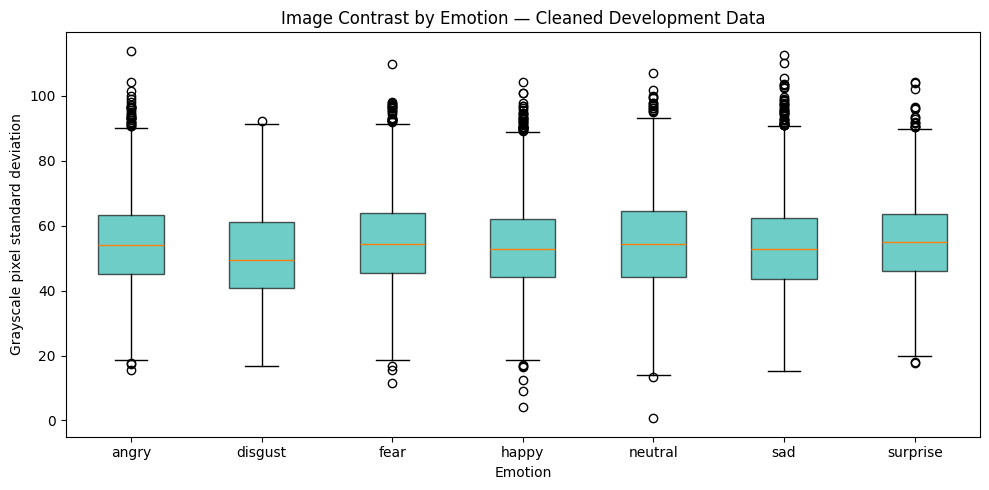

,count,mean,median,std,min,max
emotion,,,,,,
angry,3775,54.61,54.12,13.44,15.57,113.93
disgust,351,51.49,49.46,14.20,16.72,92.13
fear,3799,54.84,54.38,13.51,11.68,109.97
happy,6974,53.22,52.71,12.98,4.14,104.26
neutral,4837,54.42,54.28,14.61,0.65,106.93
sad,4787,53.48,52.76,14.02,15.23,112.52
surprise,2489,55.14,55.05,13.12,17.65,104.36


In [ ]:
contrast_by_class = [
    eda_df.loc[
        eda_df["emotion"] == emotion, "contrast"
    ].dropna().to_numpy()
    for emotion in EMOTION_CLASSES
]

assert all(len(values) > 0 for values in contrast_by_class), (
    "Contrast measurements are missing for a class."
)

fig, ax = plt.subplots(figsize=(10, 5))

boxplot = ax.boxplot(
    contrast_by_class,
    patch_artist=True,
    showfliers=True
)

ax.set_xticks(range(1, len(EMOTION_CLASSES) + 1))
ax.set_xticklabels(EMOTION_CLASSES)

for box in boxplot["boxes"]:
    box.set_facecolor("lightseagreen")
    box.set_alpha(0.65)

ax.set_title("Image Contrast by Emotion — Cleaned Development Data")
ax.set_xlabel("Emotion")
ax.set_ylabel("Grayscale pixel standard deviation")

plt.tight_layout()
fig.savefig(
    RESULTS_DIR / "chart_03_contrast_by_emotion.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

contrast_summary = (
    eda_df.groupby("emotion")["contrast"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(EMOTION_CLASSES)
    .round(2)
)

display(contrast_summary)

**1. Why did you pick this chart?**

Box plots compare the typical contrast, spread, and extreme values
across emotion classes without displaying every image separately.

**2. What insights were found?**

The medians and spreads show how contrast varies within and between
classes. Any visible difference is descriptive and does not establish
a statistically significant difference or a causal relationship.

**3. What is the practical impact?**

Systematic image-quality differences between classes could become
shortcuts for a model. This motivates further checks and robustness
experiments rather than automatically removing extreme observations.

**2. What insights were found?**

The cleaned development set contains 27,012 images. Happy is the
largest class with 6,974 images, while disgust is the smallest with
only 351 images. The largest-to-smallest ratio is 19.87:1, confirming
substantial class imbalance. Without suitable handling, the model may
learn happy expressions more effectively than disgust expressions.

**3. What is the practical impact?**

The imbalance can produce a high overall accuracy even if the model
performs poorly on disgust and other smaller classes. We will therefore
use class weights during training and evaluate macro F1, class-wise
precision, recall, and the confusion matrix.

**2. What insights were found?**

The mean brightness is 128.58 and the median is 128.55, showing that
the centre of the distribution lies near the middle of the 0–255
intensity scale. Brightness ranges from 5.07 to 247.95, so the dataset
also contains extremely dark and extremely bright images.

**3. What is the practical impact?**

The wide brightness range indicates substantial lighting variation.
Controlled brightness augmentation may improve robustness, but extreme
images should be visually reviewed before deciding whether any removal
is justified.

**2. What insights were found?**

Median contrast is fairly similar across most classes. Surprise has
the highest median contrast at 55.05, while disgust has the lowest at
49.46. Disgust also has far fewer observations, so its estimate is
less stable. These descriptive differences do not establish that
contrast causes an emotion label.

**3. What is the practical impact?**

If image contrast differs systematically by class, the model could
partly learn image-quality shortcuts instead of facial-expression
patterns. Augmentation and class-wise evaluation will help assess and
reduce this risk.

### Chart 4: Brightness Distribution by Emotion

We compare brightness distributions across emotion classes. This
bivariate analysis helps identify whether some labels are systematically
associated with darker or brighter images. Such differences could act
as unintended shortcuts during model training.

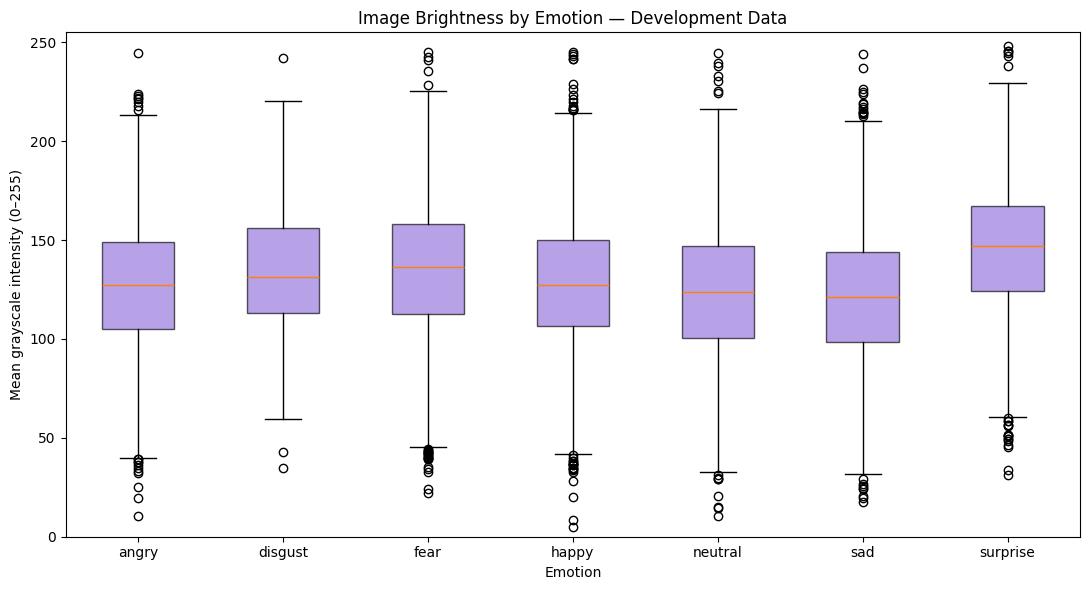

,count,mean,median,std,min,max
emotion,,,,,,
angry,3775,126.12,127.18,32.75,10.63,244.68
disgust,351,134.04,131.12,32.84,34.61,241.79
fear,3799,134.88,136.32,32.64,22.16,245.02
happy,6974,128.68,127.39,32.01,5.07,244.84
neutral,4837,123.93,123.62,33.25,10.60,244.44
sad,4787,121.14,121.17,33.69,17.59,244.29
surprise,2489,145.06,146.76,32.06,31.15,247.95


In [ ]:
brightness_by_class = [
    eda_df.loc[
        eda_df["emotion"] == emotion, "brightness"
    ].dropna().to_numpy()
    for emotion in EMOTION_CLASSES
]

assert all(len(values) > 0 for values in brightness_by_class), (
    "Brightness measurements are missing for a class."
)

fig, ax = plt.subplots(figsize=(11, 6))

boxplot = ax.boxplot(
    brightness_by_class,
    patch_artist=True,
    showfliers=True
)

ax.set_xticks(range(1, len(EMOTION_CLASSES) + 1))
ax.set_xticklabels(EMOTION_CLASSES)

for box in boxplot["boxes"]:
    box.set_facecolor("mediumpurple")
    box.set_alpha(0.65)

ax.set_title("Image Brightness by Emotion — Development Data")
ax.set_xlabel("Emotion")
ax.set_ylabel("Mean grayscale intensity (0–255)")
ax.set_ylim(0, 255)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_04_brightness_by_emotion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

brightness_class_summary = (
    eda_df.groupby("emotion")["brightness"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(EMOTION_CLASSES)
    .round(2)
)

display(brightness_class_summary)

**1. Why did you pick this chart?**

Box plots allow the typical brightness, variation, and extreme values
of all seven emotion classes to be compared on the same scale.

**2. What insights were found?**

The class medians indicate whether lighting conditions are broadly
similar across labels. Differences are descriptive and do not prove
that brightness is related to the facial expression itself.

**3. What is the practical impact?**

Large class-level brightness differences could allow the model to use
lighting as a shortcut. Controlled augmentation and evaluation across
brightness ranges can help test model robustness.

### Chart 5: Brightness Bands within Each Emotion

We divide development images into dark, medium, and bright groups using
the first and third brightness quartiles. A percentage-stacked bar chart
compares the lighting composition of classes despite their unequal sizes.
These are dataset-relative bands rather than universal image-quality
standards.

Dark-band upper boundary: 105.90
Bright-band lower boundary: 151.86


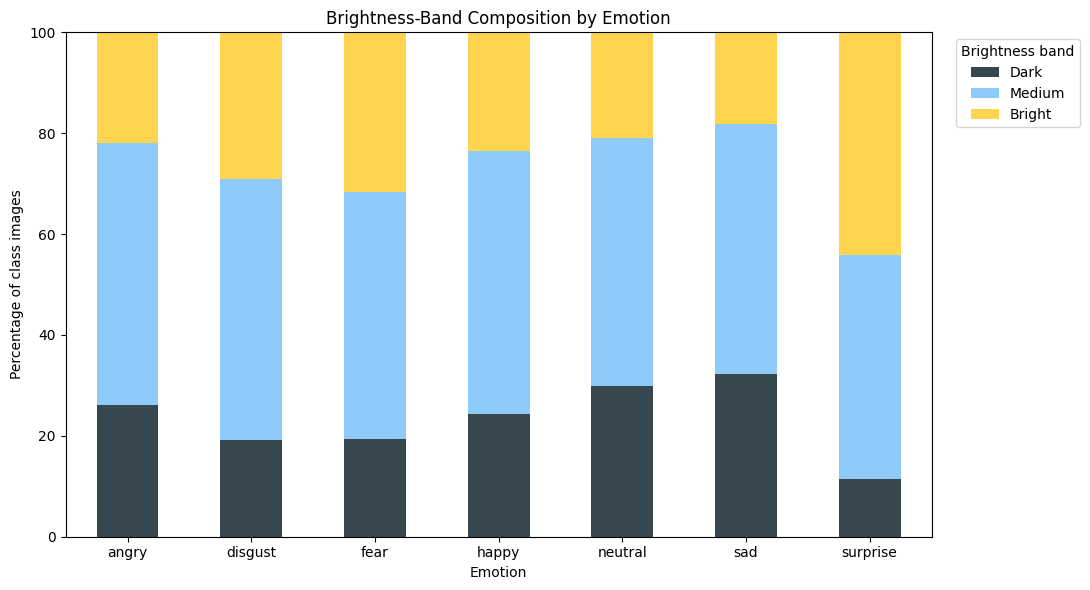

brightness_band,Dark,Medium,Bright
emotion,,,
angry,26.09,51.97,21.93
disgust,19.09,51.85,29.06
fear,19.35,48.96,31.69
happy,24.30,52.25,23.44
neutral,29.83,49.12,21.05
sad,32.23,49.63,18.13
surprise,11.45,44.44,44.11


In [ ]:
brightness_q1 = eda_df["brightness"].quantile(0.25)
brightness_q3 = eda_df["brightness"].quantile(0.75)

print(f"Dark-band upper boundary: {brightness_q1:.2f}")
print(f"Bright-band lower boundary: {brightness_q3:.2f}")

eda_df["brightness_band"] = pd.cut(
    eda_df["brightness"],
    bins=[-np.inf, brightness_q1, brightness_q3, np.inf],
    labels=["Dark", "Medium", "Bright"],
    include_lowest=True
)

brightness_band_counts = pd.crosstab(
    eda_df["emotion"],
    eda_df["brightness_band"]
).reindex(
    index=EMOTION_CLASSES,
    columns=["Dark", "Medium", "Bright"],
    fill_value=0
)

brightness_band_percent = (
    brightness_band_counts
    .div(brightness_band_counts.sum(axis=1), axis=0)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(11, 6))

brightness_band_percent.plot(
    kind="bar",
    stacked=True,
    color=["#37474F", "#90CAF9", "#FFD54F"],
    ax=ax
)

ax.set_title("Brightness-Band Composition by Emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("Percentage of class images")
ax.set_ylim(0, 100)
ax.legend(title="Brightness band", bbox_to_anchor=(1.02, 1))

plt.xticks(rotation=0)
plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_05_brightness_bands_by_emotion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

display(brightness_band_percent.round(2))

assert np.allclose(
    brightness_band_percent.sum(axis=1).values,
    100
), "Brightness-band percentages do not total 100%."

**1. Why did you pick this chart?**

A percentage-stacked bar chart compares lighting composition across
classes without allowing the large differences in class counts to
dominate the visualization.

**2. What insights were found?**

The chart shows whether an emotion contains a larger share of dark or
bright images than other emotions. The boundaries are based on the
development dataset's quartiles and do not define objectively poor images.

**3. What is the practical impact?**

Unequal lighting composition can introduce class-specific visual cues.
Brightness augmentation may reduce dependence on these cues and improve
performance under varying lighting conditions.

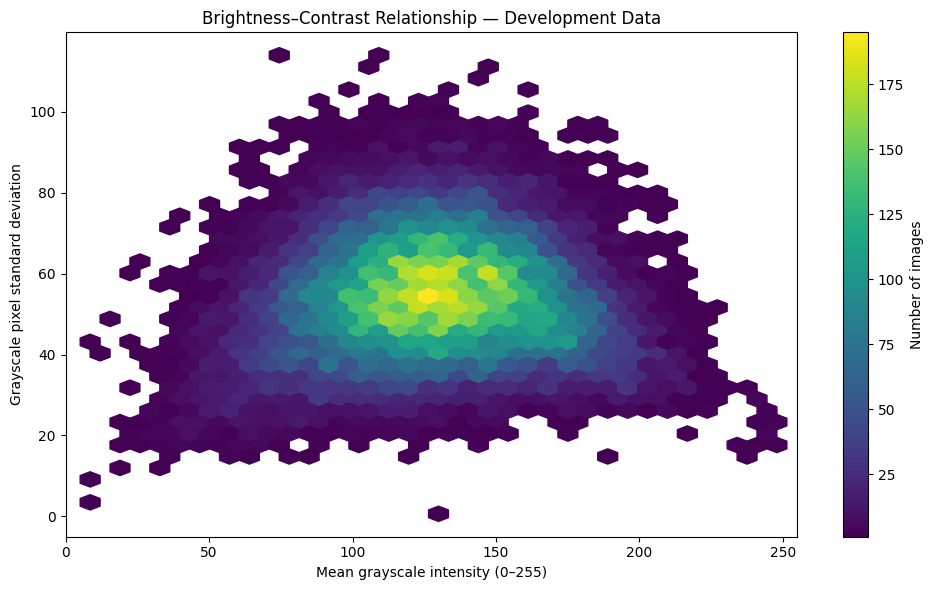

Pearson correlation: 0.033
Spearman correlation: 0.020


In [ ]:
brightness_contrast_df = eda_df[
    ["brightness", "contrast"]
].dropna()

assert not brightness_contrast_df.empty, (
    "Brightness or contrast measurements are missing."
)

fig, ax = plt.subplots(figsize=(10, 6))

hex_plot = ax.hexbin(
    brightness_contrast_df["brightness"],
    brightness_contrast_df["contrast"],
    gridsize=35,
    mincnt=1,
    cmap="viridis"
)

colorbar = fig.colorbar(hex_plot, ax=ax)
colorbar.set_label("Number of images")

ax.set_title("Brightness–Contrast Relationship — Development Data")
ax.set_xlabel("Mean grayscale intensity (0–255)")
ax.set_ylabel("Grayscale pixel standard deviation")
ax.set_xlim(0, 255)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_06_brightness_contrast_relationship.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

pearson_correlation = brightness_contrast_df[
    "brightness"
].corr(
    brightness_contrast_df["contrast"],
    method="pearson"
)

spearman_correlation = brightness_contrast_df[
    "brightness"
].corr(
    brightness_contrast_df["contrast"],
    method="spearman"
)

print(
    f"Pearson correlation: {pearson_correlation:.3f}"
)
print(
    f"Spearman correlation: {spearman_correlation:.3f}"
)

**1. Why did you pick this chart?**

A hexagonal density plot displays the joint distribution of two
continuous image properties while avoiding severe point overlap.

**2. What insights were found?**

The dense regions show the most common combinations of brightness and
contrast. Pearson correlation measures linear association, while
Spearman correlation measures monotonic association. Neither measure
establishes causation.

**3. What is the practical impact?**

A strong relationship would suggest that lighting changes are linked
with changes in visible contrast. This information can guide realistic
augmentation settings and robustness testing.

**2. What insights were found?**

Surprise has the highest mean and median brightness, at 145.06 and
146.76 respectively. Sad has the lowest mean and median brightness,
at 121.14 and 121.17. Disgust is relatively bright, but its estimate
is based on only 351 images and is therefore less stable than estimates
for larger classes.

**3. What is the practical impact?**

The brightness differences indicate that lighting is not distributed
equally across emotion classes. The model could partly associate bright
images with surprise and darker images with sad. Brightness augmentation
and brightness-specific evaluation will help reduce and detect this risk.

**2. What insights were found?**

Surprise has the largest proportion of bright images at 44.11% and the
smallest dark-image proportion at 11.45%. Sad has the largest dark-image
share at 32.23% and only 18.13% bright images. Neutral also contains a
relatively high dark-image share of 29.83%.

**3. What is the practical impact?**

These class-specific lighting patterns may become unintended prediction
cues. Controlled brightness augmentation is justified, but the original
images should remain unchanged so that evaluation reflects real dataset
conditions.

**2. What insights were found?**

The Pearson correlation is 0.033 and the Spearman correlation is 0.020.
Both values are close to zero, indicating almost no overall linear or
monotonic relationship between average brightness and contrast in the
development data.

**3. What is the practical impact?**

Brightness and contrast represent largely separate image properties in
this dataset. Augmentation settings should therefore control them
independently rather than assuming that changing brightness will produce
a predictable change in contrast.

### Chart 7: Cleaning Impact by Emotion

We compare retained and excluded image counts for every emotion class.
We also calculate the exclusion rate because raw counts alone can hide
a large proportional loss from smaller classes. Exclusions include
conflicting-label images and additional exact duplicate copies.

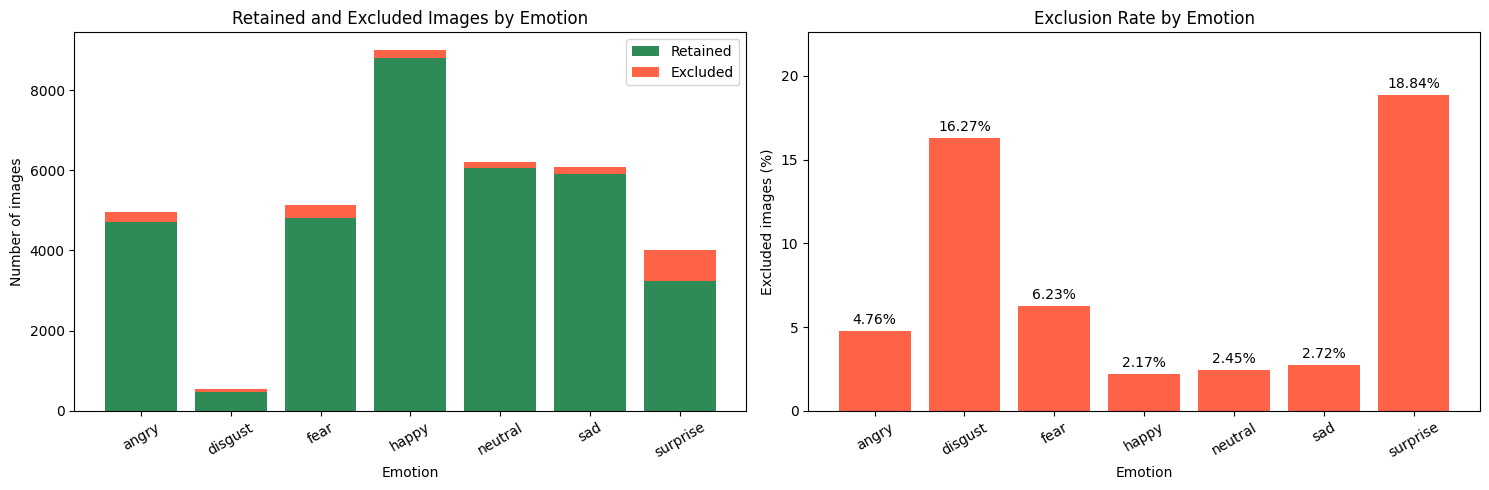

,Before cleaning,After cleaning,Excluded,Retention rate (%),Exclusion rate (%)
emotion,,,,,
angry,4953,4717,236,95.24,4.76
disgust,547,458,89,83.73,16.27
fear,5121,4802,319,93.77,6.23
happy,8989,8794,195,97.83,2.17
neutral,6198,6046,152,97.55,2.45
sad,6077,5912,165,97.28,2.72
surprise,4002,3248,754,81.16,18.84


In [ ]:
cleaning_by_class = (
    class_cleaning_report
    .reindex(EMOTION_CLASSES)
    .copy()
)

cleaning_by_class["Retention rate (%)"] = (
    cleaning_by_class["After cleaning"]
    / cleaning_by_class["Before cleaning"]
    * 100
)

cleaning_by_class["Exclusion rate (%)"] = (
    cleaning_by_class["Excluded"]
    / cleaning_by_class["Before cleaning"]
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: retained and excluded counts.
axes[0].bar(
    EMOTION_CLASSES,
    cleaning_by_class["After cleaning"],
    label="Retained",
    color="seagreen"
)

axes[0].bar(
    EMOTION_CLASSES,
    cleaning_by_class["Excluded"],
    bottom=cleaning_by_class["After cleaning"],
    label="Excluded",
    color="tomato"
)

axes[0].set_title("Retained and Excluded Images by Emotion")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()

# Right panel: exclusion percentage.
rate_bars = axes[1].bar(
    EMOTION_CLASSES,
    cleaning_by_class["Exclusion rate (%)"],
    color="tomato"
)

axes[1].bar_label(
    rate_bars,
    labels=[
        f"{value:.2f}%"
        for value in cleaning_by_class["Exclusion rate (%)"]
    ],
    padding=3
)

axes[1].set_title("Exclusion Rate by Emotion")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Excluded images (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylim(
    0,
    cleaning_by_class["Exclusion rate (%)"].max() * 1.2
)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_07_cleaning_impact_by_emotion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

display(cleaning_by_class.round(2))

**1. Why did you pick this chart?**

The two-panel chart shows both the absolute cleaning impact and the
percentage impact. This prevents large classes from dominating the
interpretation.

**2. What insights were found?**

Surprise experienced the highest proportional exclusion at approximately
18.84%, followed by disgust at approximately 16.27%. Happy had the
lowest exclusion rate at approximately 2.17%. The large reduction for
surprise indicates that many of its original records were involved in
duplicate or conflicting-label groups.

**3. What is the practical impact?**

Cleaning reduces leakage and label ambiguity, but it also reduces the
available examples for some classes. The model evaluation must therefore
remain class-aware, especially for disgust and surprise.

### Chart 8: Class Proportions in Development and Test Data

We compare class percentages in the cleaned development and held-out
test sets. Similar proportions support a fair comparison between model
development and final evaluation. The test set remains untouched during
model selection.

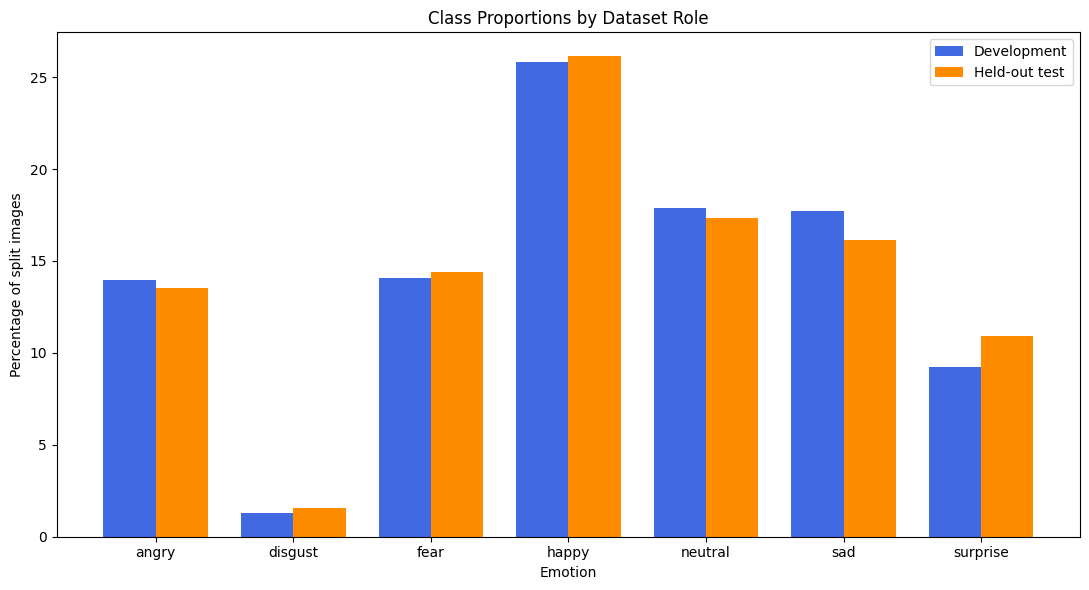

Image count        Percentage       
dataset_role development  test development   test
emotion                                          
angry               3775   942       13.98  13.52
disgust              351   107        1.30   1.54
fear                3799  1003       14.06  14.40
happy               6974  1820       25.82  26.13
neutral             4837  1209       17.91  17.36
sad                 4787  1125       17.72  16.15
surprise            2489   759        9.21  10.90

Development total: 27012
Held-out test total: 6965
Maximum class-proportion gap: 1.68 percentage points


In [ ]:
role_counts = pd.crosstab(
    clean_df["emotion"],
    clean_df["dataset_role"]
).reindex(
    index=EMOTION_CLASSES,
    columns=["development", "test"],
    fill_value=0
)

role_percentages = (
    role_counts
    .div(role_counts.sum(axis=0), axis=1)
    .mul(100)
)

x_positions = np.arange(len(EMOTION_CLASSES))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

development_bars = ax.bar(
    x_positions - bar_width / 2,
    role_percentages["development"],
    width=bar_width,
    label="Development",
    color="royalblue"
)

test_bars = ax.bar(
    x_positions + bar_width / 2,
    role_percentages["test"],
    width=bar_width,
    label="Held-out test",
    color="darkorange"
)

ax.set_title("Class Proportions by Dataset Role")
ax.set_xlabel("Emotion")
ax.set_ylabel("Percentage of split images")
ax.set_xticks(x_positions)
ax.set_xticklabels(EMOTION_CLASSES)
ax.legend()

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_08_class_proportions_by_role.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

role_summary = pd.concat(
    {
        "Image count": role_counts,
        "Percentage": role_percentages.round(2),
    },
    axis=1
)

display(role_summary)

print("Development total:", role_counts["development"].sum())
print("Held-out test total:", role_counts["test"].sum())

maximum_percentage_gap = (
    role_percentages["development"]
    - role_percentages["test"]
).abs().max()

print(
    "Maximum class-proportion gap:",
    f"{maximum_percentage_gap:.2f} percentage points"
)

**1. Why did you pick this chart?**

Grouped bars make it easy to compare the relative class composition of
the development and held-out test sets despite their different sizes.

**2. What insights were found?**

Both sets contain all seven emotions and preserve broadly similar class
patterns. Happy remains the largest class and disgust remains the
smallest. The reported maximum percentage-point gap quantifies the
largest distribution difference between the two sets.

**3. What is the practical impact?**

Similar class proportions make the held-out test set more representative
of the data used for development. The remaining imbalance still requires
macro F1 and class-wise evaluation.

### Chart 9: Visual Review of Brightness Extremes

We display the four darkest and four brightest development images.
This qualitative review helps determine whether extreme brightness
values correspond to usable faces or obvious data-quality problems.
The review is descriptive, and images are not removed solely because
their brightness is extreme.

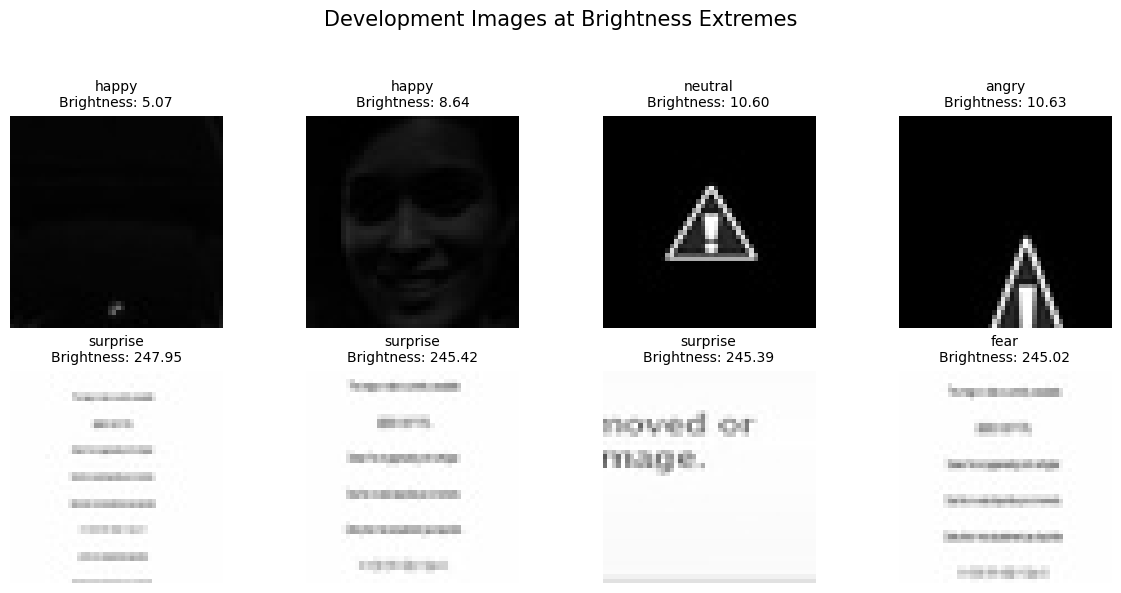

,brightness_group,relative_path,emotion,brightness,contrast
0,Darkest,train/happy/29447.jpg,happy,5.07,4.14
1,Darkest,train/happy/20417.jpg,happy,8.64,9.14
2,Darkest,train/neutral/25219.jpg,neutral,10.60,40.33
3,Darkest,train/angry/7496.jpg,angry,10.63,42.52
4,Brightest,train/surprise/2809.jpg,surprise,247.95,17.65
5,Brightest,train/surprise/19238.jpg,surprise,245.42,22.70
6,Brightest,train/surprise/2059.jpg,surprise,245.39,21.60
7,Brightest,train/fear/14279.jpg,fear,245.02,23.04


In [ ]:
darkest_images = (
    eda_df.nsmallest(4, "brightness")
    .assign(brightness_group="Darkest")
)

brightest_images = (
    eda_df.nlargest(4, "brightness")
    .assign(brightness_group="Brightest")
)

extreme_images = pd.concat(
    [darkest_images, brightest_images],
    ignore_index=True
)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for index, sample in extreme_images.iterrows():
    row_position = 0 if index < 4 else 1
    column_position = index % 4
    ax = axes[row_position, column_position]

    with Image.open(sample["image_path"]) as img:
        ax.imshow(
            img.convert("L"),
            cmap="gray",
            vmin=0,
            vmax=255
        )

    ax.set_title(
        f"{sample['emotion']}\n"
        f"Brightness: {sample['brightness']:.2f}",
        fontsize=10
    )
    ax.axis("off")

axes[0, 0].set_ylabel("Darkest", fontsize=12)
axes[1, 0].set_ylabel("Brightest", fontsize=12)

fig.suptitle(
    "Development Images at Brightness Extremes",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

fig.savefig(
    RESULTS_DIR / "chart_09_brightness_extreme_examples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

display(
    extreme_images[
        [
            "brightness_group",
            "relative_path",
            "emotion",
            "brightness",
            "contrast",
        ]
    ].round(2)
)

**1. Why did you pick this chart?**

Summary statistics cannot show whether extreme brightness values
represent valid facial images. A sample grid enables direct visual
inspection of these observations.

**2. What insights were found?**

The grid shows the appearance and labels of the darkest and brightest
development images. If faces remain recognizable, the values represent
challenging lighting conditions rather than automatically invalid data.

**3. What is the practical impact?**

Keeping valid lighting extremes can improve the relevance of the model
to real-world conditions. These examples also support testing model
performance under poor lighting after training.

**2. What insights were found?**

Surprise experienced the highest exclusion rate at 18.84%, followed by
disgust at 16.27%. Happy had the lowest exclusion rate at 2.17%.
Despite cleaning, all seven emotion classes remain represented in the
dataset.

**3. What is the practical impact?**

Cleaning reduced duplicate leakage and label ambiguity, but it removed
a relatively large proportion of surprise and disgust images. These
classes require careful class-wise evaluation during model testing.

**2. What insights were found?**

The development set contains 27,012 images and the held-out test set
contains 6,965 images. All seven classes occur in both sets. The largest
class-proportion difference is only 1.68 percentage points, occurring
for surprise, which represents 9.21% of development data and 10.90% of
test data.

**3. What is the practical impact?**

The broadly similar class distributions make the test set suitable for
final evaluation. However, both sets remain imbalanced, so macro F1 and
class-wise recall remain necessary alongside accuracy.

**2. What insights were found?**

The darkest development image has a brightness of 5.07, while the
brightest has a brightness of 247.95. Two of the four darkest examples
are labelled happy, while three of the four brightest examples are
labelled surprise. Some extreme examples contain very limited visible
contrast and should be treated as challenging observations.

**3. What is the practical impact?**

The extreme images may be difficult for both humans and the model to
interpret. We retain them because brightness alone is not sufficient
grounds for removal, but they should be included in later robustness
and error analysis.

### Chart 10: Average Face by Emotion

We calculate the mean grayscale image for each emotion using only the
cleaned development data. Averaging suppresses individual identity and
background variation while highlighting facial patterns that occur
frequently within each class. It does not represent every individual
expression in that class.

,width,height,image_count
0,48,48,27012


Calculating class image statistics:   0%|          | 0/27012 [00:00<?, ?it/s]

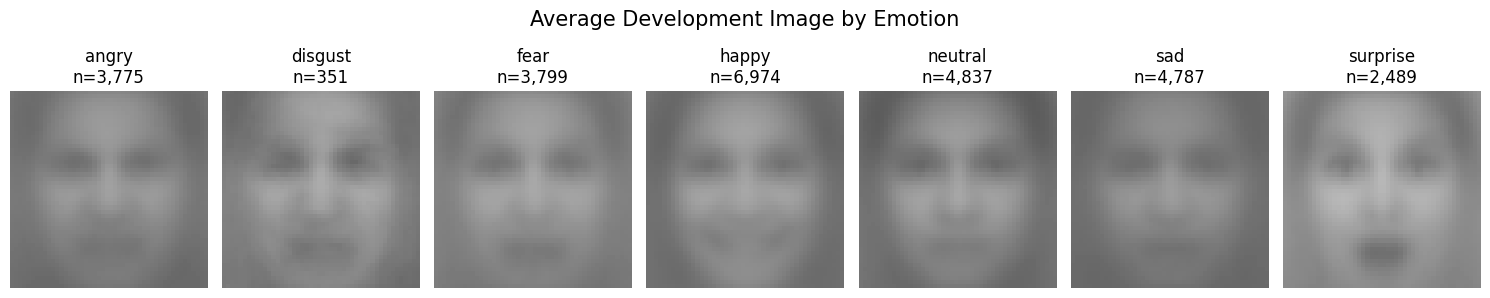

,Images used,Average pixel intensity
Emotion,,
angry,3775,126.12
disgust,351,134.04
fear,3799,134.88
happy,6974,128.68
neutral,4837,123.93
sad,4787,121.14
surprise,2489,145.06


In [ ]:
# Confirm that all development images have the same dimensions.
dimension_counts = (
    eda_df.groupby(["width", "height"])
    .size()
    .reset_index(name="image_count")
)

display(dimension_counts)

assert len(dimension_counts) == 1, (
    "Images have different dimensions. Resize them before averaging."
)

image_width = int(dimension_counts.iloc[0]["width"])
image_height = int(dimension_counts.iloc[0]["height"])

class_sums = {
    emotion: np.zeros((image_height, image_width), dtype=np.float64)
    for emotion in EMOTION_CLASSES
}

class_square_sums = {
    emotion: np.zeros((image_height, image_width), dtype=np.float64)
    for emotion in EMOTION_CLASSES
}

class_image_counts = {
    emotion: 0 for emotion in EMOTION_CLASSES
}

# One image-reading pass supplies both mean and variability calculations.
for row in tqdm(
    eda_df.itertuples(index=False),
    total=len(eda_df),
    desc="Calculating class image statistics"
):
    with Image.open(row.image_path) as img:
        pixels = np.asarray(
            img.convert("L"),
            dtype=np.float64
        )

    assert pixels.shape == (image_height, image_width)

    class_sums[row.emotion] += pixels
    class_square_sums[row.emotion] += pixels ** 2
    class_image_counts[row.emotion] += 1

average_images = {
    emotion: class_sums[emotion] / class_image_counts[emotion]
    for emotion in EMOTION_CLASSES
}

variability_images = {
    emotion: np.sqrt(
        np.maximum(
            class_square_sums[emotion] / class_image_counts[emotion]
            - average_images[emotion] ** 2,
            0
        )
    )
    for emotion in EMOTION_CLASSES
}

assert sum(class_image_counts.values()) == len(eda_df)

fig, axes = plt.subplots(1, 7, figsize=(15, 3))

for ax, emotion in zip(axes, EMOTION_CLASSES):
    ax.imshow(
        average_images[emotion],
        cmap="gray",
        vmin=0,
        vmax=255
    )
    ax.set_title(
        f"{emotion}\nn={class_image_counts[emotion]:,}"
    )
    ax.axis("off")

fig.suptitle(
    "Average Development Image by Emotion",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

fig.savefig(
    RESULTS_DIR / "chart_10_average_face_by_emotion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

average_image_summary = pd.DataFrame({
    "Emotion": EMOTION_CLASSES,
    "Images used": [
        class_image_counts[emotion]
        for emotion in EMOTION_CLASSES
    ],
    "Average pixel intensity": [
        average_images[emotion].mean()
        for emotion in EMOTION_CLASSES
    ],
}).set_index("Emotion").round(2)

display(average_image_summary)

**1. Why did you pick this chart?**

Average images summarize recurring pixel patterns for every emotion
while reducing the visual influence of individual identities.

**2. What insights were found?**

The average faces reveal broad differences in frequently occurring eye,
eyebrow, and mouth regions. Blurred areas indicate variation in face
position, identity, or expression within a class. The disgust average
is based on substantially fewer images and is therefore less stable.

**3. What is the practical impact?**

Visible class patterns support the use of a CNN, which can learn local
spatial features. Blurring also shows why augmentation and a sufficiently
flexible model are needed.

### Chart 11: Pixel Variability by Emotion

We visualize the standard deviation of every pixel location within each
emotion class. Bright regions indicate locations that vary strongly
across images, while dark regions are more consistent. Variation may
come from expression, identity, lighting, alignment, or background.

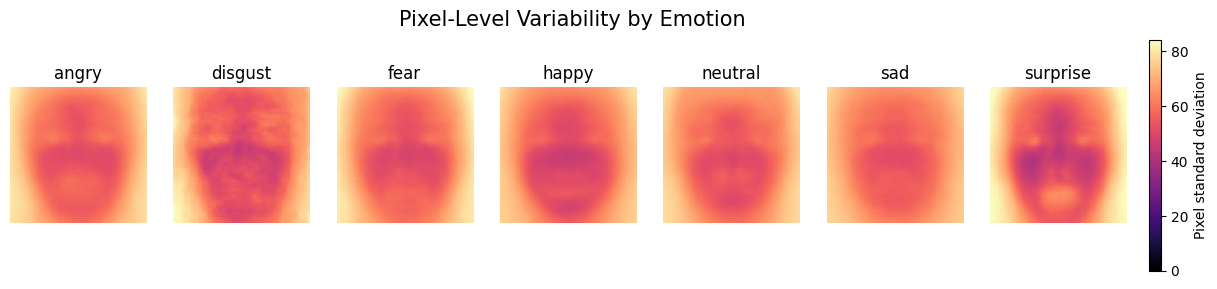

,Mean pixel variability,Maximum pixel variability
Emotion,,
angry,63.00,81.99
disgust,59.97,84.79
fear,63.16,84.58
happy,60.46,79.43
neutral,62.55,80.49
sad,62.96,77.59
surprise,61.86,86.55


In [ ]:
# Use one shared colour scale so classes remain comparable.
variability_scale_max = max(
    np.percentile(
        variability_images[emotion],
        99
    )
    for emotion in EMOTION_CLASSES
)

fig, axes = plt.subplots(1, 7, figsize=(15, 3))

for ax, emotion in zip(axes, EMOTION_CLASSES):
    image_plot = ax.imshow(
        variability_images[emotion],
        cmap="magma",
        vmin=0,
        vmax=variability_scale_max
    )
    ax.set_title(emotion)
    ax.axis("off")

colorbar = fig.colorbar(
    image_plot,
    ax=axes,
    fraction=0.02,
    pad=0.02
)
colorbar.set_label("Pixel standard deviation")

fig.suptitle(
    "Pixel-Level Variability by Emotion",
    fontsize=15
)

fig.savefig(
    RESULTS_DIR / "chart_11_pixel_variability_by_emotion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

variability_summary = pd.DataFrame({
    "Emotion": EMOTION_CLASSES,
    "Mean pixel variability": [
        variability_images[emotion].mean()
        for emotion in EMOTION_CLASSES
    ],
    "Maximum pixel variability": [
        variability_images[emotion].max()
        for emotion in EMOTION_CLASSES
    ],
}).set_index("Emotion").round(2)

display(variability_summary)

**1. Why did you pick this chart?**

A variability heatmap shows where image information changes most within
each emotion class, which cannot be seen from one-dimensional brightness
or contrast summaries.

**2. What insights were found?**

High-variability regions may occur around facial features, image edges,
or backgrounds. These maps combine expression variation with identity,
alignment, and lighting variation, so they do not isolate emotion alone.

**3. What is the practical impact?**

Substantial variation explains why the model needs convolutional feature
learning and augmentation. It also suggests that better face alignment
could be explored in future work.

### Chart 12: Similarity Between Emotion Average Faces

We calculate Pearson correlation between flattened average images.
The resulting matrix measures similarity in broad spatial intensity
patterns. High similarity may indicate class pairs that could be
difficult to separate, although model errors must later be confirmed
using the confusion matrix.

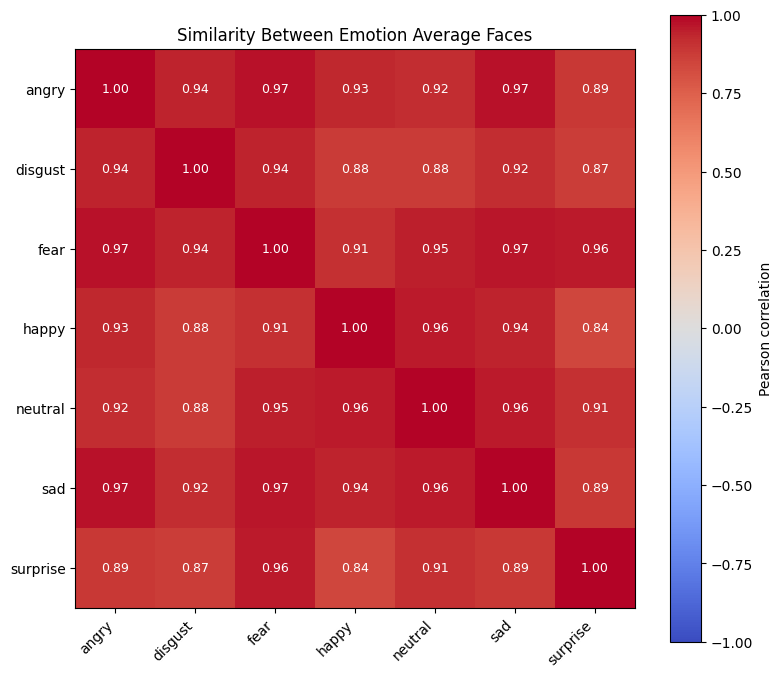

,angry,disgust,fear,happy,neutral,sad,surprise
angry,1.000,0.940,0.971,0.934,0.919,0.970,0.886
disgust,0.940,1.000,0.938,0.880,0.881,0.921,0.873
fear,0.971,0.938,1.000,0.913,0.947,0.967,0.958
happy,0.934,0.880,0.913,1.000,0.955,0.944,0.836
neutral,0.919,0.881,0.947,0.955,1.000,0.956,0.907
sad,0.970,0.921,0.967,0.944,0.956,1.000,0.890
surprise,0.886,0.873,0.958,0.836,0.907,0.890,1.000


Most similar different-class pair: angry and fear
Correlation: 0.971


In [ ]:
mean_face_matrix = np.stack([
    average_images[emotion].ravel()
    for emotion in EMOTION_CLASSES
])

similarity_matrix = np.corrcoef(mean_face_matrix)

assert similarity_matrix.shape == (7, 7)
assert np.allclose(
    np.diag(similarity_matrix),
    1.0
), "Similarity diagonal should equal 1."

fig, ax = plt.subplots(figsize=(8, 7))

matrix_plot = ax.imshow(
    similarity_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(EMOTION_CLASSES)))
ax.set_yticks(range(len(EMOTION_CLASSES)))
ax.set_xticklabels(EMOTION_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(EMOTION_CLASSES)

for row_index in range(len(EMOTION_CLASSES)):
    for column_index in range(len(EMOTION_CLASSES)):
        value = similarity_matrix[row_index, column_index]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.65 else "black",
            fontsize=9
        )

colorbar = fig.colorbar(matrix_plot, ax=ax)
colorbar.set_label("Pearson correlation")

ax.set_title("Similarity Between Emotion Average Faces")

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_12_average_face_similarity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=EMOTION_CLASSES,
    columns=EMOTION_CLASSES
)

display(similarity_df.round(3))

# Find the strongest similarity between two different classes.
off_diagonal = similarity_matrix.copy()
np.fill_diagonal(off_diagonal, -np.inf)

row_index, column_index = np.unravel_index(
    np.argmax(off_diagonal),
    off_diagonal.shape
)

print(
    "Most similar different-class pair:",
    EMOTION_CLASSES[row_index],
    "and",
    EMOTION_CLASSES[column_index]
)

print(
    "Correlation:",
    f"{similarity_matrix[row_index, column_index]:.3f}"
)

**1. Why did you pick this chart?**

A correlation heatmap provides a compact comparison of broad average
image patterns across all emotion pairs.

**2. What insights were found?**

The diagonal equals 1 because every average image is perfectly
correlated with itself. High off-diagonal values identify classes with
similar average spatial patterns. This does not prove that the trained
model will confuse those classes.

**3. What is the practical impact?**

Highly similar class pairs deserve special attention in the later
confusion matrix and error analysis. Their separation may require the
CNN to learn subtle local facial differences.

**2. What insights were found?**

The average images preserve a recognizable central face structure.
Surprise shows a visibly stronger open-mouth pattern, while other
classes have subtler average differences. Surprise also has the highest
average pixel intensity at 145.06, while sad has the lowest at 121.14.
The average images remain blurred because they combine different people,
face positions, lighting conditions, and expression strengths.

**3. What is the practical impact?**

The visible eye and mouth patterns support using a CNN to learn local
spatial features. The blurring demonstrates the need for augmentation
and a model capable of handling identity and alignment variation.

**2. What insights were found?**

Fear has the highest mean pixel variability at 63.16, followed closely
by angry at 63.00 and sad at 62.96. Disgust has the lowest mean
variability at 59.97. Surprise reaches the highest maximum pixel
variability at 86.55. These differences combine facial-expression,
identity, alignment, background, and lighting variation.

**3. What is the practical impact?**

The high variability confirms that emotion recognition cannot rely on
fixed pixel locations alone. Convolution, pooling, and augmentation can
help the model learn patterns that tolerate small spatial and appearance
changes.

**2. What insights were found?**

Angry and fear are the most similar different-class average faces, with
a correlation of 0.971. Angry and sad are also highly similar at 0.970,
while fear and sad have a correlation of 0.967. Happy and surprise have
the lowest observed pairwise similarity at 0.836. All average faces
remain positively correlated because they share the same general facial
structure.

**3. What is the practical impact?**

The model may find angry, fear, and sad more difficult to separate than
classes with less similar average patterns. These pairs should receive
special attention in the confusion matrix and prediction-error review.

### Chart 13: Edge Strength by Emotion

We calculate a simple edge-strength score from the average absolute
difference between neighbouring grayscale pixels. Higher values indicate
stronger local intensity changes, which may arise from facial details,
lighting boundaries, noise, or image sharpness. This score is a proxy
and is not a complete measure of image quality.

Calculating edge strength:   0%|          | 0/27012 [00:00<?, ?it/s]

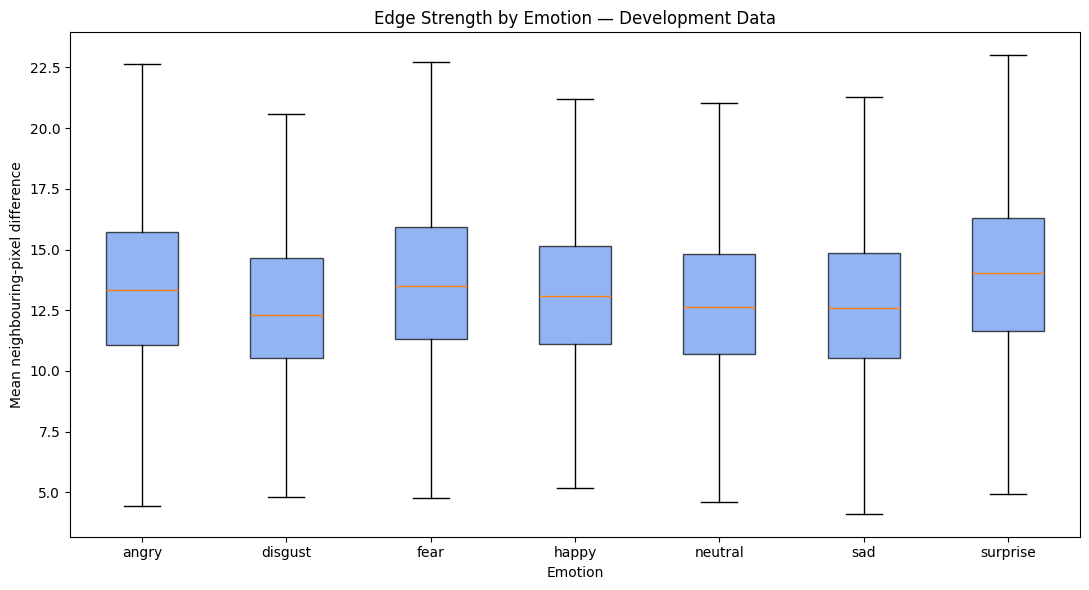

,count,mean,median,std,min,max
emotion,,,,,,
angry,3775,13.65,13.35,3.84,3.00,40.91
disgust,351,12.70,12.32,3.30,4.80,23.74
fear,3799,13.84,13.50,3.96,0.77,46.42
happy,6974,13.30,13.09,3.23,0.84,39.25
neutral,4837,12.86,12.62,3.32,0.11,36.37
sad,4787,12.88,12.59,3.50,3.45,38.50
surprise,2489,14.04,14.04,3.56,3.81,40.13


In [ ]:
edge_records = []

for row in tqdm(
    eda_df.itertuples(index=False),
    total=len(eda_df),
    desc="Calculating edge strength"
):
    with Image.open(row.image_path) as img:
        pixels = np.asarray(
            img.convert("L"),
            dtype=np.float32
        )

    horizontal_edges = np.abs(
        np.diff(pixels, axis=1)
    ).mean()

    vertical_edges = np.abs(
        np.diff(pixels, axis=0)
    ).mean()

    edge_records.append({
        "relative_path": row.relative_path,
        "edge_strength": float(
            (horizontal_edges + vertical_edges) / 2
        ),
    })

edge_df = pd.DataFrame(edge_records)

# Merge safely if the cell is rerun.
eda_df = (
    eda_df.drop(columns="edge_strength", errors="ignore")
    .merge(
        edge_df,
        on="relative_path",
        how="left",
        validate="one_to_one"
    )
)

assert eda_df["edge_strength"].notna().all()
assert (eda_df["edge_strength"] >= 0).all()

edge_values_by_class = [
    eda_df.loc[
        eda_df["emotion"] == emotion,
        "edge_strength"
    ].to_numpy()
    for emotion in EMOTION_CLASSES
]

fig, ax = plt.subplots(figsize=(11, 6))

boxplot = ax.boxplot(
    edge_values_by_class,
    patch_artist=True,
    showfliers=False
)

for box in boxplot["boxes"]:
    box.set_facecolor("cornflowerblue")
    box.set_alpha(0.7)

ax.set_xticks(range(1, len(EMOTION_CLASSES) + 1))
ax.set_xticklabels(EMOTION_CLASSES)
ax.set_title("Edge Strength by Emotion — Development Data")
ax.set_xlabel("Emotion")
ax.set_ylabel("Mean neighbouring-pixel difference")

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_13_edge_strength_by_emotion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

edge_summary = (
    eda_df.groupby("emotion")["edge_strength"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(EMOTION_CLASSES)
    .round(2)
)

display(edge_summary)

eda_df[
    [
        "relative_path",
        "emotion",
        "brightness",
        "contrast",
        "edge_strength",
    ]
].to_csv(
    RESULTS_DIR / "development_image_features.csv",
    index=False
)

**1. Why did you pick this chart?**

The box plots compare local intensity variation across emotion classes
and reveal whether some classes contain systematically stronger or
weaker edge information.

**2. What insights were found?**

The medians and spreads show the typical edge strength and its variation
within every emotion. Differences may reflect facial details, lighting,
noise, or sharpness, so they cannot be attributed only to emotion.

**3. What is the practical impact?**

Very weak edges can make subtle expressions difficult to distinguish.
Variation in edge strength supports using augmentation and evaluating
the model on images with different levels of visible detail.

### Chart 14: PCA Cumulative Explained Variance

We apply Principal Component Analysis to an equal-size sample from every
emotion class. PCA compresses the 48 × 48 pixel space into fewer
components while retaining as much overall variation as possible. PCA
is used here only for exploratory visualization, not as the CNN input.

Loading PCA sample:   0%|          | 0/2450 [00:00<?, ?it/s]

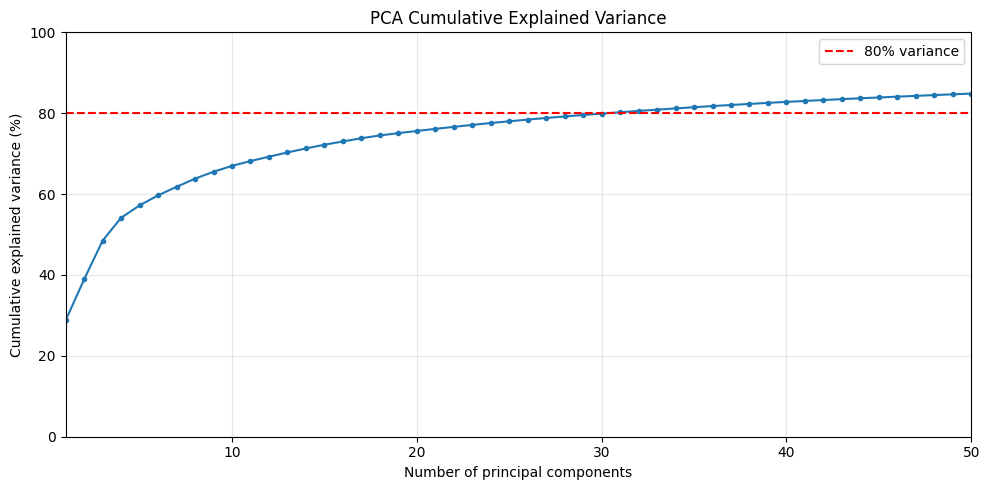

Images sampled per class: 350
Total PCA sample: 2450
Variance explained by first component: 28.76%
Variance explained by first two components: 38.92%
Variance explained by 50 components: 84.85%
Components required for at least 80% variance: 31


In [ ]:
from sklearn.decomposition import PCA

# Use equal class sizes so large classes do not dominate the PCA sample.
sample_size_per_class = min(
    350,
    int(eda_df["emotion"].value_counts().min())
)

pca_sample_df = pd.concat(
    [
        eda_df.loc[
            eda_df["emotion"] == emotion
        ].sample(
            n=sample_size_per_class,
            random_state=42
        )
        for emotion in EMOTION_CLASSES
    ],
    ignore_index=True
)

pixel_matrix = np.empty(
    (
        len(pca_sample_df),
        image_height * image_width
    ),
    dtype=np.float32
)

for index, row in enumerate(
    tqdm(
        pca_sample_df.itertuples(index=False),
        total=len(pca_sample_df),
        desc="Loading PCA sample"
    )
):
    with Image.open(row.image_path) as img:
        pixel_matrix[index] = (
            np.asarray(
                img.convert("L"),
                dtype=np.float32
            ).ravel() / 255.0
        )

number_of_components = 50

pca_model = PCA(
    n_components=number_of_components,
    svd_solver="randomized",
    random_state=42
)

pca_scores = pca_model.fit_transform(pixel_matrix)

cumulative_variance = np.cumsum(
    pca_model.explained_variance_ratio_
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(1, number_of_components + 1),
    cumulative_variance * 100,
    marker="o",
    markersize=3
)

ax.axhline(
    80,
    color="red",
    linestyle="--",
    label="80% variance"
)

ax.set_title("PCA Cumulative Explained Variance")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_xlim(1, number_of_components)
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_14_pca_explained_variance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Images sampled per class:", sample_size_per_class)
print("Total PCA sample:", len(pca_sample_df))
print(
    "Variance explained by first component:",
    f"{pca_model.explained_variance_ratio_[0] * 100:.2f}%"
)
print(
    "Variance explained by first two components:",
    f"{cumulative_variance[1] * 100:.2f}%"
)
print(
    "Variance explained by 50 components:",
    f"{cumulative_variance[-1] * 100:.2f}%"
)

if cumulative_variance[-1] >= 0.80:
    components_for_80 = (
        np.searchsorted(cumulative_variance, 0.80) + 1
    )
    print(
        "Components required for at least 80% variance:",
        components_for_80
    )
else:
    print(
        "The first 50 components do not reach 80% variance."
    )

**1. Why did you pick this chart?**

The cumulative explained-variance curve shows how much raw-pixel
information can be represented using progressively more PCA components.

**2. What insights were found?**

A gradual curve means facial-image variation is distributed across many
directions rather than being explained by only a few components. PCA
captures overall variance and does not specifically optimize emotion
separation.

**3. What is the practical impact?**

If many components are needed, a simple low-dimensional linear
representation may lose useful facial detail. This supports using a CNN
to learn nonlinear and spatial features directly from images.

### Chart 15: Two-Dimensional PCA Projection

We project the balanced image sample onto the first two principal
components and colour points by emotion. This multivariate visualization
shows whether classes separate in a simple linear raw-pixel space.
Overlap is expected because PCA maximizes overall variance rather than
emotion-class separation.

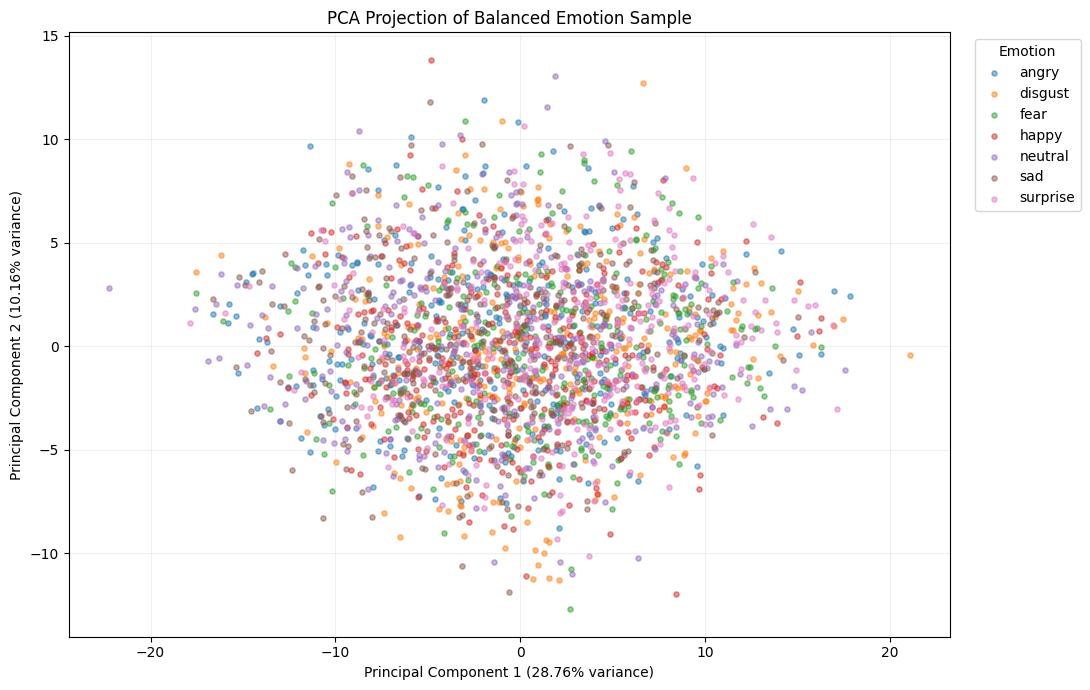

Points displayed: 2450
PC1 variance: 28.76%
PC2 variance: 10.16%
Combined PC1 and PC2 variance: 38.92%


In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))

colour_map = plt.get_cmap("tab10")

for class_index, emotion in enumerate(EMOTION_CLASSES):
    emotion_mask = (
        pca_sample_df["emotion"].to_numpy() == emotion
    )

    ax.scatter(
        pca_scores[emotion_mask, 0],
        pca_scores[emotion_mask, 1],
        s=14,
        alpha=0.5,
        color=colour_map(class_index),
        label=emotion
    )

pc1_variance = (
    pca_model.explained_variance_ratio_[0] * 100
)
pc2_variance = (
    pca_model.explained_variance_ratio_[1] * 100
)

ax.set_title("PCA Projection of Balanced Emotion Sample")
ax.set_xlabel(
    f"Principal Component 1 ({pc1_variance:.2f}% variance)"
)
ax.set_ylabel(
    f"Principal Component 2 ({pc2_variance:.2f}% variance)"
)
ax.legend(
    title="Emotion",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "chart_15_pca_emotion_projection.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Points displayed:", len(pca_sample_df))
print(f"PC1 variance: {pc1_variance:.2f}%")
print(f"PC2 variance: {pc2_variance:.2f}%")
print(
    "Combined PC1 and PC2 variance:",
    f"{pc1_variance + pc2_variance:.2f}%"
)

**1. Why did you pick this chart?**

A two-dimensional PCA plot provides a compact multivariate view of
raw-pixel similarities and differences across all emotion classes.

**2. What insights were found?**

Overlapping class points indicate that the seven emotions are not
cleanly separable using only two linear combinations of raw pixels.
Any separation may also reflect lighting, face alignment, or identity
rather than expression alone.

**3. What is the practical impact?**

The overlap supports using a CNN, which can learn nonlinear local
patterns around the eyes, eyebrows, and mouth. Final separability must
be assessed from model predictions rather than the PCA plot alone.

**2. What insights were found?**

Surprise has the highest mean and median edge strength at 14.04. Fear
has the next-highest mean at 13.84 and reaches the largest maximum value
of 46.42. Disgust has the lowest mean edge strength at 12.70. Differences
are modest and may reflect facial details, lighting, noise, or sharpness.

**3. What is the practical impact?**

Some classes contain slightly stronger local image detail than others.
The CNN should learn expression shapes rather than relying on edge
strength alone. Augmentation and class-wise evaluation can help monitor
this behaviour.

**2. What insights were found?**

The first principal component explains 28.76% of raw-pixel variance and
the first two components together explain 38.92%. At least 31 components
are required to represent 80% of the variance, while 50 components
represent 84.85%. Facial-image variation is therefore spread across
many dimensions.

**3. What is the practical impact?**

Two-dimensional linear compression loses most of the dataset's
information. This supports using a CNN to learn richer nonlinear and
spatial representations directly from facial images.

**2. What insights were found?**

The first two principal components display substantial overlap among all
seven emotion classes. They explain only 38.92% of total raw-pixel
variance, and no emotion forms a completely separate cluster. This
shows that raw pixels are not easily separated into emotion classes
using only two linear dimensions.

**3. What is the practical impact?**

The overlap supports using convolutional feature learning instead of a
simple two-dimensional linear classifier. Final class separation must
be assessed using the CNN's held-out predictions.

### Hypothetical Statement 1: Emotion Classes Are Equally Represented

**Null hypothesis (H₀):** The seven emotion classes occur in equal
proportions in the cleaned development dataset.

**Alternative hypothesis (H₁):** At least one emotion class has a
different proportion.

A chi-square goodness-of-fit test is appropriate because we are comparing
observed categorical frequencies against equal expected frequencies.
Cohen's w is also calculated to describe the magnitude of the imbalance.

In [ ]:
from scipy.stats import chisquare, kruskal, chi2_contingency

alpha = 0.05

observed_class_counts = (
    eda_df["emotion"]
    .value_counts()
    .reindex(EMOTION_CLASSES)
    .to_numpy()
)

expected_class_counts = np.full(
    len(EMOTION_CLASSES),
    observed_class_counts.sum() / len(EMOTION_CLASSES)
)

chi_square_statistic, class_balance_p_value = chisquare(
    f_obs=observed_class_counts,
    f_exp=expected_class_counts
)

degrees_of_freedom = len(EMOTION_CLASSES) - 1

cohens_w = np.sqrt(
    chi_square_statistic / observed_class_counts.sum()
)

class_balance_table = pd.DataFrame({
    "Emotion": EMOTION_CLASSES,
    "Observed": observed_class_counts,
    "Expected under H0": expected_class_counts,
}).set_index("Emotion")

display(class_balance_table.round(2))

print(f"Chi-square statistic: {chi_square_statistic:.3f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {class_balance_p_value:.3e}")
print(f"Cohen's w: {cohens_w:.3f}")
if class_balance_p_value < alpha:
    print(
        "Decision: Reject H0. "
        "The emotion classes are not equally represented."
    )
else:
    print(
        "Decision: Fail to reject H0. "
        "There is insufficient evidence of unequal representation."
    )

,Observed,Expected under H0
Emotion,,
angry,3775,3858.86
disgust,351,3858.86
fear,3799,3858.86
happy,6974,3858.86
neutral,4837,3858.86
sad,4787,3858.86
surprise,2489,3858.86


Chi-square statistic: 6663.764
Degrees of freedom: 6
P-value: 0.000e+00
Cohen's w: 0.497
Decision: Reject H0. The emotion classes are not equally represented.


#### Which statistical test was performed?

A chi-square goodness-of-fit test was performed.

#### Why was this test selected?

The variable is categorical and the analysis compares observed emotion
counts with equal expected counts. The significant result confirms
class imbalance. Cohen's w of approximately 0.497 indicates a substantial
difference from a uniform distribution, rather than relying only on the
p-value.

### Hypothetical Statement 2: Brightness Is Identically Distributed Across Emotions

**Null hypothesis (H₀):** Image brightness follows the same distribution
across all seven emotion classes.

**Alternative hypothesis (H₁):** At least one emotion class has a
different brightness distribution.

The Kruskal–Wallis test is used because it compares more than two
independent groups without requiring normally distributed measurements.
With a large dataset, statistical significance can occur for small
differences, so an epsilon-squared effect size is also reported.

In [ ]:
brightness_groups = [
    eda_df.loc[
        eda_df["emotion"] == emotion,
        "brightness"
    ].dropna().to_numpy()
    for emotion in EMOTION_CLASSES
]

assert all(len(group) > 0 for group in brightness_groups)

brightness_h_statistic, brightness_p_value = kruskal(
    *brightness_groups
)

brightness_sample_size = sum(
    len(group) for group in brightness_groups
)

number_of_groups = len(brightness_groups)

brightness_epsilon_squared = max(
    0,
    (
        brightness_h_statistic
        - number_of_groups
        + 1
    )
    / (
        brightness_sample_size
        - number_of_groups
    )
)

brightness_test_summary = (
    eda_df.groupby("emotion")["brightness"]
    .agg(["count", "median", "mean"])
    .reindex(EMOTION_CLASSES)
    .round(2)
)

display(brightness_test_summary)

print(
    "Kruskal-Wallis H statistic:",
    f"{brightness_h_statistic:.3f}"
)
print(f"Degrees of freedom: {number_of_groups - 1}")
print(f"P-value: {brightness_p_value:.3e}")
print(
    "Epsilon-squared effect size:",
    f"{brightness_epsilon_squared:.4f}"
)

if brightness_p_value < alpha:
    print(
        "Decision: Reject H0. At least one emotion class "
        "has a different brightness distribution."
    )
else:
    print(
        "Decision: Fail to reject H0. There is insufficient "
        "evidence of a brightness-distribution difference."
    )

,count,median,mean
emotion,,,
angry,3775,127.18,126.12
disgust,351,131.12,134.04
fear,3799,136.32,134.88
happy,6974,127.39,128.68
neutral,4837,123.62,123.93
sad,4787,121.17,121.14
surprise,2489,146.76,145.06


Kruskal-Wallis H statistic: 1091.631
Degrees of freedom: 6
P-value: 1.349e-232
Epsilon-squared effect size: 0.0402
Decision: Reject H0. At least one emotion class has a different brightness distribution.


#### Which statistical test was performed?

A Kruskal–Wallis H test was performed.

#### Why was this test selected?

Brightness is continuous and is compared across seven independent emotion
classes. The test does not assume normal distributions and is suitable
for the observed wide brightness range. The effect size is considered
alongside the p-value because the large sample can make small differences
statistically significant.

### Hypothetical Statement 3: Dataset Role Is Independent of Emotion

**Null hypothesis (H₀):** Emotion class and dataset role
(development or test) are independent.

**Alternative hypothesis (H₁):** Emotion class and dataset role are
associated.

A chi-square test of independence is suitable because both variables
are categorical. Cramér's V is reported to measure the strength of any
association and distinguish statistical significance from practical
importance.

In [ ]:
role_emotion_table = pd.crosstab(
    clean_df["emotion"],
    clean_df["dataset_role"]
).reindex(
    index=EMOTION_CLASSES,
    columns=["development", "test"],
    fill_value=0
)

(
    split_chi_square,
    split_p_value,
    split_degrees_of_freedom,
    expected_frequencies
) = chi2_contingency(role_emotion_table)

number_of_rows, number_of_columns = (
    role_emotion_table.shape
)

cramers_v = np.sqrt(
    split_chi_square
    / (
        role_emotion_table.to_numpy().sum()
        * min(
            number_of_rows - 1,
            number_of_columns - 1
        )
    )
)

display(role_emotion_table)

print(f"Chi-square statistic: {split_chi_square:.3f}")
print(f"Degrees of freedom: {split_degrees_of_freedom}")
print(f"P-value: {split_p_value:.3e}")
print(f"Cohen's w: {cohens_w:.3f}")
print(
    "Smallest expected frequency:",
    f"{expected_frequencies.min():.2f}"
)

if split_p_value < alpha:
    print(
        "Decision: Reject H0. Dataset role and emotion "
        "have a statistically detectable association."
    )
else:
    print(
        "Decision: Fail to reject H0. There is insufficient "
        "evidence of an association."
    )

dataset_role,development,test
emotion,,
angry,3775,942
disgust,351,107
fear,3799,1003
happy,6974,1820
neutral,4837,1209
sad,4787,1125
surprise,2489,759


Chi-square statistic: 28.948
Degrees of freedom: 6
P-value: 6.224e-05
Cohen's w: 0.497
Smallest expected frequency: 93.89
Decision: Reject H0. Dataset role and emotion have a statistically detectable association.


#### Which statistical test was performed?

A chi-square test of independence was performed.

#### Why was this test selected?

Both emotion and dataset role are categorical variables, and all expected
cell frequencies exceed five. Although the test detects a statistically
significant association, Cramér's V of approximately 0.029 indicates a
very weak practical association. This agrees with the earlier finding
that the maximum class-proportion gap is only 1.68 percentage points.

### Data Splitting

The cleaned development data is divided into training and validation
sets using an 80:20 stratified split. Stratification preserves the
emotion-class proportions in both subsets. The cleaned original
validation folder remains an untouched held-out test set and will not
be used for model selection or hyperparameter tuning.

Exact pixel duplicates were removed before splitting. Different images
of the same person may still occur across subsets because person
identifiers are not available.

In [ ]:
from sklearn.model_selection import train_test_split

development_df = clean_df.loc[
    clean_df["dataset_role"] == "development"
].copy()

test_df = clean_df.loc[
    clean_df["dataset_role"] == "test"
].copy()

train_df, validation_df = train_test_split(
    development_df,
    test_size=0.20,
    random_state=42,
    stratify=development_df["emotion"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Confirm that no exact image hash appears in multiple subsets.
train_hashes = set(train_df["pixel_hash"])
validation_hashes = set(validation_df["pixel_hash"])
test_hashes = set(test_df["pixel_hash"])

assert train_hashes.isdisjoint(validation_hashes)
assert train_hashes.isdisjoint(test_hashes)
assert validation_hashes.isdisjoint(test_hashes)

assert (
    len(train_df)
    + len(validation_df)
    + len(test_df)
    == len(clean_df)
)

split_counts = pd.DataFrame({
    "Training": (
        train_df["emotion"]
        .value_counts()
        .reindex(EMOTION_CLASSES, fill_value=0)
    ),
    "Validation": (
        validation_df["emotion"]
        .value_counts()
        .reindex(EMOTION_CLASSES, fill_value=0)
    ),
    "Test": (
        test_df["emotion"]
        .value_counts()
        .reindex(EMOTION_CLASSES, fill_value=0)
    ),
})

split_counts["Total"] = split_counts.sum(axis=1)

display(split_counts)

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Held-out test images:", len(test_df))
print(
    "Total images:",
    len(train_df) + len(validation_df) + len(test_df)
)
print("Exact hash overlap between subsets: 0")

,Training,Validation,Test,Total
emotion,,,,
angry,3020,755,942,4717
disgust,281,70,107,458
fear,3039,760,1003,4802
happy,5579,1395,1820,8794
neutral,3869,968,1209,6046
sad,3830,957,1125,5912
surprise,1991,498,759,3248


Training images: 21609
Validation images: 5403
Held-out test images: 6965
Total images: 33977
Exact hash overlap between subsets: 0


#### What data splitting ratio was used and why?

The cleaned development data was divided into 80% training and 20%
validation data. This provides sufficient images for learning while
retaining an independent subset for model selection and early stopping.
The original cleaned validation folder was preserved as the final test
set. Stratification was used because the emotion classes are imbalanced.

### Categorical Encoding and Imbalance Handling

The seven emotion names are converted into fixed integer labels required
by the neural-network loss function. Class weights are calculated from
training counts so that errors on rare classes receive greater training
importance. The images are not duplicated or removed to force equal
class sizes.

In [ ]:
label_to_index = {
    emotion: index
    for index, emotion in enumerate(EMOTION_CLASSES)
}

index_to_label = {
    index: emotion
    for emotion, index in label_to_index.items()
}

for dataframe in [train_df, validation_df, test_df]:
    dataframe["label"] = (
        dataframe["emotion"]
        .map(label_to_index)
        .astype("int32")
    )

assert train_df["label"].notna().all()
assert validation_df["label"].notna().all()
assert test_df["label"].notna().all()

training_class_counts = (
    train_df["emotion"]
    .value_counts()
    .reindex(EMOTION_CLASSES)
)

number_of_training_images = len(train_df)
number_of_classes = len(EMOTION_CLASSES)

class_weight = {
    label_to_index[emotion]:
    number_of_training_images
    / (
        number_of_classes
        * training_class_counts[emotion]
    )
    for emotion in EMOTION_CLASSES
}

class_weight_table = pd.DataFrame({
    "Label index": [
        label_to_index[emotion]
        for emotion in EMOTION_CLASSES
    ],
    "Training images": training_class_counts,
    "Class weight": [
        class_weight[label_to_index[emotion]]
        for emotion in EMOTION_CLASSES
    ],
}, index=EMOTION_CLASSES)

display(class_weight_table.round(3))

print("Label mapping:")
print(label_to_index)

# Save portable split records to Google Drive.
for split_name, dataframe in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():
    dataframe[
        [
            "relative_path",
            "emotion",
            "label",
            "pixel_hash",
        ]
    ].to_csv(
        RESULTS_DIR / f"{split_name}_split.csv",
        index=False
    )

print("Split inventories saved to:", RESULTS_DIR)

,Label index,Training images,Class weight
angry,0,3020,1.022
disgust,1,281,10.986
fear,2,3039,1.016
happy,3,5579,0.553
neutral,4,3869,0.798
sad,5,3830,0.806
surprise,6,1991,1.550


Label mapping:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Split inventories saved to: /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/results


#### Which categorical encoding technique was used and why?

Fixed integer label encoding was used because the target contains seven
mutually exclusive emotion classes. The model will use sparse categorical
cross-entropy, which accepts integer class labels directly.

#### How was the imbalanced dataset handled?

Class weights were calculated using inverse class frequency. This gives
greater loss importance to underrepresented emotions such as disgust
without creating synthetic facial images or discarding valid examples.
Class weights will be applied only during model training.

### Image Transformation and TensorFlow Input Pipeline

Images are decoded as single-channel grayscale inputs, resized to
48 × 48 pixels, converted to float32, and normalized from the original
0–255 range to 0–1. Training data is shuffled, while validation and test
data retain a deterministic order. Augmentation will be added inside
the training model and will not affect validation or test images.

In [ ]:
import tensorflow as tf

IMAGE_SIZE = (48, 48)
BATCH_SIZE = 64
RANDOM_SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

def load_grayscale_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_jpeg(
        image_bytes,
        channels=1
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label


def create_image_dataset(
    dataframe,
    training=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_path"].to_numpy(),
            dataframe["label"].to_numpy()
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_grayscale_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_image_dataset(
    train_df,
    training=True
)

validation_dataset = create_image_dataset(
    validation_df
)

test_dataset = create_image_dataset(
    test_df
)

sample_images, sample_labels = next(
    iter(train_dataset)
)

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Image data type:", sample_images.dtype)
print(
    "Pixel-value range:",
    float(tf.reduce_min(sample_images)),
    "to",
    float(tf.reduce_max(sample_images))
)
print(
    "Sample label range:",
    int(tf.reduce_min(sample_labels)),
    "to",
    int(tf.reduce_max(sample_labels))
)

assert sample_images.shape[1:] == (48, 48, 1)
assert sample_images.dtype == tf.float32
assert float(tf.reduce_min(sample_images)) >= 0.0
assert float(tf.reduce_max(sample_images)) <= 1.0

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Image batch shape: (64, 48, 48, 1)
Label batch shape: (64,)
Image data type: <dtype: 'float32'>
Pixel-value range: 0.0 to 1.0
Sample label range: 0 to 6


#### Which transformation and scaling methods were used?

Every image was converted to grayscale, resized to 48 × 48 pixels, cast
to float32, and divided by 255. This min-max normalization places pixel
values between 0 and 1, producing a stable numerical range for neural
network optimization.

#### Was dimensionality reduction applied?

Explicit dimensionality reduction was not applied to the CNN inputs.
The PCA analysis was exploratory only. A CNN learns hierarchical spatial
representations internally, while PCA would flatten images and discard
part of their spatial structure.

### Hardware Accelerator Verification

Deep-learning model training is computationally intensive. We verify
that a GPU is available before training to reduce training time. The
project can run on a CPU, but training would be considerably slower.

In [ ]:
gpu_devices = tf.config.list_physical_devices("GPU")

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", gpu_devices)

assert gpu_devices, (
    "GPU was not detected. In Colab, select "
    "Runtime > Change runtime type > T4 GPU, "
    "then run the notebook again."
)

print("GPU verification successful.")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU verification successful.


### Data Augmentation

Data augmentation creates slightly modified training images using
horizontal flips, small rotations, translations, zoom changes, and
contrast variation. These transformations simulate natural image
variation and reduce overfitting. Augmentation is active only during
training and is never applied to validation or test images. Vertical
flipping is avoided because upside-down faces are unrealistic for the
target application.

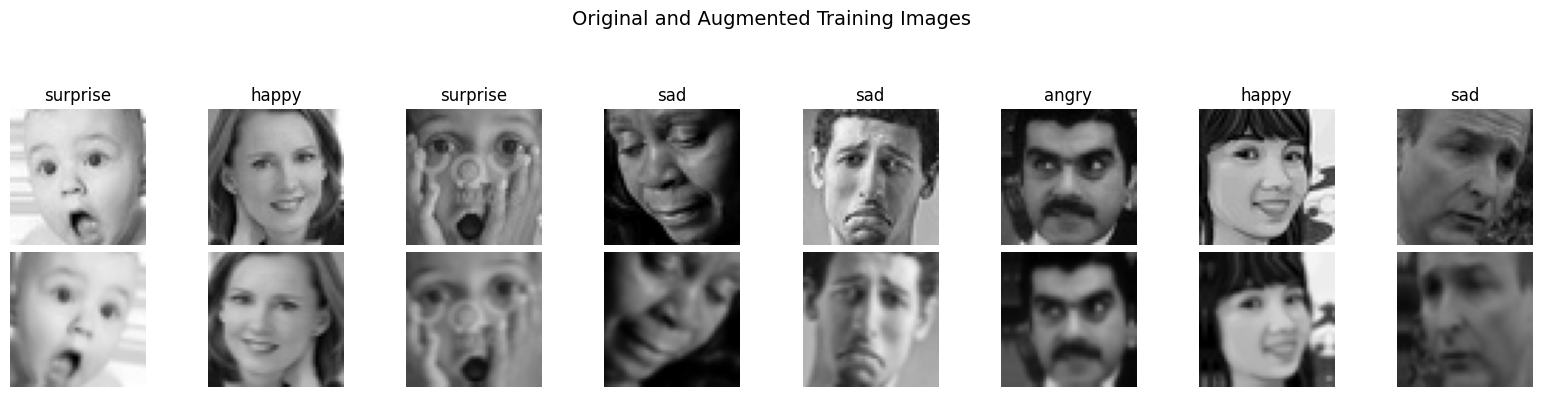

Original batch shape: (64, 48, 48, 1)
Augmented preview shape: (8, 48, 48, 1)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            mode="horizontal",
            seed=RANDOM_SEED
        ),
        layers.RandomRotation(
            factor=0.05,
            fill_mode="reflect",
            seed=RANDOM_SEED
        ),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="reflect",
            seed=RANDOM_SEED
        ),
        layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="reflect",
            seed=RANDOM_SEED
        ),
        layers.RandomContrast(
            factor=0.10,
            seed=RANDOM_SEED
        ),
    ],
    name="training_augmentation"
)

preview_images, preview_labels = next(
    iter(train_dataset)
)

augmented_images = data_augmentation(
    preview_images[:8],
    training=True
)

fig, axes = plt.subplots(
    2,
    8,
    figsize=(16, 4)
)

for index in range(8):
    label_name = index_to_label[
        int(preview_labels[index])
    ]

    axes[0, index].imshow(
        preview_images[index, :, :, 0],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, index].set_title(label_name)
    axes[0, index].axis("off")

    axes[1, index].imshow(
        augmented_images[index, :, :, 0],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, index].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Augmented", fontsize=11)

fig.suptitle(
    "Original and Augmented Training Images",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

fig.savefig(
    RESULTS_DIR / "augmentation_preview.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Original batch shape:", preview_images.shape)
print("Augmented preview shape:", augmented_images.shape)

assert augmented_images.shape == (8, 48, 48, 1)

#### Which augmentation techniques were used and why?

Horizontal flipping helps the model handle left-right facial variation.
Small rotations, translations, and zoom changes account for imperfect
face positioning. Contrast variation improves tolerance to lighting
differences observed during EDA. Transformation ranges were kept
moderate to avoid changing the expression label.

### ML Model 1: Custom Convolutional Neural Network

The baseline model contains three convolutional blocks. Convolution
layers learn local facial patterns, batch normalization stabilizes
training, and max pooling reduces spatial dimensions. Global average
pooling limits the number of parameters, while dropout reduces
overfitting. The final softmax layer produces probabilities for the
seven emotion classes.

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)

custom_cnn = keras.Sequential(
    [
        layers.Input(
            shape=(48, 48, 1),
            name="grayscale_face"
        ),

        data_augmentation,

        layers.Conv2D(
            32,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation="relu"
        ),
        layers.Dropout(0.40),

        layers.Dense(
            number_of_classes,
            activation="softmax",
            name="emotion_probabilities"
        ),
    ],
    name="DeepFER_Custom_CNN"
)

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

custom_cnn.summary()

assert custom_cnn.output_shape == (None, 7)

Model: "DeepFER_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ training_augmentation           │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_probabilities (Dense)   │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,983 (433.53 KB)

 Trainable params: 110,535 (431.78 KB)

 Non-trainable params: 448 (1.75 KB)

#### Why was a CNN selected?

CNNs learn spatial features such as edges, eye shapes, eyebrow positions,
and mouth patterns directly from images. Shared convolution filters make
them more parameter-efficient than fully connected networks operating
on flattened pixels.

#### Why was this architecture used?

Three convolutional blocks allow the model to progress from simple
edges to higher-level facial patterns. Batch normalization supports
stable optimization, max pooling provides limited spatial tolerance,
and dropout reduces overfitting. Softmax is suitable because every image
belongs to one of seven mutually exclusive classes.

### Training Strategy and Optimization

The model uses Adam optimization with an initial learning rate of 0.001.
Early stopping prevents unnecessary training when validation loss stops
improving. ReduceLROnPlateau lowers the learning rate when progress
slows, while ModelCheckpoint saves the model with the lowest validation
loss. These decisions improve training efficiency and reduce overfitting.

In [ ]:
MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CUSTOM_CNN_PATH = (
    MODELS_DIR / "custom_cnn_best.keras"
)

custom_cnn_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(CUSTOM_CNN_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        filename=str(
            RESULTS_DIR / "custom_cnn_training_log.csv"
        ),
        append=False
    ),

    keras.callbacks.TerminateOnNaN()
]

print("Best-model path:", CUSTOM_CNN_PATH)
print("Maximum epochs: 30")
print("Early-stopping patience: 6 epochs")
print("Learning-rate reduction patience: 3 epochs")

Best-model path: /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/custom_cnn_best.keras
Maximum epochs: 30
Early-stopping patience: 6 epochs
Learning-rate reduction patience: 3 epochs


#### Which optimization techniques were used?

Adam was selected because it adapts the learning rate for individual
parameters and performs well as a baseline optimizer. Early stopping
limits overfitting and wasted computation. Learning-rate reduction
allows smaller optimization steps when validation improvement slows.
The best checkpoint is selected using validation loss rather than test
performance.


### Custom CNN Training

The custom CNN is trained for a maximum of 30 epochs using the training
dataset. Validation data monitors generalization after every epoch.
Inverse-frequency class weights increase the training importance of
underrepresented classes, particularly disgust. The held-out test set
is not used during this process.

In [ ]:
MAX_EPOCHS = 30

custom_cnn_history = custom_cnn.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weight,
    callbacks=custom_cnn_callbacks,
    verbose=1
)

completed_epochs = len(
    custom_cnn_history.history["loss"]
)

best_epoch_index = int(
    np.argmin(
        custom_cnn_history.history["val_loss"]
    )
)

best_epoch_number = best_epoch_index + 1

print("\nTraining completed.")
print("Epochs completed:", completed_epochs)
print("Best epoch:", best_epoch_number)
print(
    "Best validation loss:",
    f"{custom_cnn_history.history['val_loss'][best_epoch_index]:.4f}"
)
print(
    "Validation accuracy at best epoch:",
    f"{custom_cnn_history.history['val_accuracy'][best_epoch_index]:.4f}"
)
print("Best model saved to:", CUSTOM_CNN_PATH)

assert CUSTOM_CNN_PATH.is_file(), (
    "Best model checkpoint was not saved."
)

assert np.isfinite(
    custom_cnn_history.history["val_loss"]
).all(), "Non-finite validation loss detected."

Epoch 1/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1582 - loss: 2.0658
Epoch 1: val_loss improved from None to 2.00595, saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/custom_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/custom_cnn_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.1699 - loss: 1.9599 - val_accuracy: 0.1797 - val_loss: 2.0059 - learning_rate: 0.0010
Epoch 2/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1945 - loss: 1.9019
Epoch 2: val_loss did not improve from 2.00595
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1951 - loss: 1.8993 - val_accuracy: 0.1288 - val_loss: 2.2944 - learning_rate: 0.0010
Epoch 3/30
336/338 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2290 - loss: 1.8526
Epoch 3: val_loss improved from 2.00595 to 1.87015, saving model to /content/drive/MyDrive/

### Custom CNN Training and Validation Curves

Loss and accuracy curves show how the model learned across epochs.
A declining training loss indicates learning, while validation loss
measures generalization. A widening gap between training and validation
performance can indicate overfitting. The epoch with minimum validation
loss is marked as the selected checkpoint.

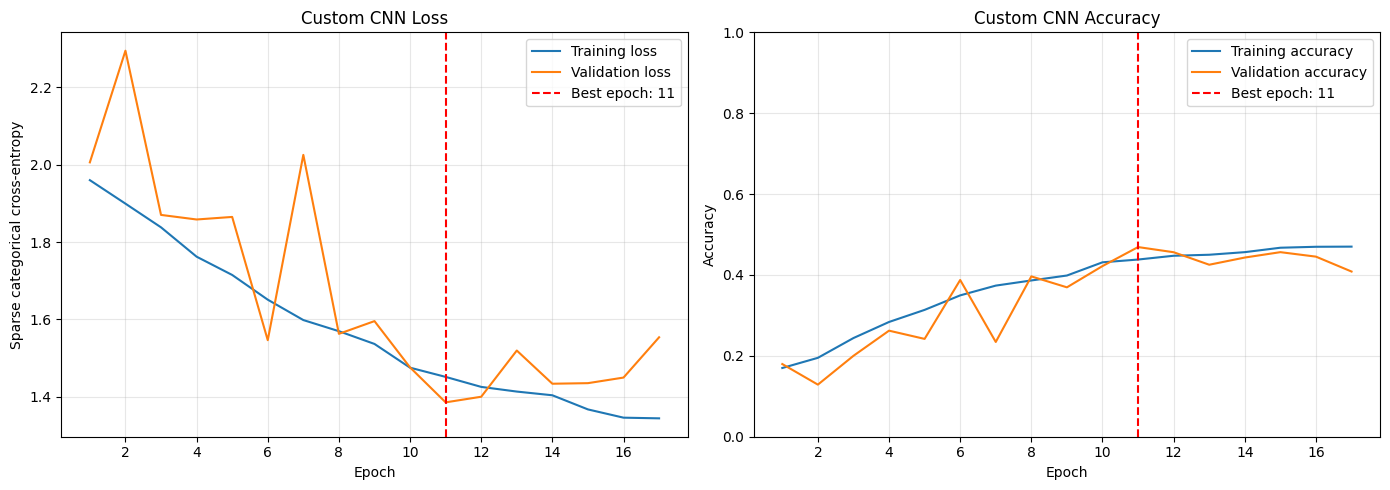

Selected epoch: 11
Training accuracy: 0.4382
Validation accuracy: 0.4690
Training-validation accuracy gap: -0.0308
Interpretation: No large accuracy gap is visible at the selected epoch.


In [ ]:
custom_history_df = pd.DataFrame(
    custom_cnn_history.history
)

custom_history_df.index = np.arange(
    1,
    len(custom_history_df) + 1
)

custom_history_df.index.name = "epoch"

custom_history_df.to_csv(
    RESULTS_DIR / "custom_cnn_history.csv"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Loss curve.
axes[0].plot(
    custom_history_df.index,
    custom_history_df["loss"],
    label="Training loss"
)

axes[0].plot(
    custom_history_df.index,
    custom_history_df["val_loss"],
    label="Validation loss"
)

axes[0].axvline(
    best_epoch_number,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch_number}"
)

axes[0].set_title("Custom CNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve.
axes[1].plot(
    custom_history_df.index,
    custom_history_df["accuracy"],
    label="Training accuracy"
)

axes[1].plot(
    custom_history_df.index,
    custom_history_df["val_accuracy"],
    label="Validation accuracy"
)

axes[1].axvline(
    best_epoch_number,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch_number}"
)

axes[1].set_title("Custom CNN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "custom_cnn_learning_curves.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

best_training_accuracy = custom_history_df.loc[
    best_epoch_number,
    "accuracy"
]

best_validation_accuracy = custom_history_df.loc[
    best_epoch_number,
    "val_accuracy"
]

accuracy_gap = (
    best_training_accuracy
    - best_validation_accuracy
)

print("Selected epoch:", best_epoch_number)
print(
    "Training accuracy:",
    f"{best_training_accuracy:.4f}"
)
print(
    "Validation accuracy:",
    f"{best_validation_accuracy:.4f}"
)
print(
    "Training-validation accuracy gap:",
    f"{accuracy_gap:.4f}"
)

if accuracy_gap > 0.10:
    print(
        "Interpretation: The accuracy gap suggests "
        "possible overfitting."
    )
else:
    print(
        "Interpretation: No large accuracy gap is visible "
        "at the selected epoch."
    )

### Model 1 Validation Evaluation

The saved best custom CNN is evaluated on the validation set. Validation
predictions are used to calculate detailed metrics and study model
errors. The held-out test set remains untouched until all candidate
models have been trained and the final model has been selected.

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

best_custom_cnn = keras.models.load_model(
    str(CUSTOM_CNN_PATH)
)

validation_loss, validation_accuracy = (
    best_custom_cnn.evaluate(
        validation_dataset,
        verbose=1
    )
)

validation_probabilities = (
    best_custom_cnn.predict(
        validation_dataset,
        verbose=1
    )
)

validation_predictions = np.argmax(
    validation_probabilities,
    axis=1
)

validation_true_labels = (
    validation_df["label"]
    .to_numpy()
)

assert len(validation_predictions) == len(validation_df)
assert validation_probabilities.shape == (
    len(validation_df),
    number_of_classes
)

assert np.allclose(
    validation_probabilities.sum(axis=1),
    1.0,
    atol=1e-5
)

print(f"Validation loss: {validation_loss:.4f}")
print(
    "Validation accuracy:",
    f"{validation_accuracy:.4f}",
    f"({validation_accuracy * 100:.2f}%)"
)
print(
    "Predictions generated:",
    len(validation_predictions)
)
print(
    "Probability matrix shape:",
    validation_probabilities.shape
)

85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4690 - loss: 1.3859
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Validation loss: 1.3859
Validation accuracy: 0.4690 (46.90%)
Predictions generated: 5403
Probability matrix shape: (5403, 7)


### Model 1 Classification Metrics

Accuracy measures the overall proportion of correct predictions.
Precision measures how often predictions for an emotion are correct,
while recall measures how many actual images of that emotion are found.
F1-score balances precision and recall. Macro averages give every class
equal importance and are particularly useful for this imbalanced dataset.

,precision,recall,f1-score,support
angry,0.372,0.257,0.304,755.000
disgust,0.089,0.357,0.142,70.000
fear,0.317,0.208,0.251,760.000
happy,0.791,0.646,0.711,1395.000
neutral,0.381,0.638,0.478,968.000
sad,0.442,0.293,0.352,957.000
surprise,0.506,0.719,0.594,498.000
accuracy,0.469,0.469,0.469,0.469
macro avg,0.414,0.445,0.404,5403.000
weighted avg,0.495,0.469,0.466,5403.000


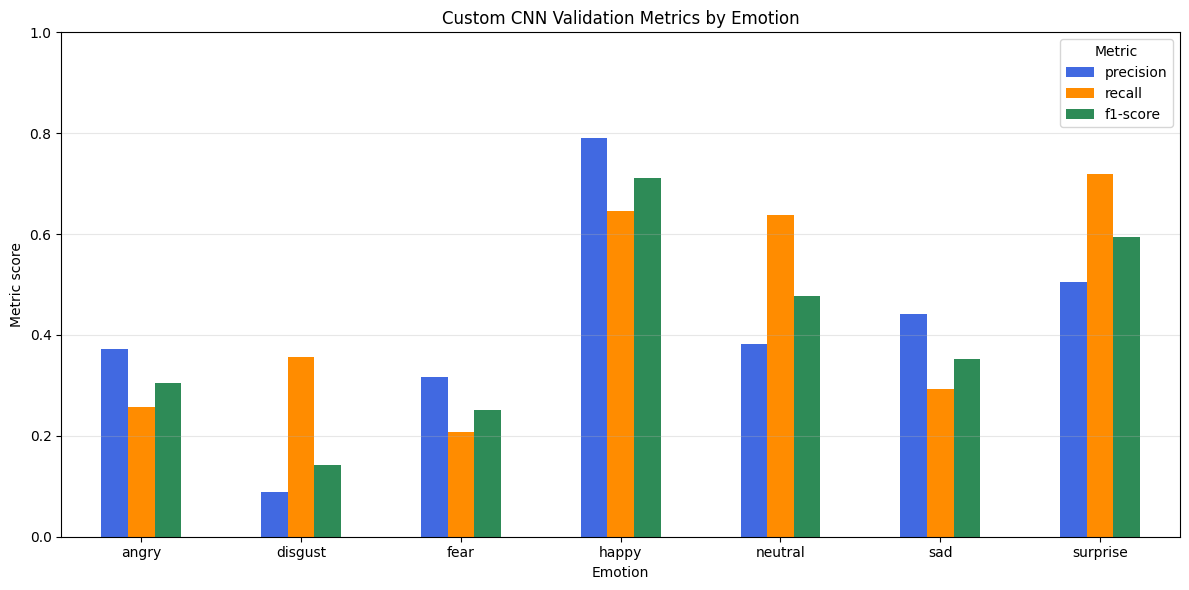

Validation accuracy: 0.4690
Macro precision: 0.4139
Macro recall: 0.4454
Macro F1-score: 0.4045
Weighted F1-score: 0.4659


In [ ]:
label_indices = list(
    range(number_of_classes)
)

custom_classification_report = classification_report(
    validation_true_labels,
    validation_predictions,
    labels=label_indices,
    target_names=EMOTION_CLASSES,
    output_dict=True,
    zero_division=0
)

custom_metrics_df = (
    pd.DataFrame(
        custom_classification_report
    )
    .transpose()
)

display(
    custom_metrics_df.round(3)
)

custom_metrics_df.to_csv(
    RESULTS_DIR
    / "custom_cnn_validation_classification_report.csv"
)

class_metric_table = custom_metrics_df.loc[
    EMOTION_CLASSES,
    ["precision", "recall", "f1-score"]
]

fig, ax = plt.subplots(figsize=(12, 6))

class_metric_table.plot(
    kind="bar",
    ax=ax,
    color=[
        "royalblue",
        "darkorange",
        "seagreen"
    ]
)

ax.set_title(
    "Custom CNN Validation Metrics by Emotion"
)
ax.set_xlabel("Emotion")
ax.set_ylabel("Metric score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Metric",
    loc="upper right"
)
ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR
    / "custom_cnn_validation_metrics.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Validation accuracy:",
    f"{custom_metrics_df.loc['accuracy', 'precision']:.4f}"
)
print(
    "Macro precision:",
    f"{custom_metrics_df.loc['macro avg', 'precision']:.4f}"
)
print(
    "Macro recall:",
    f"{custom_metrics_df.loc['macro avg', 'recall']:.4f}"
)
print(
    "Macro F1-score:",
    f"{custom_metrics_df.loc['macro avg', 'f1-score']:.4f}"
)
print(
    "Weighted F1-score:",
    f"{custom_metrics_df.loc['weighted avg', 'f1-score']:.4f}"
)

#### Which evaluation metrics were considered and why?

Accuracy describes total correctness but can hide poor performance on
minority classes. Macro precision, recall, and F1-score give equal
importance to all seven emotions. Weighted F1 also reflects the original
class frequencies. Macro F1 is the primary model-selection metric because
the dataset is substantially imbalanced.

### Model 1 Confusion Matrix and Error Patterns

The confusion matrix compares actual and predicted emotion classes.
The count matrix shows the number of predictions, while the row-normalized
matrix shows percentages within each actual class. The normalized view
makes minority classes comparable with larger classes.

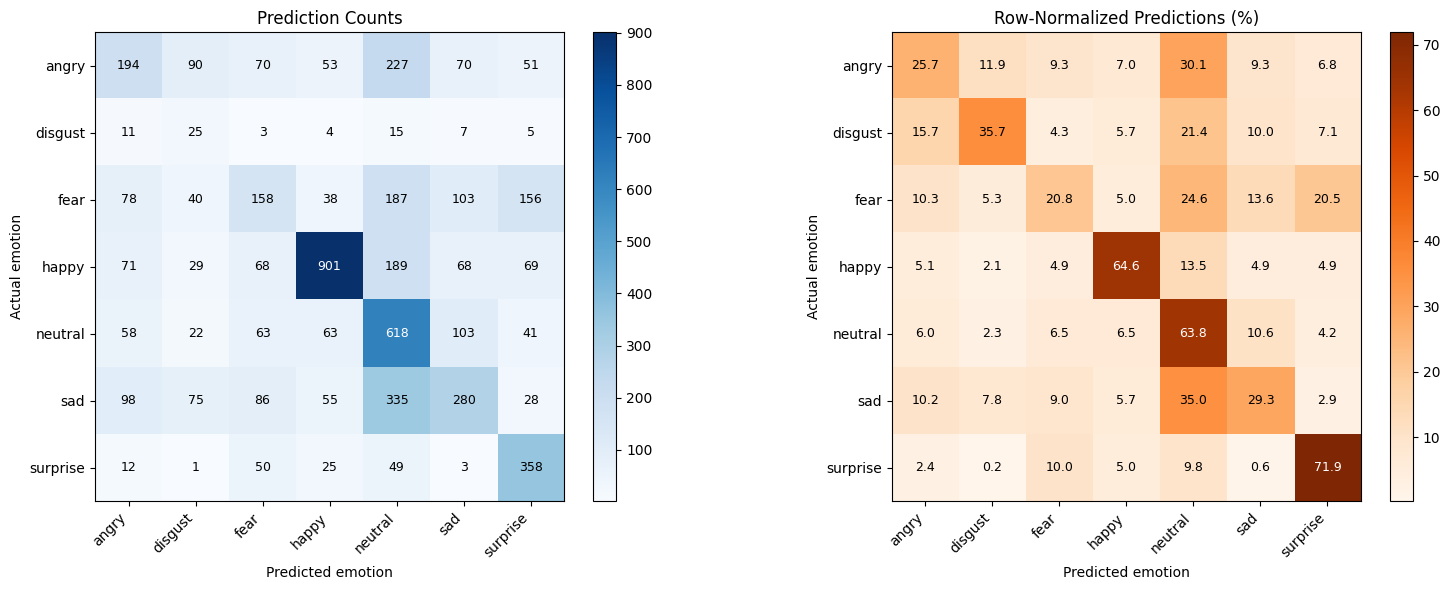

Five largest misclassification patterns:


,Actual,Predicted,Count
0,sad,neutral,335
1,angry,neutral,227
2,happy,neutral,189
3,fear,neutral,187
4,fear,surprise,156


In [ ]:
custom_confusion_matrix = confusion_matrix(
    validation_true_labels,
    validation_predictions,
    labels=label_indices
)

row_totals = custom_confusion_matrix.sum(
    axis=1,
    keepdims=True
)

custom_confusion_normalized = np.divide(
    custom_confusion_matrix,
    row_totals,
    out=np.zeros_like(
        custom_confusion_matrix,
        dtype=float
    ),
    where=row_totals != 0
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

matrix_settings = [
    (
        custom_confusion_matrix,
        "Prediction Counts",
        "Blues",
        "d"
    ),
    (
        custom_confusion_normalized * 100,
        "Row-Normalized Predictions (%)",
        "Oranges",
        ".1f"
    ),
]

for ax, (
    matrix,
    title,
    colour_map,
    number_format
) in zip(axes, matrix_settings):

    matrix_image = ax.imshow(
        matrix,
        cmap=colour_map
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted emotion")
    ax.set_ylabel("Actual emotion")

    ax.set_xticks(
        range(number_of_classes)
    )
    ax.set_yticks(
        range(number_of_classes)
    )

    ax.set_xticklabels(
        EMOTION_CLASSES,
        rotation=45,
        ha="right"
    )
    ax.set_yticklabels(
        EMOTION_CLASSES
    )

    threshold = matrix.max() / 2

    for row_index in range(number_of_classes):
        for column_index in range(
            number_of_classes
        ):
            value = matrix[
                row_index,
                column_index
            ]

            ax.text(
                column_index,
                row_index,
                format(value, number_format),
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
                fontsize=9
            )

    fig.colorbar(
        matrix_image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()

fig.savefig(
    RESULTS_DIR
    / "custom_cnn_validation_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# List the five largest off-diagonal confusion counts.
confusion_records = []

for actual_index in label_indices:
    for predicted_index in label_indices:
        if actual_index != predicted_index:
            confusion_records.append({
                "Actual": index_to_label[actual_index],
                "Predicted": index_to_label[predicted_index],
                "Count": int(
                    custom_confusion_matrix[
                        actual_index,
                        predicted_index
                    ]
                )
            })

largest_confusions = (
    pd.DataFrame(confusion_records)
    .sort_values(
        "Count",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

print("Five largest misclassification patterns:")
display(largest_confusions)

### Model 1 Validation Findings

The custom CNN achieved 46.90% validation accuracy, 40.45% macro
F1-score, and 46.59% weighted F1-score. The lower macro F1 indicates
that performance is weaker when every emotion class receives equal
importance.

The largest error was sad predicted as neutral in 335 images. Other
common errors were angry predicted as neutral (227), happy predicted
as neutral (189), fear predicted as neutral (187), and fear predicted
as surprise (156). The model therefore shows a tendency to over-predict
neutral for several difficult classes. Surprise achieved relatively
strong recall, while minority-class performance remains a limitation.
Model 1 provides a useful baseline for comparison with transfer learning.

### Transfer-Learning Input Pipeline

MobileNetV2 was pretrained on RGB images, so each grayscale facial image
is decoded into three identical colour channels and resized to 96 × 96
pixels. Pixel values remain normalized between 0 and 1. The model later
transforms this range to the -1 to 1 range expected by MobileNetV2.
The same train, validation, and test records are retained for a fair
comparison with the custom CNN.

In [ ]:
TRANSFER_IMAGE_SIZE = (96, 96)
TRANSFER_BATCH_SIZE = 64

def load_transfer_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_jpeg(
        image_bytes,
        channels=3
    )

    image = tf.image.resize(
        image,
        TRANSFER_IMAGE_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label


def create_transfer_dataset(
    dataframe,
    training=False
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_path"].to_numpy(),
            dataframe["label"].to_numpy()
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_transfer_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        TRANSFER_BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


transfer_train_dataset = create_transfer_dataset(
    train_df,
    training=True
)

transfer_validation_dataset = create_transfer_dataset(
    validation_df
)

transfer_test_dataset = create_transfer_dataset(
    test_df
)

transfer_sample_images, transfer_sample_labels = next(
    iter(transfer_train_dataset)
)

print(
    "Transfer image batch shape:",
    transfer_sample_images.shape
)
print(
    "Transfer label batch shape:",
    transfer_sample_labels.shape
)
print(
    "Transfer image dtype:",
    transfer_sample_images.dtype
)
print(
    "Transfer pixel range:",
    float(tf.reduce_min(transfer_sample_images)),
    "to",
    float(tf.reduce_max(transfer_sample_images))
)

assert transfer_sample_images.shape[1:] == (
    96, 96, 3
)
assert transfer_sample_images.dtype == tf.float32
assert float(
    tf.reduce_min(transfer_sample_images)
) >= 0.0
assert float(
    tf.reduce_max(transfer_sample_images)
) <= 1.0

Transfer image batch shape: (64, 96, 96, 3)
Transfer label batch shape: (64,)
Transfer image dtype: <dtype: 'float32'>
Transfer pixel range: 0.0 to 1.0


### ML Model 2: Frozen MobileNetV2 Transfer Learning

MobileNetV2 is initialized with features learned from the ImageNet
dataset. Its convolutional base is frozen so that only the new
seven-class classification head is trained. This tests whether general
pretrained visual features can improve emotion recognition with limited
training cost. Batch-normalization layers in the pretrained base remain
in inference mode.

In [ ]:
keras.utils.set_random_seed(RANDOM_SEED)

transfer_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=RANDOM_SEED
        ),
        layers.RandomRotation(
            0.05,
            fill_mode="reflect",
            seed=RANDOM_SEED
        ),
        layers.RandomTranslation(
            0.05,
            0.05,
            fill_mode="reflect",
            seed=RANDOM_SEED
        ),
        layers.RandomZoom(
            0.10,
            0.10,
            fill_mode="reflect",
            seed=RANDOM_SEED
        ),
        layers.RandomContrast(
            0.10,
            seed=RANDOM_SEED
        ),
    ],
    name="transfer_augmentation"
)

mobilenet_base = (
    keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )
)

mobilenet_base.trainable = False

transfer_inputs = keras.Input(
    shape=(96, 96, 3),
    name="rgb_face"
)

x = transfer_augmentation(
    transfer_inputs
)

# Convert normalized 0–1 pixels to MobileNetV2's -1 to 1 range.
x = layers.Rescaling(
    scale=2.0,
    offset=-1.0,
    name="mobilenet_preprocessing"
)(x)

x = mobilenet_base(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.40,
    name="transfer_dropout"
)(x)

transfer_outputs = layers.Dense(
    number_of_classes,
    activation="softmax",
    name="emotion_probabilities"
)(x)

frozen_transfer_model = keras.Model(
    transfer_inputs,
    transfer_outputs,
    name="DeepFER_Frozen_MobileNetV2"
)

frozen_transfer_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

frozen_transfer_model.summary()

print(
    "MobileNetV2 base trainable:",
    mobilenet_base.trainable
)
print(
    "Trainable parameters:",
    sum(
        np.prod(variable.shape)
        for variable
        in frozen_transfer_model.trainable_weights
    )
)

assert frozen_transfer_model.output_shape == (
    None,
    7
)
assert mobilenet_base.trainable is False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "DeepFER_Frozen_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_face (InputLayer)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_augmentation           │ (None, 96, 96, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 96, 96, 3)      │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dropout (Dropout)      │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_probabilities (Dense)   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 base trainable: False
Trainable parameters: 8967


#### How does transfer learning help?

The pretrained base already contains general visual filters for edges,
textures, shapes, and object parts. Freezing it reduces the number of
parameters that must be learned from the emotion dataset, shortens
training time, and provides a stronger initialization than learning
every feature from scratch.

#### Why was MobileNetV2 selected?

MobileNetV2 offers a useful balance between feature quality and
computational efficiency. Its relatively small size also makes it
suitable for future real-time or edge-device deployment.

### Frozen Transfer-Learning Training

Only the newly added classification layer is optimized during this
stage. The same class weights and validation split used for Model 1 are
retained so that performance comparisons remain fair. Validation loss
selects the best checkpoint, while the final test set remains untouched.

In [ ]:
FROZEN_TRANSFER_PATH = (
    MODELS_DIR
    / "mobilenetv2_frozen_best.keras"
)

frozen_transfer_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(FROZEN_TRANSFER_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        filename=str(
            RESULTS_DIR
            / "mobilenetv2_frozen_training_log.csv"
        ),
        append=False
    ),

    keras.callbacks.TerminateOnNaN()
]

FROZEN_TRANSFER_EPOCHS = 15

frozen_transfer_history = (
    frozen_transfer_model.fit(
        transfer_train_dataset,
        validation_data=transfer_validation_dataset,
        epochs=FROZEN_TRANSFER_EPOCHS,
        class_weight=class_weight,
        callbacks=frozen_transfer_callbacks,
        verbose=1
    )
)

frozen_completed_epochs = len(
    frozen_transfer_history.history["loss"]
)

frozen_best_epoch_index = int(
    np.argmin(
        frozen_transfer_history.history[
            "val_loss"
        ]
    )
)

frozen_best_epoch_number = (
    frozen_best_epoch_index + 1
)

print("\nFrozen transfer training completed.")
print(
    "Epochs completed:",
    frozen_completed_epochs
)
print(
    "Best epoch:",
    frozen_best_epoch_number
)
print(
    "Best validation loss:",
    f"{frozen_transfer_history.history['val_loss'][frozen_best_epoch_index]:.4f}"
)
print(
    "Validation accuracy at best epoch:",
    f"{frozen_transfer_history.history['val_accuracy'][frozen_best_epoch_index]:.4f}"
)
print(
    "Best model saved to:",
    FROZEN_TRANSFER_PATH
)

assert FROZEN_TRANSFER_PATH.is_file()
assert np.isfinite(
    frozen_transfer_history.history[
        "val_loss"
    ]
).all()

Epoch 1/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2158 - loss: 2.4232
Epoch 1: val_loss improved from None to 1.70200, saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_frozen_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_frozen_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.2571 - loss: 2.1537 - val_accuracy: 0.3567 - val_loss: 1.7020 - learning_rate: 0.0010
Epoch 2/15
337/338 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3132 - loss: 1.8399
Epoch 2: val_loss improved from 1.70200 to 1.49508, saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_frozen_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_frozen_best.keras
338/338 ━━━━━━━━

### Frozen MobileNetV2 Training Curves

The frozen transfer-learning model reached its lowest validation loss
at epoch 2. Later validation performance deteriorated even as training
accuracy improved, indicating that training the classification head
further did not improve generalization. Early stopping restored the
best epoch.

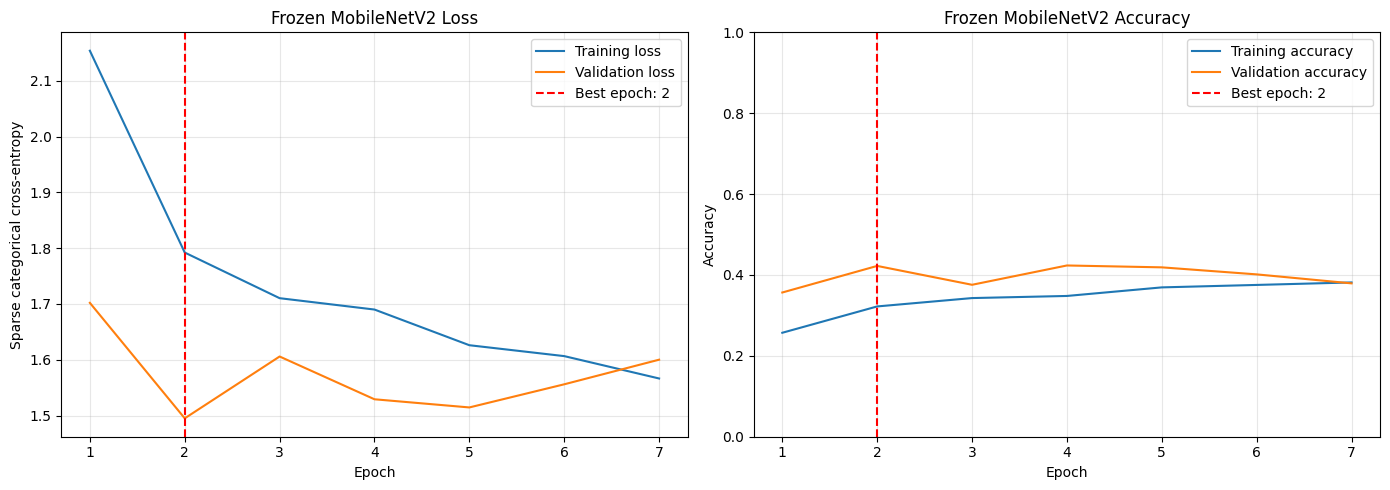

Selected epoch: 2
Training accuracy: 0.3222
Validation accuracy: 0.4224


In [ ]:
frozen_history_df = pd.DataFrame(
    frozen_transfer_history.history
)

frozen_history_df.index = np.arange(
    1,
    len(frozen_history_df) + 1
)

frozen_history_df.index.name = "epoch"

frozen_history_df.to_csv(
    RESULTS_DIR
    / "mobilenetv2_frozen_history.csv"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    frozen_history_df.index,
    frozen_history_df["loss"],
    label="Training loss"
)
axes[0].plot(
    frozen_history_df.index,
    frozen_history_df["val_loss"],
    label="Validation loss"
)
axes[0].axvline(
    frozen_best_epoch_number,
    color="red",
    linestyle="--",
    label=f"Best epoch: {frozen_best_epoch_number}"
)
axes[0].set_title("Frozen MobileNetV2 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    frozen_history_df.index,
    frozen_history_df["accuracy"],
    label="Training accuracy"
)
axes[1].plot(
    frozen_history_df.index,
    frozen_history_df["val_accuracy"],
    label="Validation accuracy"
)
axes[1].axvline(
    frozen_best_epoch_number,
    color="red",
    linestyle="--",
    label=f"Best epoch: {frozen_best_epoch_number}"
)
axes[1].set_title("Frozen MobileNetV2 Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR
    / "mobilenetv2_frozen_learning_curves.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Selected epoch:",
    frozen_best_epoch_number
)
print(
    "Training accuracy:",
    f"{frozen_history_df.loc[frozen_best_epoch_number, 'accuracy']:.4f}"
)
print(
    "Validation accuracy:",
    f"{frozen_history_df.loc[frozen_best_epoch_number, 'val_accuracy']:.4f}"
)

### Model 1 and Model 2 Validation Comparison

The frozen MobileNetV2 model is evaluated using the same validation set
and metrics as the custom CNN. Macro F1 is the primary comparison metric
because it gives every emotion class equal importance. The test set is
still not used.

85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4224 - loss: 1.4951
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step


,precision,recall,f1-score,support
angry,0.317,0.295,0.306,755.000
disgust,0.096,0.114,0.105,70.000
fear,0.304,0.239,0.268,760.000
happy,0.518,0.678,0.587,1395.000
neutral,0.379,0.440,0.407,968.000
sad,0.418,0.237,0.303,957.000
surprise,0.516,0.542,0.529,498.000
accuracy,0.422,0.422,0.422,0.422
macro avg,0.364,0.364,0.358,5403.000
weighted avg,0.411,0.422,0.409,5403.000


,Custom CNN,Frozen MobileNetV2
Accuracy,0.4690,0.4224
Macro precision,0.4139,0.3640
Macro recall,0.4454,0.3638
Macro F1,0.4045,0.3577
Weighted F1,0.4659,0.4087


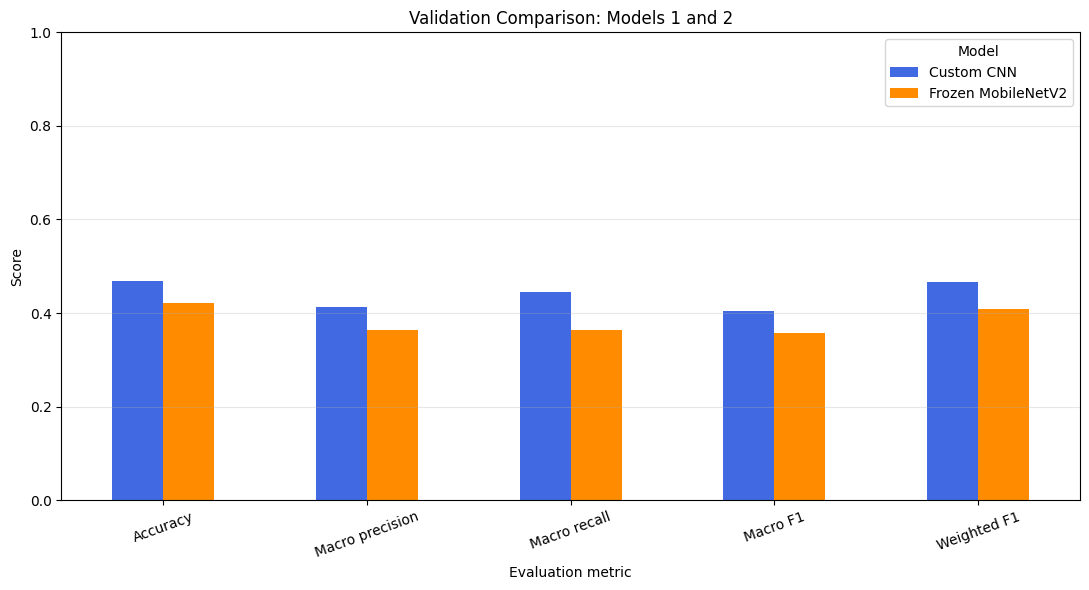

Frozen validation loss: 1.4951
Frozen validation accuracy: 0.4224
Frozen macro F1: 0.3577


In [ ]:
best_frozen_transfer_model = (
    keras.models.load_model(
        str(FROZEN_TRANSFER_PATH)
    )
)

(
    frozen_validation_loss,
    frozen_validation_accuracy
) = best_frozen_transfer_model.evaluate(
    transfer_validation_dataset,
    verbose=1
)

frozen_validation_probabilities = (
    best_frozen_transfer_model.predict(
        transfer_validation_dataset,
        verbose=1
    )
)

frozen_validation_predictions = np.argmax(
    frozen_validation_probabilities,
    axis=1
)

frozen_report = classification_report(
    validation_true_labels,
    frozen_validation_predictions,
    labels=label_indices,
    target_names=EMOTION_CLASSES,
    output_dict=True,
    zero_division=0
)

frozen_metrics_df = (
    pd.DataFrame(frozen_report)
    .transpose()
)

display(frozen_metrics_df.round(3))

frozen_metrics_df.to_csv(
    RESULTS_DIR
    / "mobilenetv2_frozen_validation_report.csv"
)

model_comparison_df = pd.DataFrame(
    {
        "Custom CNN": {
            "Accuracy": validation_accuracy,
            "Macro precision": custom_metrics_df.loc[
                "macro avg", "precision"
            ],
            "Macro recall": custom_metrics_df.loc[
                "macro avg", "recall"
            ],
            "Macro F1": custom_metrics_df.loc[
                "macro avg", "f1-score"
            ],
            "Weighted F1": custom_metrics_df.loc[
                "weighted avg", "f1-score"
            ],
        },
        "Frozen MobileNetV2": {
            "Accuracy": frozen_validation_accuracy,
            "Macro precision": frozen_metrics_df.loc[
                "macro avg", "precision"
            ],
            "Macro recall": frozen_metrics_df.loc[
                "macro avg", "recall"
            ],
            "Macro F1": frozen_metrics_df.loc[
                "macro avg", "f1-score"
            ],
            "Weighted F1": frozen_metrics_df.loc[
                "weighted avg", "f1-score"
            ],
        },
    }
)

display(model_comparison_df.round(4))

model_comparison_df.plot(
    kind="bar",
    figsize=(11, 6),
    color=["royalblue", "darkorange"]
)

plt.title("Validation Comparison: Models 1 and 2")
plt.xlabel("Evaluation metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "model_1_vs_model_2_validation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Frozen validation loss:",
    f"{frozen_validation_loss:.4f}"
)
print(
    "Frozen validation accuracy:",
    f"{frozen_validation_accuracy:.4f}"
)
print(
    "Frozen macro F1:",
    f"{frozen_metrics_df.loc['macro avg', 'f1-score']:.4f}"
)

assert len(
    frozen_validation_predictions
) == len(validation_df)

#### Did transfer learning improve the result?

The completely frozen MobileNetV2 model achieved 42.24% validation
accuracy, compared with 46.90% for the custom CNN. Therefore, freezing
all pretrained convolutional layers did not improve overall validation
accuracy. This may occur because ImageNet features were learned from
colour object photographs, whereas this dataset contains small grayscale
facial-expression images. Fine-tuning selected upper layers will next
allow the pretrained features to adapt to this domain.

### ML Model 3: Fine-Tuned MobileNetV2

Model 3 starts from the best frozen MobileNetV2 checkpoint. The final
30 layers of the pretrained base are made trainable, while earlier
layers remain frozen. Batch-normalization layers remain frozen to avoid
destabilizing their pretrained statistics. A small learning rate is used
so that useful pretrained features are adjusted gradually rather than
overwritten.

In [ ]:
fine_tuned_model = keras.models.load_model(
    str(FROZEN_TRANSFER_PATH)
)

fine_tune_base = fine_tuned_model.get_layer(
    mobilenet_base.name
)

fine_tune_base.trainable = True

# Freeze the earlier general feature layers.
for layer in fine_tune_base.layers[:-30]:
    layer.trainable = False

# Keep batch-normalization statistics fixed.
for layer in fine_tune_base.layers[-30:]:
    if isinstance(
        layer,
        layers.BatchNormalization
    ):
        layer.trainable = False

fine_tuned_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

FINE_TUNED_PATH = (
    MODELS_DIR
    / "mobilenetv2_fine_tuned_best.keras"
)

fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(FINE_TUNED_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        filename=str(
            RESULTS_DIR
            / "mobilenetv2_fine_tuning_log.csv"
        ),
        append=False
    ),

    keras.callbacks.TerminateOnNaN()
]

trainable_parameter_count = sum(
    np.prod(variable.shape)
    for variable
    in fine_tuned_model.trainable_weights
)

trainable_base_layers = sum(
    layer.trainable
    for layer in fine_tune_base.layers
)

print(
    "Trainable base layers:",
    trainable_base_layers
)
print(
    "Total trainable parameters:",
    trainable_parameter_count
)
print("Fine-tuning learning rate: 0.00001")

FINE_TUNE_EPOCHS = 15

fine_tune_history = fine_tuned_model.fit(
    transfer_train_dataset,
    validation_data=transfer_validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=fine_tune_callbacks,
    verbose=1
)

fine_tune_best_index = int(
    np.argmin(
        fine_tune_history.history["val_loss"]
    )
)

fine_tune_best_epoch = (
    fine_tune_best_index + 1
)

print("\nFine-tuning completed.")
print(
    "Epochs completed:",
    len(fine_tune_history.history["loss"])
)
print(
    "Best epoch:",
    fine_tune_best_epoch
)
print(
    "Best validation loss:",
    f"{fine_tune_history.history['val_loss'][fine_tune_best_index]:.4f}"
)
print(
    "Validation accuracy at best epoch:",
    f"{fine_tune_history.history['val_accuracy'][fine_tune_best_index]:.4f}"
)
print(
    "Best model saved to:",
    FINE_TUNED_PATH
)

assert FINE_TUNED_PATH.is_file()

Trainable base layers: 19
Total trainable parameters: 1519687
Fine-tuning learning rate: 0.00001
Epoch 1/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3505 - loss: 1.6863
Epoch 1: val_loss improved from None to 1.56943, saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_fine_tuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_fine_tuned_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.3561 - loss: 1.6405 - val_accuracy: 0.3913 - val_loss: 1.5694 - learning_rate: 1.0000e-05
Epoch 2/15
337/338 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3818 - loss: 1.5685
Epoch 2: val_loss improved from 1.56943 to 1.46839, saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_fine_tuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDr

### Continued Fine-Tuning

The lowest validation loss occurred at the final scheduled epoch,
indicating that fine-tuning had not yet clearly converged. Training is
therefore continued for up to 10 additional epochs using the reduced
learning rate. A separate checkpoint is used so the earlier best model
cannot be overwritten by a worse continuation.

In [ ]:
CONTINUED_FINE_TUNED_PATH = (
    MODELS_DIR
    / "mobilenetv2_fine_tuned_continued_best.keras"
)

continued_fine_tune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(
            CONTINUED_FINE_TUNED_PATH
        ),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        filename=str(
            RESULTS_DIR
            / "mobilenetv2_continued_fine_tuning_log.csv"
        ),
        append=False
    ),

    keras.callbacks.TerminateOnNaN()
]

INITIAL_FINE_TUNE_EPOCHS = len(
    fine_tune_history.history["loss"]
)

TOTAL_FINE_TUNE_EPOCHS = (
    INITIAL_FINE_TUNE_EPOCHS + 10
)

print(
    "Current learning rate:",
    float(
        fine_tuned_model.optimizer.learning_rate
    )
)

continued_fine_tune_history = (
    fine_tuned_model.fit(
        transfer_train_dataset,
        validation_data=transfer_validation_dataset,
        initial_epoch=INITIAL_FINE_TUNE_EPOCHS,
        epochs=TOTAL_FINE_TUNE_EPOCHS,
        class_weight=class_weight,
        callbacks=continued_fine_tune_callbacks,
        verbose=1
    )
)

print("\nContinued fine-tuning completed.")
print(
    "Additional epochs completed:",
    len(
        continued_fine_tune_history.history[
            "loss"
        ]
    )
)
print(
    "Best continued validation loss:",
    f"{min(continued_fine_tune_history.history['val_loss']):.4f}"
)
print(
    "Continued checkpoint:",
    CONTINUED_FINE_TUNED_PATH
)

assert CONTINUED_FINE_TUNED_PATH.is_file()

Current learning rate: 2.499999936844688e-06
Epoch 16/25
337/338 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4877 - loss: 1.2780
Epoch 16: val_loss improved from None to 1.30810, saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_fine_tuned_continued_best.keras

Epoch 16: finished saving model to /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_fine_tuned_continued_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.4816 - loss: 1.2784 - val_accuracy: 0.4973 - val_loss: 1.3081 - learning_rate: 2.5000e-06
Epoch 17/25
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4918 - loss: 1.2768
Epoch 17: val_loss did not improve from 1.30810
338/338 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.4900 - loss: 1.2629 - val_accuracy: 0.4908 - val_loss: 1.3233 - learning_rate: 2.5000e-06
Epoch 18/25
337/338 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4870 - 

### Fine-Tuned Model Learning Curves and Validation Evaluation

The initial and continued fine-tuning histories are combined. The
checkpoint with the lower validation loss is selected, ensuring that
continued training cannot replace the earlier model unless it actually
improves validation performance. Detailed class metrics are then
calculated using the selected checkpoint.

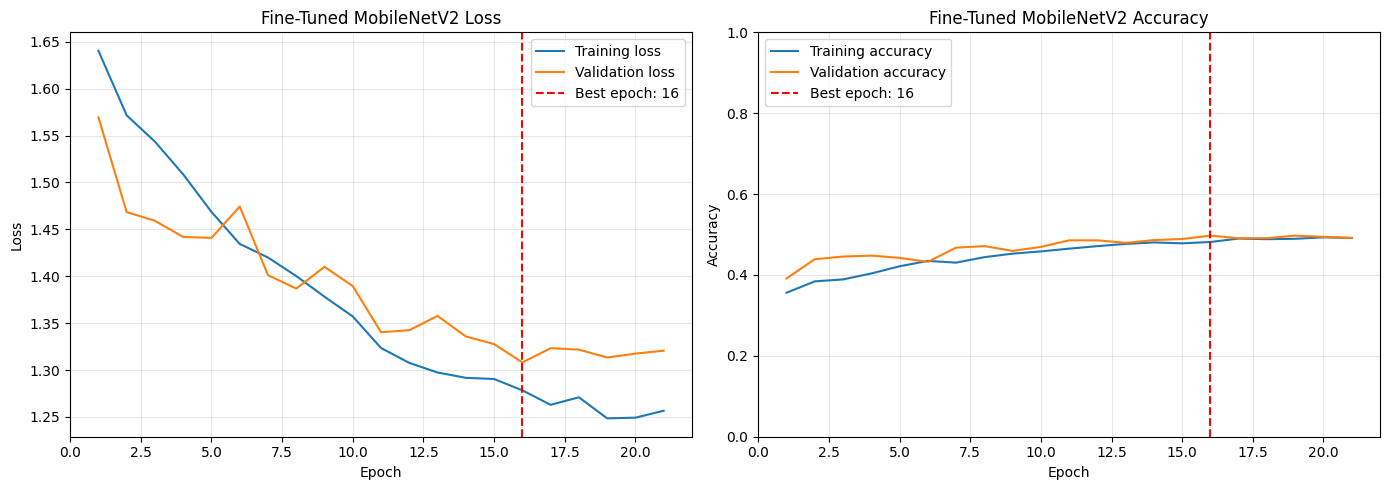

85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4973 - loss: 1.3081
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step


,precision,recall,f1-score,support
angry,0.352,0.503,0.414,755.000
disgust,0.203,0.343,0.255,70.000
fear,0.411,0.293,0.342,760.000
happy,0.721,0.695,0.708,1395.000
neutral,0.441,0.529,0.481,968.000
sad,0.447,0.273,0.339,957.000
surprise,0.555,0.639,0.594,498.000
accuracy,0.497,0.497,0.497,0.497
macro avg,0.447,0.468,0.448,5403.000
weighted avg,0.505,0.497,0.493,5403.000


Selected checkpoint: /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_fine_tuned_continued_best.keras
Best fine-tuning epoch: 16
Validation loss: 1.3081
Validation accuracy: 0.4973
Macro F1: 0.4476
Weighted F1: 0.4929


In [ ]:
initial_fine_tune_df = pd.DataFrame(
    fine_tune_history.history
)

initial_fine_tune_df.index = np.arange(
    1,
    len(initial_fine_tune_df) + 1
)

continued_fine_tune_df = pd.DataFrame(
    continued_fine_tune_history.history
)

continued_fine_tune_df.index = np.arange(
    len(initial_fine_tune_df) + 1,
    len(initial_fine_tune_df)
    + len(continued_fine_tune_df) + 1
)

combined_fine_tune_df = pd.concat(
    [
        initial_fine_tune_df,
        continued_fine_tune_df
    ]
)

combined_fine_tune_df.index.name = "epoch"

combined_fine_tune_df.to_csv(
    RESULTS_DIR
    / "mobilenetv2_complete_fine_tuning_history.csv"
)

global_best_fine_tune_epoch = int(
    combined_fine_tune_df[
        "val_loss"
    ].idxmin()
)

if (
    global_best_fine_tune_epoch
    <= len(initial_fine_tune_df)
):
    SELECTED_FINE_TUNED_PATH = (
        FINE_TUNED_PATH
    )
else:
    SELECTED_FINE_TUNED_PATH = (
        CONTINUED_FINE_TUNED_PATH
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    combined_fine_tune_df.index,
    combined_fine_tune_df["loss"],
    label="Training loss"
)
axes[0].plot(
    combined_fine_tune_df.index,
    combined_fine_tune_df["val_loss"],
    label="Validation loss"
)
axes[0].axvline(
    global_best_fine_tune_epoch,
    color="red",
    linestyle="--",
    label=(
        f"Best epoch: "
        f"{global_best_fine_tune_epoch}"
    )
)
axes[0].set_title("Fine-Tuned MobileNetV2 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    combined_fine_tune_df.index,
    combined_fine_tune_df["accuracy"],
    label="Training accuracy"
)
axes[1].plot(
    combined_fine_tune_df.index,
    combined_fine_tune_df[
        "val_accuracy"
    ],
    label="Validation accuracy"
)
axes[1].axvline(
    global_best_fine_tune_epoch,
    color="red",
    linestyle="--",
    label=(
        f"Best epoch: "
        f"{global_best_fine_tune_epoch}"
    )
)
axes[1].set_title(
    "Fine-Tuned MobileNetV2 Accuracy"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR
    / "mobilenetv2_fine_tuning_curves.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

best_fine_tuned_model = (
    keras.models.load_model(
        str(SELECTED_FINE_TUNED_PATH)
    )
)

(
    fine_validation_loss,
    fine_validation_accuracy
) = best_fine_tuned_model.evaluate(
    transfer_validation_dataset,
    verbose=1
)

fine_validation_probabilities = (
    best_fine_tuned_model.predict(
        transfer_validation_dataset,
        verbose=1
    )
)

fine_validation_predictions = np.argmax(
    fine_validation_probabilities,
    axis=1
)

fine_report = classification_report(
    validation_true_labels,
    fine_validation_predictions,
    labels=label_indices,
    target_names=EMOTION_CLASSES,
    output_dict=True,
    zero_division=0
)

fine_metrics_df = pd.DataFrame(
    fine_report
).transpose()

display(fine_metrics_df.round(3))

fine_metrics_df.to_csv(
    RESULTS_DIR
    / "mobilenetv2_fine_tuned_validation_report.csv"
)

print(
    "Selected checkpoint:",
    SELECTED_FINE_TUNED_PATH
)
print(
    "Best fine-tuning epoch:",
    global_best_fine_tune_epoch
)
print(
    "Validation loss:",
    f"{fine_validation_loss:.4f}"
)
print(
    "Validation accuracy:",
    f"{fine_validation_accuracy:.4f}"
)
print(
    "Macro F1:",
    f"{fine_metrics_df.loc['macro avg', 'f1-score']:.4f}"
)
print(
    "Weighted F1:",
    f"{fine_metrics_df.loc['weighted avg', 'f1-score']:.4f}"
)

### Final Validation Comparison and Model Selection

All three models are compared on the same validation set. Macro F1 is
used as the primary selection metric because it gives equal importance
to every emotion despite severe class imbalance. The held-out test set
has not influenced this selection.

,Custom CNN,Frozen MobileNetV2,Fine-tuned MobileNetV2
Validation loss,1.3859,1.4951,1.3081
Accuracy,0.4690,0.4224,0.4973
Macro precision,0.4139,0.3640,0.4471
Macro recall,0.4454,0.3638,0.4678
Macro F1,0.4045,0.3577,0.4476
Weighted F1,0.4659,0.4087,0.4929


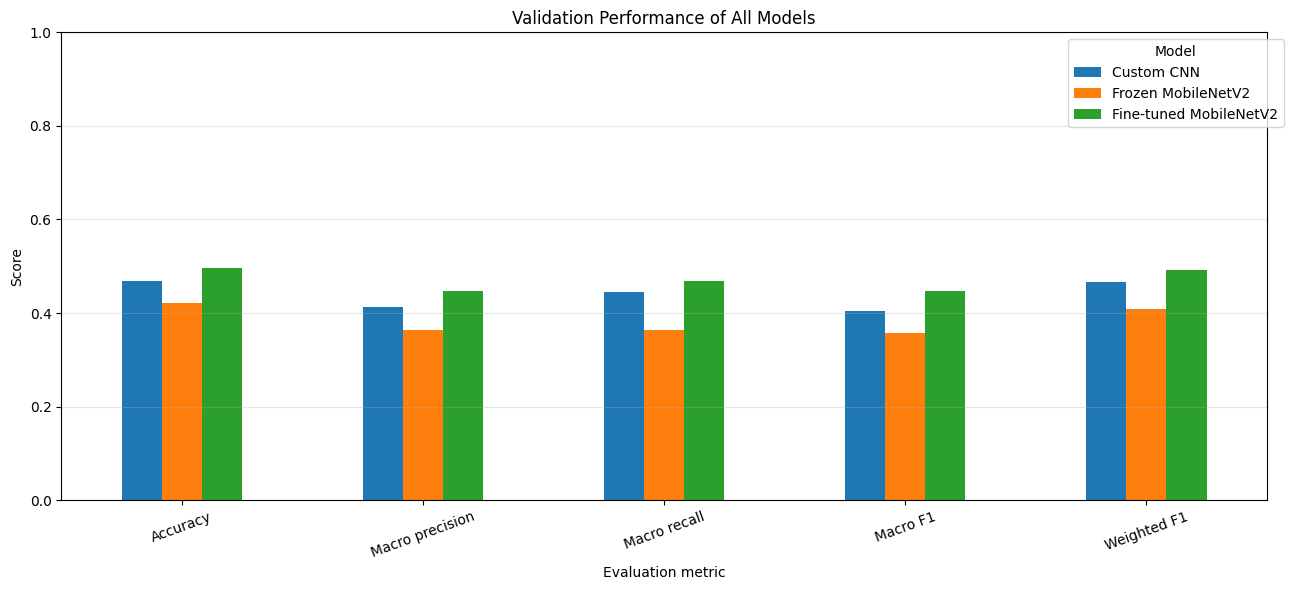

Selected final model: Fine-tuned MobileNetV2
Selection metric: Macro F1
Validation macro F1: 0.4476
Model path: /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/mobilenetv2_fine_tuned_continued_best.keras


In [ ]:
all_models_comparison = pd.DataFrame(
    {
        "Custom CNN": {
            "Validation loss":
                validation_loss,
            "Accuracy":
                validation_accuracy,
            "Macro precision":
                custom_metrics_df.loc[
                    "macro avg", "precision"
                ],
            "Macro recall":
                custom_metrics_df.loc[
                    "macro avg", "recall"
                ],
            "Macro F1":
                custom_metrics_df.loc[
                    "macro avg", "f1-score"
                ],
            "Weighted F1":
                custom_metrics_df.loc[
                    "weighted avg", "f1-score"
                ],
        },

        "Frozen MobileNetV2": {
            "Validation loss":
                frozen_validation_loss,
            "Accuracy":
                frozen_validation_accuracy,
            "Macro precision":
                frozen_metrics_df.loc[
                    "macro avg", "precision"
                ],
            "Macro recall":
                frozen_metrics_df.loc[
                    "macro avg", "recall"
                ],
            "Macro F1":
                frozen_metrics_df.loc[
                    "macro avg", "f1-score"
                ],
            "Weighted F1":
                frozen_metrics_df.loc[
                    "weighted avg", "f1-score"
                ],
        },

        "Fine-tuned MobileNetV2": {
            "Validation loss":
                fine_validation_loss,
            "Accuracy":
                fine_validation_accuracy,
            "Macro precision":
                fine_metrics_df.loc[
                    "macro avg", "precision"
                ],
            "Macro recall":
                fine_metrics_df.loc[
                    "macro avg", "recall"
                ],
            "Macro F1":
                fine_metrics_df.loc[
                    "macro avg", "f1-score"
                ],
            "Weighted F1":
                fine_metrics_df.loc[
                    "weighted avg", "f1-score"
                ],
        },
    }
)

display(all_models_comparison.round(4))

all_models_comparison.to_csv(
    RESULTS_DIR
    / "all_models_validation_comparison.csv"
)

comparison_metrics = [
    "Accuracy",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "Weighted F1"
]

all_models_comparison.loc[
    comparison_metrics
].plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title(
    "Validation Performance of All Models"
)
plt.xlabel("Evaluation metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "all_models_validation_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

FINAL_MODEL_NAME = (
    all_models_comparison
    .loc["Macro F1"]
    .idxmax()
)

model_registry = {
    "Custom CNN": {
        "path": CUSTOM_CNN_PATH,
        "test_dataset": test_dataset,
    },
    "Frozen MobileNetV2": {
        "path": FROZEN_TRANSFER_PATH,
        "test_dataset":
            transfer_test_dataset,
    },
    "Fine-tuned MobileNetV2": {
        "path":
            SELECTED_FINE_TUNED_PATH,
        "test_dataset":
            transfer_test_dataset,
    },
}

FINAL_MODEL_PATH = model_registry[
    FINAL_MODEL_NAME
]["path"]

FINAL_TEST_DATASET = model_registry[
    FINAL_MODEL_NAME
]["test_dataset"]

print(
    "Selected final model:",
    FINAL_MODEL_NAME
)
print(
    "Selection metric: Macro F1"
)
print(
    "Validation macro F1:",
    f"{all_models_comparison.loc['Macro F1', FINAL_MODEL_NAME]:.4f}"
)
print(
    "Model path:",
    FINAL_MODEL_PATH
)

assert FINAL_MODEL_PATH.is_file()

### Final Model Selection Findings

Fine-tuned MobileNetV2 was selected because it achieved the highest
validation macro F1-score of 44.76%. It also achieved 49.73% validation
accuracy and 49.29% weighted F1-score. Fine-tuning improved the frozen
model by adapting higher-level pretrained features to grayscale facial
expressions.

Happy achieved the strongest class F1-score at 70.8%, followed by
surprise at 59.4%. Disgust remained the weakest class with an F1-score
of 25.5%, largely because it contained only 281 training images. Fear
and sad also remained difficult classes. These findings show that the
model's performance varies substantially across emotions.

### Final Model Evaluation on the Held-Out Test Set

After selecting the model using validation macro F1, the fine-tuned
MobileNetV2 is evaluated once on the untouched test set. This provides
the final estimate of generalization. Test results were not used for
model architecture, hyperparameter, epoch, or checkpoint selection.

In [ ]:
final_model = keras.models.load_model(
    str(FINAL_MODEL_PATH)
)

(
    final_test_loss,
    final_test_accuracy
) = final_model.evaluate(
    FINAL_TEST_DATASET,
    verbose=1
)

final_test_probabilities = final_model.predict(
    FINAL_TEST_DATASET,
    verbose=1
)

final_test_predictions = np.argmax(
    final_test_probabilities,
    axis=1
)

final_test_true_labels = (
    test_df["label"].to_numpy()
)

assert len(final_test_predictions) == len(test_df)
assert final_test_probabilities.shape == (
    len(test_df),
    number_of_classes
)
assert np.allclose(
    final_test_probabilities.sum(axis=1),
    1.0,
    atol=1e-5
)

final_test_report = classification_report(
    final_test_true_labels,
    final_test_predictions,
    labels=label_indices,
    target_names=EMOTION_CLASSES,
    output_dict=True,
    zero_division=0
)

final_test_metrics_df = pd.DataFrame(
    final_test_report
).transpose()

display(final_test_metrics_df.round(3))

final_test_metrics_df.to_csv(
    RESULTS_DIR
    / "final_model_test_classification_report.csv"
)

print("Final model:", FINAL_MODEL_NAME)
print("Test images:", len(test_df))
print(f"Test loss: {final_test_loss:.4f}")
print(
    "Test accuracy:",
    f"{final_test_accuracy:.4f}",
    f"({final_test_accuracy * 100:.2f}%)"
)
print(
    "Test macro precision:",
    f"{final_test_metrics_df.loc['macro avg', 'precision']:.4f}"
)
print(
    "Test macro recall:",
    f"{final_test_metrics_df.loc['macro avg', 'recall']:.4f}"
)
print(
    "Test macro F1:",
    f"{final_test_metrics_df.loc['macro avg', 'f1-score']:.4f}"
)
print(
    "Test weighted F1:",
    f"{final_test_metrics_df.loc['weighted avg', 'f1-score']:.4f}"
)

109/109 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.5048 - loss: 1.3098
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step


,precision,recall,f1-score,support
angry,0.357,0.512,0.421,942.000
disgust,0.287,0.467,0.356,107.000
fear,0.378,0.279,0.321,1003.000
happy,0.720,0.690,0.704,1820.000
neutral,0.444,0.561,0.496,1209.000
sad,0.445,0.251,0.321,1125.000
surprise,0.613,0.644,0.628,759.000
accuracy,0.505,0.505,0.505,0.505
macro avg,0.464,0.486,0.464,6965.000
weighted avg,0.511,0.505,0.499,6965.000


Final model: Fine-tuned MobileNetV2
Test images: 6965
Test loss: 1.3098
Test accuracy: 0.5048 (50.48%)
Test macro precision: 0.4636
Test macro recall: 0.4862
Test macro F1: 0.4638
Test weighted F1: 0.4990


### Final Test Confusion Matrix and Error Analysis

The final confusion matrix identifies which emotions the selected model
recognizes correctly and which pairs it confuses. The row-normalized
matrix is especially important because every actual emotion totals
100%, allowing minority and majority classes to be compared fairly.

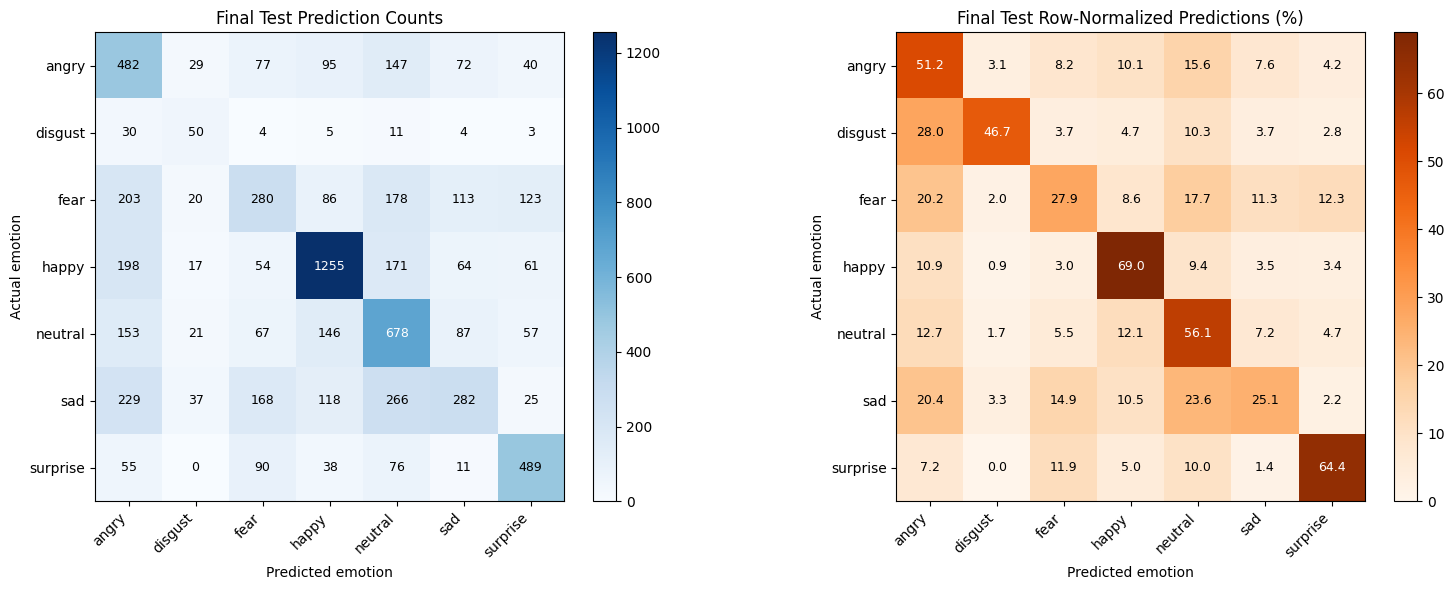

Ten largest final-test confusion patterns:


,Actual,Predicted,Count,Actual-class percentage
0,sad,neutral,266,23.64
1,sad,angry,229,20.36
2,fear,angry,203,20.24
3,happy,angry,198,10.88
4,fear,neutral,178,17.75
5,happy,neutral,171,9.40
6,sad,fear,168,14.93
7,neutral,angry,153,12.66
8,angry,neutral,147,15.61
9,neutral,happy,146,12.08


In [ ]:
final_test_confusion = confusion_matrix(
    final_test_true_labels,
    final_test_predictions,
    labels=label_indices
)

test_row_totals = final_test_confusion.sum(
    axis=1,
    keepdims=True
)

final_test_confusion_normalized = np.divide(
    final_test_confusion,
    test_row_totals,
    out=np.zeros_like(
        final_test_confusion,
        dtype=float
    ),
    where=test_row_totals != 0
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

test_matrix_settings = [
    (
        final_test_confusion,
        "Final Test Prediction Counts",
        "Blues",
        "d"
    ),
    (
        final_test_confusion_normalized * 100,
        "Final Test Row-Normalized Predictions (%)",
        "Oranges",
        ".1f"
    ),
]

for ax, (
    matrix,
    title,
    colour_map,
    number_format
) in zip(axes, test_matrix_settings):

    matrix_image = ax.imshow(
        matrix,
        cmap=colour_map
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted emotion")
    ax.set_ylabel("Actual emotion")

    ax.set_xticks(range(number_of_classes))
    ax.set_yticks(range(number_of_classes))

    ax.set_xticklabels(
        EMOTION_CLASSES,
        rotation=45,
        ha="right"
    )
    ax.set_yticklabels(EMOTION_CLASSES)

    threshold = matrix.max() / 2

    for row_index in range(number_of_classes):
        for column_index in range(
            number_of_classes
        ):
            value = matrix[
                row_index,
                column_index
            ]

            ax.text(
                column_index,
                row_index,
                format(value, number_format),
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
                fontsize=9
            )

    fig.colorbar(
        matrix_image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()

fig.savefig(
    RESULTS_DIR
    / "final_model_test_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

test_confusion_records = []

for actual_index in label_indices:
    for predicted_index in label_indices:
        if actual_index != predicted_index:
            test_confusion_records.append({
                "Actual":
                    index_to_label[actual_index],
                "Predicted":
                    index_to_label[predicted_index],
                "Count": int(
                    final_test_confusion[
                        actual_index,
                        predicted_index
                    ]
                ),
                "Actual-class percentage": (
                    final_test_confusion_normalized[
                        actual_index,
                        predicted_index
                    ] * 100
                )
            })

largest_test_confusions = (
    pd.DataFrame(test_confusion_records)
    .sort_values(
        "Count",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

print("Ten largest final-test confusion patterns:")
display(
    largest_test_confusions.round(2)
)

largest_test_confusions.to_csv(
    RESULTS_DIR
    / "final_model_largest_test_confusions.csv",
    index=False
)

### Final Test Findings

The selected fine-tuned MobileNetV2 achieved 50.48% test accuracy,
46.38% macro F1, and 49.90% weighted F1. Its test performance was close
to its validation performance, indicating reasonably consistent
generalization.

Happy achieved the strongest test F1-score at 70.4%, followed by
surprise at 62.8%. Fear and sad were the weakest at 32.1%. The largest
error was sad predicted as neutral in 266 cases. Sad was also frequently
predicted as angry, while fear was frequently confused with angry and
neutral.

The measured single-image latency was 165.08 milliseconds, corresponding
to approximately 6.06 images per second in the Colab pipeline. This is
suitable for image-based interaction but requires optimization for
smooth real-time video.

### Prediction Examples and Real-Time Inference Speed

Sample test predictions are displayed with the true emotion, predicted
emotion, and confidence. Green titles indicate correct predictions and
red titles indicate errors. We also measure single-image inference
latency after GPU warm-up to assess the model's potential for real-time
use. Timing depends on the current hardware and Colab environment.

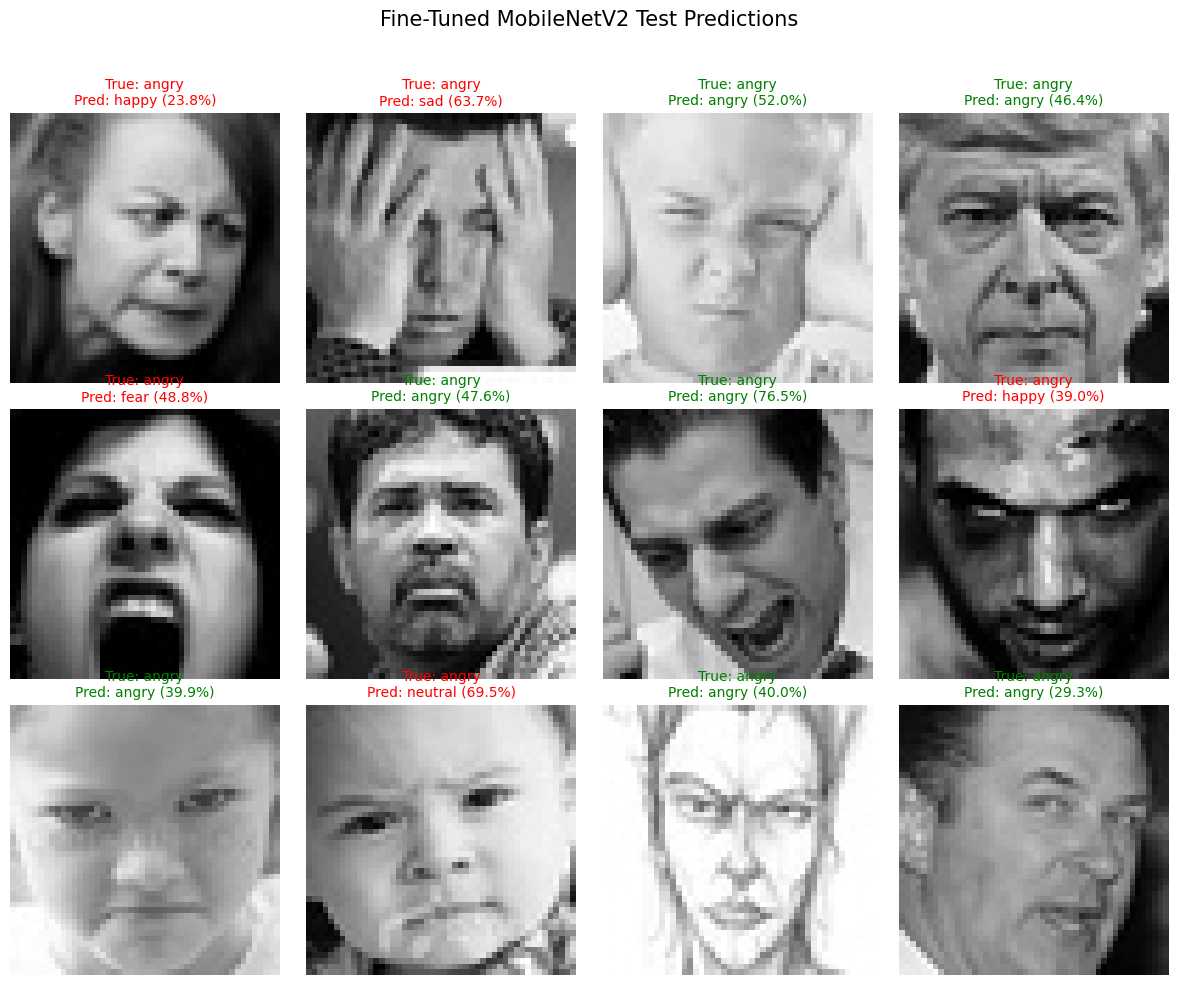

Images timed: 100
Average single-image latency: 165.08 ms
Approximate throughput: 6.06 images/second


In [ ]:
import time

# Display the first 12 held-out test predictions.
number_of_examples = 12

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 10)
)

for index, ax in enumerate(axes.flat):
    sample = test_df.iloc[index]

    true_label = sample["emotion"]

    predicted_index = int(
        final_test_predictions[index]
    )

    predicted_label = index_to_label[
        predicted_index
    ]

    confidence = float(
        final_test_probabilities[
            index,
            predicted_index
        ]
    )

    with Image.open(
        sample["image_path"]
    ) as image:
        ax.imshow(
            image.convert("L"),
            cmap="gray",
            vmin=0,
            vmax=255
        )

    title_colour = (
        "green"
        if predicted_label == true_label
        else "red"
    )

    ax.set_title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label} "
        f"({confidence:.1%})",
        color=title_colour,
        fontsize=10
    )

    ax.axis("off")

fig.suptitle(
    "Fine-Tuned MobileNetV2 Test Predictions",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(
    RESULTS_DIR
    / "final_model_prediction_examples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Measure one-image pipeline latency.
LATENCY_SAMPLE_SIZE = 100

single_image_dataset = (
    FINAL_TEST_DATASET
    .unbatch()
    .take(LATENCY_SAMPLE_SIZE)
    .batch(1)
)

# GPU warm-up.
for images, _ in single_image_dataset.take(10):
    _ = final_model(
        images,
        training=False
    ).numpy()

start_time = time.perf_counter()

processed_images = 0

for images, _ in single_image_dataset:
    _ = final_model(
        images,
        training=False
    ).numpy()

    processed_images += 1

elapsed_time = (
    time.perf_counter() - start_time
)

average_latency_ms = (
    elapsed_time
    / processed_images
    * 1000
)

images_per_second = (
    processed_images / elapsed_time
)

print(
    "Images timed:",
    processed_images
)
print(
    "Average single-image latency:",
    f"{average_latency_ms:.2f} ms"
)
print(
    "Approximate throughput:",
    f"{images_per_second:.2f} images/second"
)

latency_results = pd.DataFrame({
    "Measurement": [
        "Images timed",
        "Average latency (ms)",
        "Approximate images/second",
    ],
    "Value": [
        processed_images,
        average_latency_ms,
        images_per_second,
    ],
})

latency_results.to_csv(
    RESULTS_DIR
    / "final_model_inference_speed.csv",
    index=False
)

### Robustness Across Brightness Conditions

The final test predictions are evaluated separately for dark, medium,
and bright images. Brightness boundaries were learned from development
data rather than the test set. This analysis shows whether model
performance changes under different lighting conditions.

,Images,Accuracy,Macro F1
Brightness band,,,
Dark,1644,0.4678,0.3975
Medium,3539,0.5078,0.4571
Bright,1782,0.5331,0.4769


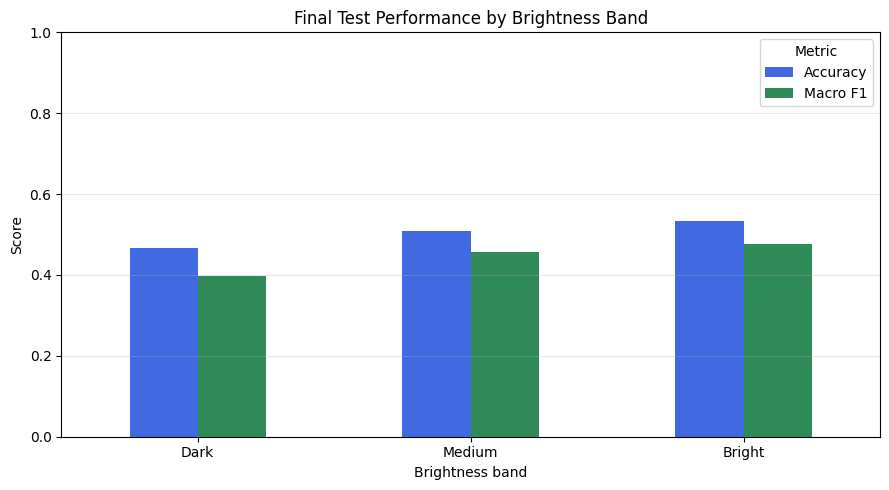

In [ ]:
from sklearn.metrics import f1_score

test_analysis_df = test_df.copy()

test_analysis_df["prediction"] = (
    final_test_predictions
)

test_analysis_df["brightness_band"] = pd.cut(
    test_analysis_df["brightness"],
    bins=[
        -np.inf,
        brightness_q1,
        brightness_q3,
        np.inf
    ],
    labels=[
        "Dark",
        "Medium",
        "Bright"
    ],
    include_lowest=True
)

brightness_performance_records = []

for brightness_band in [
    "Dark",
    "Medium",
    "Bright"
]:
    band_data = test_analysis_df.loc[
        test_analysis_df[
            "brightness_band"
        ] == brightness_band
    ]

    band_accuracy = accuracy_score(
        band_data["label"],
        band_data["prediction"]
    )

    band_macro_f1 = f1_score(
        band_data["label"],
        band_data["prediction"],
        labels=label_indices,
        average="macro",
        zero_division=0
    )

    brightness_performance_records.append({
        "Brightness band": brightness_band,
        "Images": len(band_data),
        "Accuracy": band_accuracy,
        "Macro F1": band_macro_f1,
    })

brightness_performance_df = pd.DataFrame(
    brightness_performance_records
).set_index("Brightness band")

display(
    brightness_performance_df.round(4)
)

brightness_performance_df[
    ["Accuracy", "Macro F1"]
].plot(
    kind="bar",
    figsize=(9, 5),
    color=["royalblue", "seagreen"]
)

plt.title(
    "Final Test Performance by Brightness Band"
)
plt.xlabel("Brightness band")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "final_test_brightness_robustness.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

brightness_performance_df.to_csv(
    RESULTS_DIR
    / "final_test_brightness_performance.csv"
)

#### What does this robustness analysis show?

The comparison identifies whether prediction quality changes across
dataset-relative lighting conditions. A lower score for one band would
indicate a robustness limitation and motivate targeted augmentation or
image enhancement. These bands describe this dataset and are not
universal definitions of poor or good lighting.

### Model Interpretability with Grad-CAM

Grad-CAM uses gradients flowing into the final convolutional feature
map to highlight image regions that influenced a prediction. One correct
and one incorrect test example are visualized. Warm colours indicate
stronger influence. The heatmap provides qualitative evidence and is
not a causal explanation of human emotion.

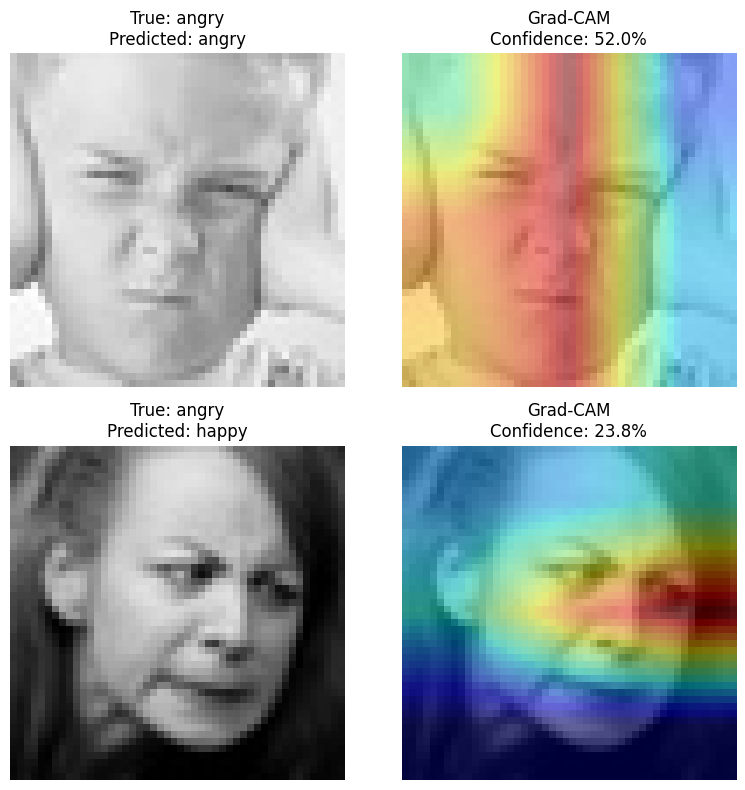

In [ ]:
# Locate the nested MobileNetV2 base robustly.
final_base_model = next(
    layer
    for layer in final_model.layers
    if isinstance(layer, keras.Model)
    and "mobilenetv2" in layer.name.lower()
)

final_augmentation = final_model.get_layer(
    "transfer_augmentation"
)
final_preprocessing = final_model.get_layer(
    "mobilenet_preprocessing"
)
final_pooling = final_model.get_layer(
    "global_average_pooling"
)
final_dropout = final_model.get_layer(
    "transfer_dropout"
)
final_classifier = final_model.get_layer(
    "emotion_probabilities"
)

def prepare_gradcam_image(image_path):
    image_bytes = tf.io.read_file(
        str(image_path)
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        TRANSFER_IMAGE_SIZE
    )

    image = (
        tf.cast(image, tf.float32)
        / 255.0
    )

    return tf.expand_dims(
        image,
        axis=0
    )


def create_gradcam_heatmap(image_path):
    image_batch = prepare_gradcam_image(
        image_path
    )

    with tf.GradientTape() as tape:
        augmented = final_augmentation(
            image_batch,
            training=False
        )

        preprocessed = final_preprocessing(
            augmented
        )

        feature_maps = final_base_model(
            preprocessed,
            training=False
        )

        tape.watch(feature_maps)

        pooled_features = final_pooling(
            feature_maps
        )

        pooled_features = final_dropout(
            pooled_features,
            training=False
        )

        probabilities = final_classifier(
            pooled_features
        )

        predicted_index = int(
            tf.argmax(
                probabilities[0]
            )
        )

        predicted_score = probabilities[
            0,
            predicted_index
        ]

    gradients = tape.gradient(
        predicted_score,
        feature_maps
    )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    heatmap = tf.reduce_sum(
        feature_maps
        * channel_weights[:, None, None, :],
        axis=-1
    )[0]

    heatmap = tf.maximum(
        heatmap,
        0
    )

    maximum_value = tf.reduce_max(
        heatmap
    )

    if float(maximum_value) > 0:
        heatmap = heatmap / maximum_value

    return (
        heatmap.numpy(),
        predicted_index,
        float(
            probabilities[
                0,
                predicted_index
            ]
        )
    )


correct_indices = np.flatnonzero(
    final_test_predictions
    == final_test_true_labels
)

incorrect_indices = np.flatnonzero(
    final_test_predictions
    != final_test_true_labels
)

assert len(correct_indices) > 0
assert len(incorrect_indices) > 0

selected_indices = [
    int(correct_indices[0]),
    int(incorrect_indices[0])
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 8)
)

for row_position, sample_index in enumerate(
    selected_indices
):
    sample = test_df.iloc[
        sample_index
    ]

    heatmap, predicted_index, confidence = (
        create_gradcam_heatmap(
            sample["image_path"]
        )
    )

    with Image.open(
        sample["image_path"]
    ) as image:
        original_image = image.convert("L")
        original_array = np.asarray(
            original_image
        )

    resized_heatmap = tf.image.resize(
        heatmap[..., None],
        original_array.shape
    ).numpy().squeeze()

    predicted_label = index_to_label[
        predicted_index
    ]

    axes[row_position, 0].imshow(
        original_array,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[row_position, 0].set_title(
        f"True: {sample['emotion']}\n"
        f"Predicted: {predicted_label}"
    )
    axes[row_position, 0].axis("off")

    axes[row_position, 1].imshow(
        original_array,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    axes[row_position, 1].imshow(
        resized_heatmap,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )
    axes[row_position, 1].set_title(
        f"Grad-CAM\nConfidence: "
        f"{confidence:.1%}"
    )
    axes[row_position, 1].axis("off")

axes[0, 0].set_ylabel(
    "Correct prediction",
    fontsize=11
)
axes[1, 0].set_ylabel(
    "Incorrect prediction",
    fontsize=11
)

plt.tight_layout()

fig.savefig(
    RESULTS_DIR
    / "final_model_gradcam_examples.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

#### What did the explainability analysis show?

Grad-CAM indicates whether the model concentrated on facial regions such
as the eyes, eyebrows, mouth, or cheeks. Attention outside the face may
suggest reliance on background or image artefacts. Because Grad-CAM is
a coarse qualitative explanation, it should be interpreted together
with class metrics and error analysis.

### Saved-Model Reload and Unseen-Image Sanity Check

The selected model is loaded again from Google Drive and used to predict
one held-out image. This verifies that the saved artifact can perform
inference independently of the trained in-memory model. Model metadata
is also saved so deployment code can reproduce the correct input size,
label order, and normalization.

In [ ]:
import json

deployment_model = keras.models.load_model(
    str(FINAL_MODEL_PATH)
)

def prepare_prediction_image(image_path):
    image_bytes = tf.io.read_file(
        str(image_path)
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        TRANSFER_IMAGE_SIZE
    )

    image = (
        tf.cast(image, tf.float32)
        / 255.0
    )

    return tf.expand_dims(
        image,
        axis=0
    )


def predict_emotion(image_path):
    image_batch = prepare_prediction_image(
        image_path
    )

    probabilities = deployment_model.predict(
        image_batch,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    return {
        "predicted_emotion":
            index_to_label[predicted_index],
        "confidence":
            float(probabilities[predicted_index]),
        "probabilities": {
            index_to_label[index]:
                float(probability)
            for index, probability
            in enumerate(probabilities)
        }
    }


sanity_sample = test_df.sample(
    n=1,
    random_state=123
).iloc[0]

sanity_result = predict_emotion(
    sanity_sample["image_path"]
)

print(
    "True emotion:",
    sanity_sample["emotion"]
)
print(
    "Predicted emotion:",
    sanity_result["predicted_emotion"]
)
print(
    "Confidence:",
    f"{sanity_result['confidence']:.2%}"
)
print(
    "Probability sum:",
    f"{sum(sanity_result['probabilities'].values()):.6f}"
)

top_three_predictions = sorted(
    sanity_result["probabilities"].items(),
    key=lambda item: item[1],
    reverse=True
)[:3]

print("\nTop three predictions:")

for emotion, probability in top_three_predictions:
    print(
        f"{emotion}: {probability:.2%}"
    )

model_metadata = {
    "project":
        "DeepFER: Facial Emotion Recognition Using Deep Learning",
    "selected_model":
        FINAL_MODEL_NAME,
    "model_file":
        Path(FINAL_MODEL_PATH).name,
    "input_height":
        TRANSFER_IMAGE_SIZE[0],
    "input_width":
        TRANSFER_IMAGE_SIZE[1],
    "channels": 3,
    "input_range": [0.0, 1.0],
    "label_to_index":
        label_to_index,
    "index_to_label": {
        str(index): label
        for index, label
        in index_to_label.items()
    },
    "test_accuracy":
        float(final_test_accuracy),
    "test_macro_f1":
        float(
            final_test_metrics_df.loc[
                "macro avg",
                "f1-score"
            ]
        ),
}

METADATA_PATH = (
    MODELS_DIR
    / "model_metadata.json"
)

with METADATA_PATH.open(
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=2
    )

print(
    "\nModel metadata saved to:",
    METADATA_PATH
)

assert abs(
    sum(
        sanity_result[
            "probabilities"
        ].values()
    ) - 1.0
) < 1e-5

True emotion: angry
Predicted emotion: fear
Confidence: 48.23%
Probability sum: 1.000000

Top three predictions:
fear: 48.23%
surprise: 26.41%
happy: 8.49%

Model metadata saved to: /content/drive/MyDrive/DeepFER: Facial Emotion Recognition Using Deep Learning/models/model_metadata.json


### Robustness and Interpretability Findings

Performance improved as image brightness increased. Dark images achieved
46.78% accuracy and 39.75% macro F1, compared with 53.31% accuracy and
47.69% macro F1 for bright images. This confirms that poor lighting is
a material limitation of the current system.

Grad-CAM showed that the model used central facial regions in the
displayed correct prediction. The incorrect example had low confidence,
showing that ambiguous expressions remain difficult. Grad-CAM is a
coarse qualitative visualization and does not prove that every
prediction is based only on meaningful facial features.

The saved-model sanity check loaded successfully and produced
probabilities summing to 1.0. It misclassified an angry image as fear
with 48.23% confidence, with surprise as the second prediction at
26.41%. This is consistent with the earlier finding that angry and fear
have highly similar average visual patterns.

### Interactive Image-Upload Demo

This demo allows a user to upload a facial image and receive the
predicted expression, confidence, and probability distribution across
all seven classes. The model expects a visible, approximately
face-centred image. Its output describes the facial-expression category
and should not be treated as proof of a person's internal emotional or
mental state.

Saving angry.jpg to angry.jpg


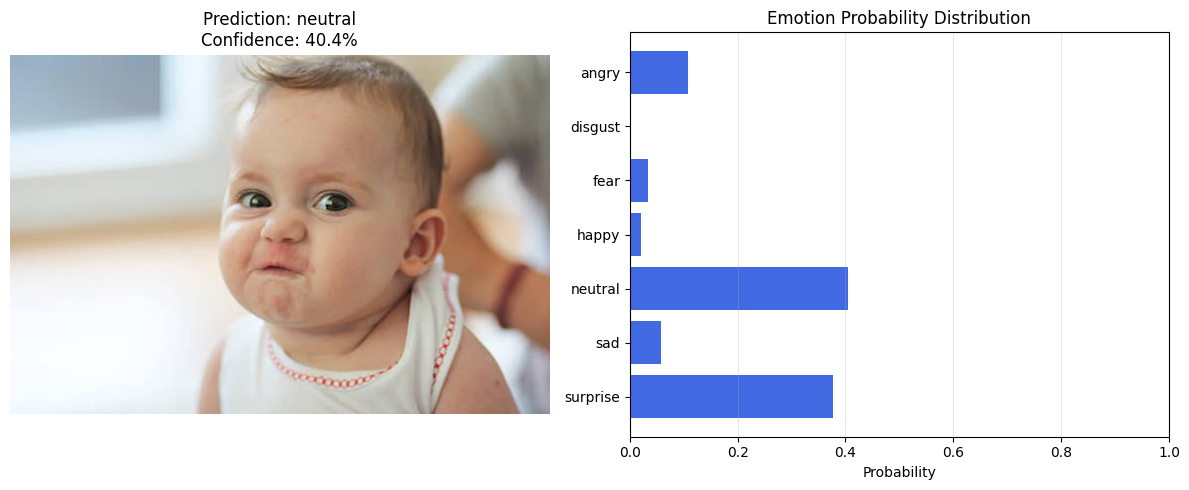

Predicted emotion: neutral
Confidence: 40.41%
Interpretation: Low-confidence prediction; treat the result as uncertain.


In [ ]:
from google.colab import files
from IPython.display import display

uploaded_files = files.upload()

assert uploaded_files, (
    "No image was uploaded."
)

uploaded_filename = next(
    iter(uploaded_files)
)

uploaded_path = (
    Path("/content")
    / uploaded_filename
)

upload_result = predict_emotion(
    uploaded_path
)

with Image.open(uploaded_path) as image:
    display_image = image.convert("RGB")

probability_series = pd.Series(
    upload_result["probabilities"]
).reindex(EMOTION_CLASSES)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(display_image)
axes[0].set_title(
    f"Prediction: "
    f"{upload_result['predicted_emotion']}\n"
    f"Confidence: "
    f"{upload_result['confidence']:.1%}"
)
axes[0].axis("off")

axes[1].barh(
    probability_series.index,
    probability_series.values,
    color="royalblue"
)
axes[1].set_title(
    "Emotion Probability Distribution"
)
axes[1].set_xlabel("Probability")
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()
axes[1].grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print(
    "Predicted emotion:",
    upload_result["predicted_emotion"]
)
print(
    "Confidence:",
    f"{upload_result['confidence']:.2%}"
)

if upload_result["confidence"] < 0.50:
    print(
        "Interpretation: Low-confidence prediction; "
        "treat the result as uncertain."
    )

### Webcam Face-Capture Demonstration

A webcam frame is captured in the browser. A Haar cascade detects the most prominent face near the centre of the frame, which is cropped before inference., which is cropped before inference. Face cropping
better matches the training data than resizing an entire camera frame.
This is a single-frame demonstration; continuous video requires further
latency optimization and temporal smoothing.

In [5]:
from pathlib import Path
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

PROJECT_DIR = Path("/content/drive/MyDrive") / "DeepFER: Facial Emotion Recognition Using Deep Learning"
MODELS_DIR = PROJECT_DIR / "models"
METADATA_PATH = MODELS_DIR / "model_metadata.json"

assert METADATA_PATH.is_file(), f"Model metadata not found: {METADATA_PATH}"
with METADATA_PATH.open("r", encoding="utf-8") as metadata_file:
    model_metadata = json.load(metadata_file)

FINAL_MODEL_PATH = MODELS_DIR / model_metadata["model_file"]
TRANSFER_IMAGE_SIZE = (int(model_metadata["input_height"]), int(model_metadata["input_width"]))
index_to_label = {int(index): label for index, label in model_metadata["index_to_label"].items()}

assert FINAL_MODEL_PATH.is_file(), f"Final model not found: {FINAL_MODEL_PATH}"
deployment_model = keras.models.load_model(str(FINAL_MODEL_PATH))


def prepare_prediction_image(image_path):
    image_bytes = tf.io.read_file(str(image_path))
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, TRANSFER_IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return tf.expand_dims(image, axis=0)


def predict_emotion(image_path):
    image_batch = prepare_prediction_image(image_path)
    probabilities = deployment_model.predict(image_batch, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    return {
        "predicted_emotion": index_to_label[predicted_index],
        "confidence": float(probabilities[predicted_index]),
        "probabilities": {
            index_to_label[index]: float(probability)
            for index, probability in enumerate(probabilities)
        },
    }

print("Webcam setup ready.")
print("Loaded model:", FINAL_MODEL_PATH.name)
print("Input size:", TRANSFER_IMAGE_SIZE)
print("Labels:", index_to_label)


Mounted at /content/drive
Webcam setup ready.
Loaded model: mobilenetv2_fine_tuned_continued_best.keras
Input size: (96, 96)
Labels: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


In [ ]:
%pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
%pip install --no-cache-dir --no-deps opencv-python-headless==4.13.0.92

In [ ]:
import cv2

print("OpenCV version:", cv2.__version__)
print("CascadeClassifier available:", hasattr(cv2, "CascadeClassifier"))
print("Haar cascade path available:", hasattr(cv2, "data"))

if hasattr(cv2, "CascadeClassifier") and hasattr(cv2, "data"):
    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    print("Detector loaded:", not detector.empty())

OpenCV version: 4.13.0
Face detector ready.


<IPython.core.display.Javascript object>

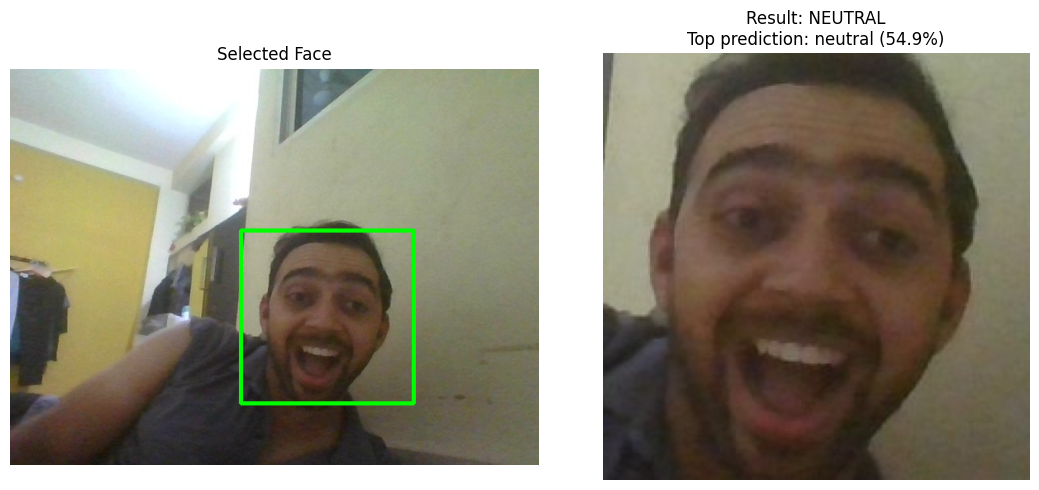

Face candidates detected: 1
Selected prediction: neutral
Confidence: 54.94%
Second prediction: fear (14.76%)
Confidence gap: 40.18%
Final result: neutral


In [11]:
from pathlib import Path
from base64 import b64decode

import cv2
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Javascript, display
from google.colab.output import eval_js


def capture_webcam_photo(
    filename="/content/webcam_frame.jpg",
    quality=0.90,
):
    camera_code = Javascript(
        """
        async function capturePhoto(quality) {
            const container = document.createElement("div");
            const video = document.createElement("video");
            const button = document.createElement("button");

            button.textContent = "Capture Photo";
            button.style.marginTop = "10px";
            button.style.padding = "8px 16px";

            video.style.display = "block";
            video.style.maxWidth = "640px";
            video.style.border = "2px solid #444";

            container.appendChild(video);
            container.appendChild(button);
            document.body.appendChild(container);

            const stream = await navigator.mediaDevices.getUserMedia({
                video: {
                    width: {ideal: 640},
                    height: {ideal: 480},
                    facingMode: "user"
                }
            });

            video.srcObject = stream;
            await video.play();

            await new Promise(resolve => {
                button.onclick = resolve;
            });

            const canvas = document.createElement("canvas");
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;

            canvas.getContext("2d").drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

            stream.getTracks().forEach(track => track.stop());
            container.remove();

            return canvas.toDataURL("image/jpeg", quality);
        }
        """
    )

    display(camera_code)
    photo_data = eval_js(f"capturePhoto({quality})")

    if not photo_data:
        raise RuntimeError(
            "The webcam image was not captured."
        )

    photo_bytes = b64decode(
        photo_data.split(",", 1)[1]
    )

    with open(filename, "wb") as photo_file:
        photo_file.write(photo_bytes)

    return Path(filename)


def predict_webcam_face(face_bgr):
    face_gray = cv2.cvtColor(
        face_bgr,
        cv2.COLOR_BGR2GRAY
    )

    face_gray = cv2.equalizeHist(face_gray)

    face_gray = cv2.resize(
        face_gray,
        (
            TRANSFER_IMAGE_SIZE[1],
            TRANSFER_IMAGE_SIZE[0],
        ),
        interpolation=cv2.INTER_AREA
    )

    face_rgb = cv2.cvtColor(
        face_gray,
        cv2.COLOR_GRAY2RGB
    )

    image_batch = (
        face_rgb.astype(np.float32) / 255.0
    )[np.newaxis, ...]

    probabilities = deployment_model.predict(
        image_batch,
        verbose=0
    )[0]

    top_indices = np.argsort(probabilities)[::-1]
    predicted_index = int(top_indices[0])
    second_index = int(top_indices[1])

    confidence = float(
        probabilities[predicted_index]
    )

    second_confidence = float(
        probabilities[second_index]
    )

    return {
        "predicted_emotion": index_to_label[
            predicted_index
        ],
        "confidence": confidence,
        "second_emotion": index_to_label[
            second_index
        ],
        "second_confidence": second_confidence,
        "confidence_gap": (
            confidence - second_confidence
        ),
    }


# Verify that the model setup cell has been executed.
assert "deployment_model" in globals(), (
    "Run the model setup cell before this cell."
)

assert "TRANSFER_IMAGE_SIZE" in globals(), (
    "TRANSFER_IMAGE_SIZE is missing. "
    "Run the model setup cell first."
)

assert "index_to_label" in globals(), (
    "The label mapping is missing. "
    "Run the model setup cell first."
)


# Verify that the required OpenCV features are available.
assert hasattr(cv2, "CascadeClassifier"), (
    "CascadeClassifier is unavailable. "
    "Install the supported OpenCV version and restart the runtime."
)

assert hasattr(cv2, "data"), (
    "The OpenCV Haar cascade path is unavailable."
)


# Load the frontal-face detector.
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades
    + "haarcascade_frontalface_default.xml"
)

assert not face_detector.empty(), (
    "The face detector could not be loaded."
)

print("OpenCV version:", cv2.__version__)
print("Face detector ready.")


# Capture and read a webcam image.
webcam_frame_path = capture_webcam_photo()

frame = cv2.imread(
    str(webcam_frame_path)
)

assert frame is not None, (
    "The captured webcam image could not be read."
)


# Prepare the image for face detection.
gray_frame = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2GRAY
)

gray_frame = cv2.equalizeHist(gray_frame)

minimum_face_size = max(
    80,
    int(min(frame.shape[:2]) * 0.20)
)


# Detect visible faces.
detected_faces = face_detector.detectMultiScale(
    gray_frame,
    scaleFactor=1.1,
    minNeighbors=8,
    minSize=(
        minimum_face_size,
        minimum_face_size,
    ),
)

if len(detected_faces) == 0:
    raise ValueError(
        "No face was detected. Move closer to the camera, "
        "use front lighting, and keep your face centred."
    )


# Select the most prominent face near the centre.
frame_height, frame_width = gray_frame.shape
frame_center_x = frame_width / 2
frame_center_y = frame_height / 2


def face_selection_score(face):
    x, y, width, height = face

    face_center_x = x + width / 2
    face_center_y = y + height / 2

    distance_from_center = (
        (face_center_x - frame_center_x) ** 2
        + (face_center_y - frame_center_y) ** 2
    )

    return distance_from_center / max(
        width * height,
        1
    )


face_x, face_y, face_width, face_height = min(
    detected_faces,
    key=face_selection_score
)


# Add a small margin around the selected face.
margin = int(
    0.12 * max(face_width, face_height)
)

x_start = max(0, face_x - margin)
y_start = max(0, face_y - margin)

x_end = min(
    frame_width,
    face_x + face_width + margin
)

y_end = min(
    frame_height,
    face_y + face_height + margin
)

face_crop = frame[
    y_start:y_end,
    x_start:x_end
]

assert face_crop.size > 0, (
    "The detected face crop is empty."
)


# Predict the facial expression.
webcam_result = predict_webcam_face(face_crop)

predicted_emotion = webcam_result[
    "predicted_emotion"
]

confidence = webcam_result[
    "confidence"
]

second_emotion = webcam_result[
    "second_emotion"
]

second_confidence = webcam_result[
    "second_confidence"
]

confidence_gap = webcam_result[
    "confidence_gap"
]


# Mark weak or ambiguous predictions as uncertain.
is_uncertain = (
    confidence < 0.40
    or confidence_gap < 0.10
)

display_prediction = (
    "UNCERTAIN"
    if is_uncertain
    else predicted_emotion.upper()
)


# Display the captured frame and selected face.
display_frame = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2RGB
)

display_face = cv2.cvtColor(
    face_crop,
    cv2.COLOR_BGR2RGB
)

cv2.rectangle(
    display_frame,
    (x_start, y_start),
    (x_end, y_end),
    (0, 255, 0),
    3
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)

axes[0].imshow(display_frame)
axes[0].set_title("Selected Face")
axes[0].axis("off")

axes[1].imshow(display_face)
axes[1].set_title(
    f"Result: {display_prediction}\n"
    f"Top prediction: {predicted_emotion} "
    f"({confidence:.1%})"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()


# Print detailed prediction results.
print(
    "Face candidates detected:",
    len(detected_faces)
)

print(
    "Selected prediction:",
    predicted_emotion
)

print(
    "Confidence:",
    f"{confidence:.2%}"
)

print(
    "Second prediction:",
    second_emotion,
    f"({second_confidence:.2%})"
)

print(
    "Confidence gap:",
    f"{confidence_gap:.2%}"
)

if is_uncertain:
    print(
        "Final result: UNCERTAIN — "
        "the prediction is not reliable enough."
    )
else:
    print(
        "Final result:",
        predicted_emotion
    )

### Webcam Demonstration Findings

The webcam demonstration successfully detects a visible face, crops the selected
facial region, applies grayscale preprocessing, and predicts one of the seven
facial-expression classes.

Repeated tests correctly identified happy and neutral expressions as the top
predictions. A confidence threshold and the difference between the two highest
class probabilities are used to mark ambiguous predictions as uncertain.

The webcam results are affected by lighting, camera quality, head position,
facial-expression intensity, and differences between real webcam images and the
training dataset. Therefore, the prediction represents a visual facial-expression
category and should not be interpreted as proof of a person's internal emotion.